# **FIFA Players Performance Analysis**
----------

## **EDA**

In [ ]:
# ! pip install category_encoders


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import (LabelEncoder, OneHotEncoder,StandardScaler, MinMaxScaler,RobustScaler, PowerTransformer)
from sklearn.model_selection import train_test_split , learning_curve
import category_encoders as ce
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from category_encoders import TargetEncoder
from sklearn.linear_model import LinearRegression ,LogisticRegression,Ridge,Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import  r2_score,mean_squared_error,mean_absolute_error, accuracy_score, precision_score, recall_score, f1_score,classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv(r"Fifa.csv")

In [ ]:
df.head(10)

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640
5,Abdel Rahman Boudi,Egypt,RB,27,65,67,Ittihad Alexandria,0.45,1610
6,Karim El Deeb,Egypt,CM,33,67,67,Ittihad Alexandria,0.30,1680
7,Mohamed Tony,Egypt,CDM,29,66,67,Ittihad Alexandria,0.38,1655
8,Nour Alaa El Din,Egypt,CAM,24,64,70,Ittihad Alexandria,0.60,1590
9,Fady Farid,Egypt,ST,28,67,68,Ittihad Alexandria,0.55,1670


In [ ]:
df.shape

(19667, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  object 
 1   Country            19667 non-null  object 
 2   Position           19667 non-null  object 
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  object 
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 1.4+ MB


In [ ]:
df.isnull().sum()

Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64

In [ ]:
df.describe()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


In [ ]:
df.describe(include="O")

,Name,Country,Position,Team
count,19667,19667,19667,19667
unique,19551,164,17,1009
top,Adama Fofana,England,CB,River Plate
freq,3,1549,2981,107


In [ ]:
df.duplicated().sum()

np.int64(0)

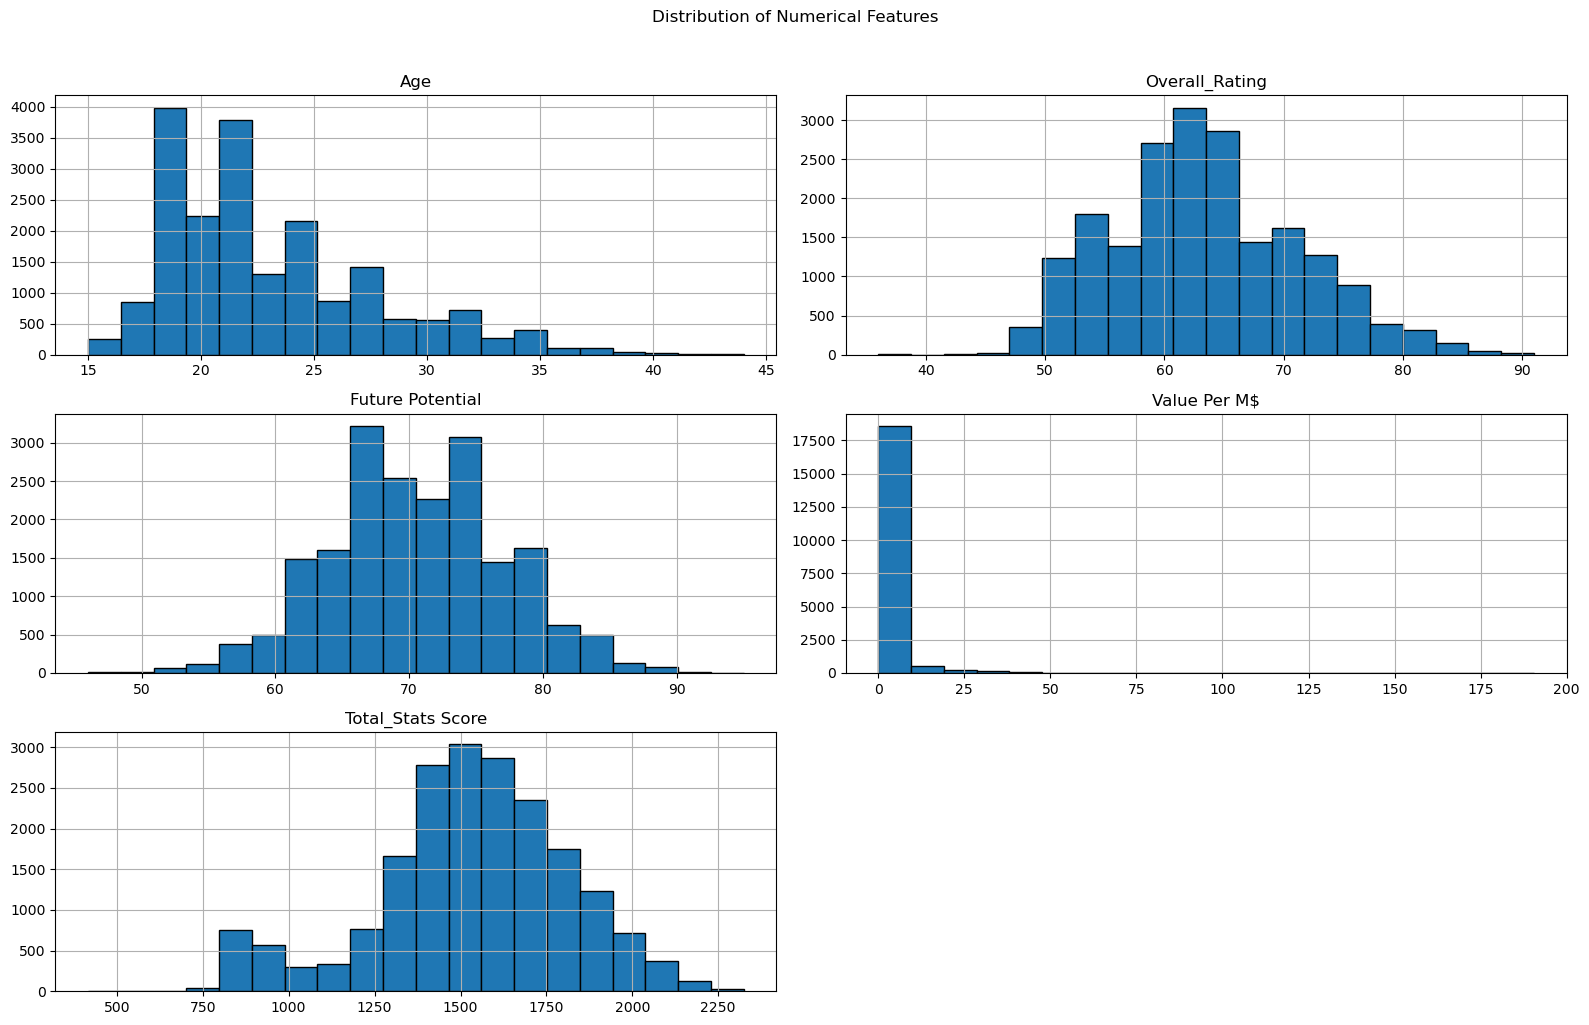

Skewness of Numerical Features:
Value Per M$         7.983215
Age                  0.968434
Overall_Rating       0.349970
Future Potential     0.038119
Total_Stats Score   -0.471524
dtype: float64


In [ ]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# Histograms
df[num_cols].hist(figsize=(16, 10), bins=20, edgecolor='black')
plt.suptitle('Distribution of Numerical Features', y=1.02)
plt.tight_layout()
plt.show()

# Skewness
skewness = df[num_cols].skew().sort_values(ascending=False)

print("Skewness of Numerical Features:")
print(skewness)

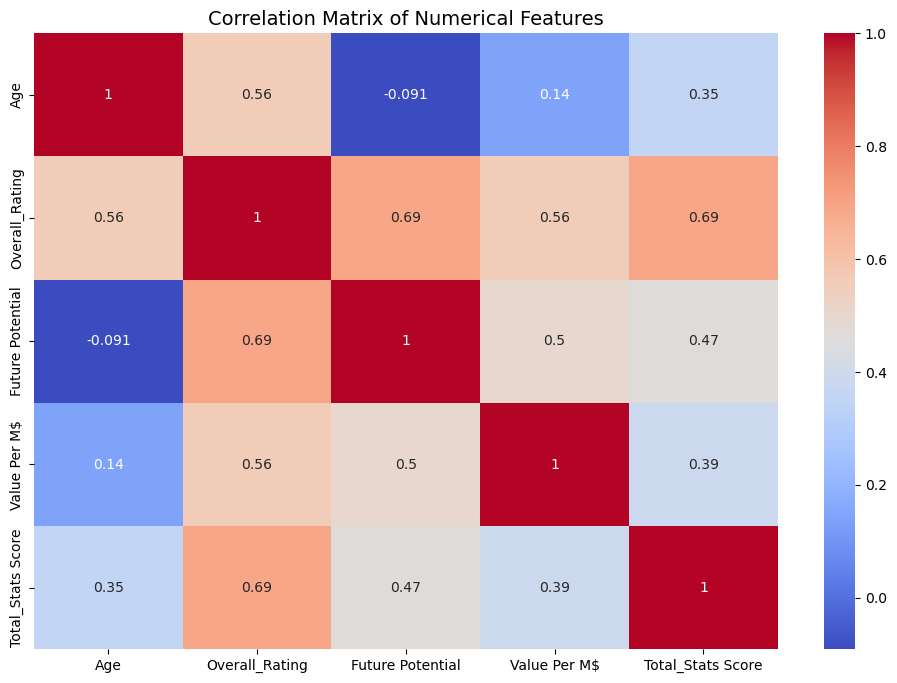

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features', fontsize=14)
plt.show()

In [ ]:
correlation_with_value = df.corr(numeric_only=True)['Value Per M$'].sort_values(ascending=False)
print(correlation_with_value)

Value Per M$         1.000000
Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64


The numerical features most related to `Value Per M$` are the features with the highest correlation values.  
From the correlation results, `Overall_Rating`, `Future Potential`, and `Total_Stats Score` appear to be the most related features to player market value.

In [ ]:
avg_rating = df.groupby('Position')['Overall_Rating'].mean().sort_values(ascending=False)
print(avg_rating)

Position
SW     75.000000
RF     75.000000
CF     66.042857
LW     64.345979
CDM    64.234168
LM     64.172009
RWB    64.063973
LWB    64.043333
RM     63.907731
RW     63.718529
CAM    63.679709
CB     63.544448
LB     63.276794
ST     63.087505
RB     62.863636
CM     62.511767
GK     60.987288
Name: Overall_Rating, dtype: float64


Position
SW     75.000000
RF     75.000000
CF     66.042857
LW     64.345979
CDM    64.234168
LM     64.172009
RWB    64.063973
LWB    64.043333
RM     63.907731
RW     63.718529
CAM    63.679709
CB     63.544448
LB     63.276794
ST     63.087505
RB     62.863636
CM     62.511767
GK     60.987288
Name: Overall_Rating, dtype: float64


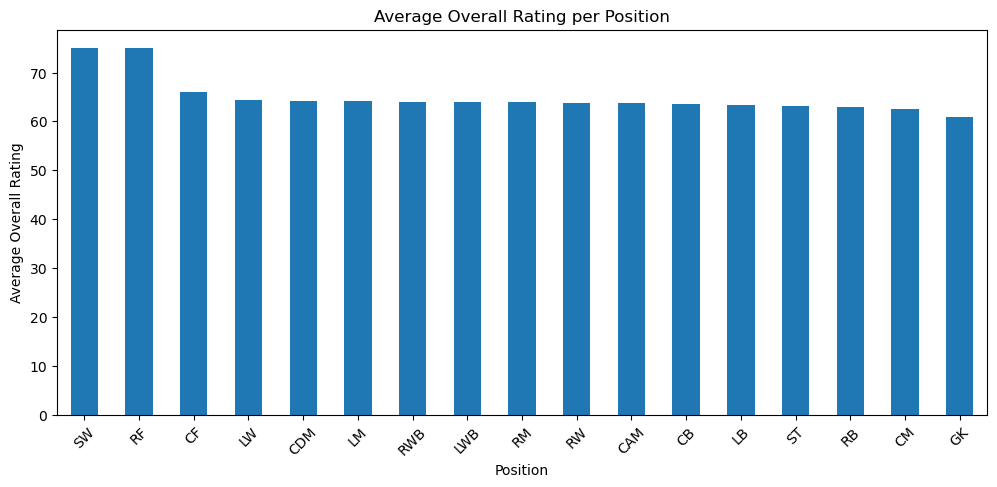

In [ ]:
avg_rating_position = df.groupby('Position')['Overall_Rating'].mean().sort_values(ascending=False)
print(avg_rating_position)

plt.figure(figsize=(12,5))
avg_rating_position.plot(kind='bar')
plt.title("Average Overall Rating per Position")
plt.xlabel("Position")
plt.ylabel("Average Overall Rating")
plt.xticks(rotation=45)
plt.show()

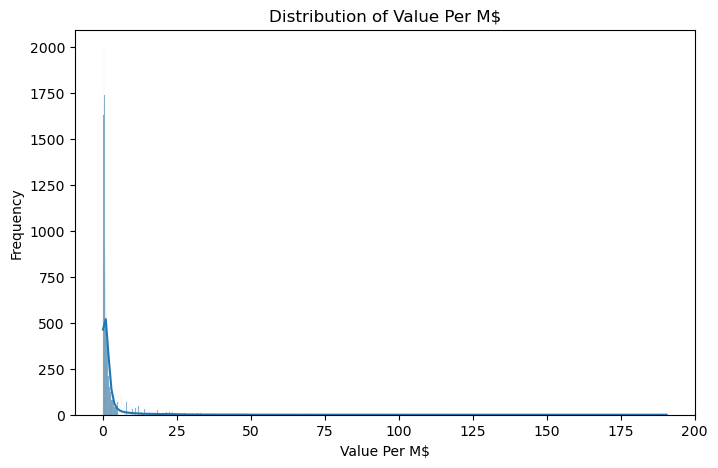

Skewness of Value Per M$: 7.983215201865151


In [ ]:
# Distribution of Value Per M$
plt.figure(figsize=(8,5))
sns.histplot(df['Value Per M$'], kde=True)
plt.title("Distribution of Value Per M$")
plt.xlabel("Value Per M$")
plt.ylabel("Frequency")
plt.show()

# Skewness
value_skewness = df['Value Per M$'].skew()
print("Skewness of Value Per M$:", value_skewness)

The distribution of `Value Per M$` is right-skewed because the skewness value is positive and high.  
This means most players have low market values, while a smaller number of players have very high values.

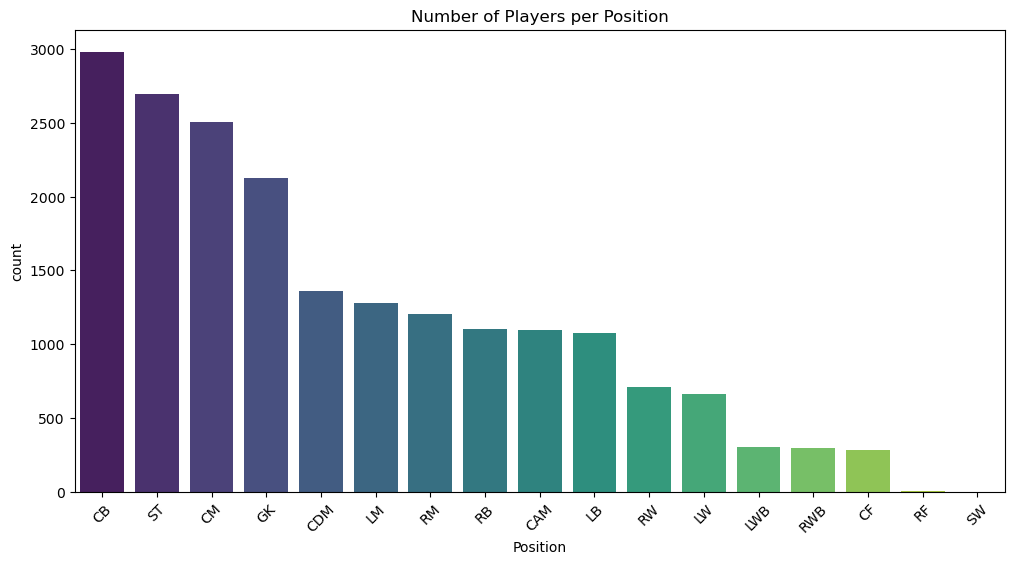

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Position', order=df['Position'].value_counts().index, palette='viridis')
plt.xticks(rotation=45)
plt.title('Number of Players per Position')
plt.show()

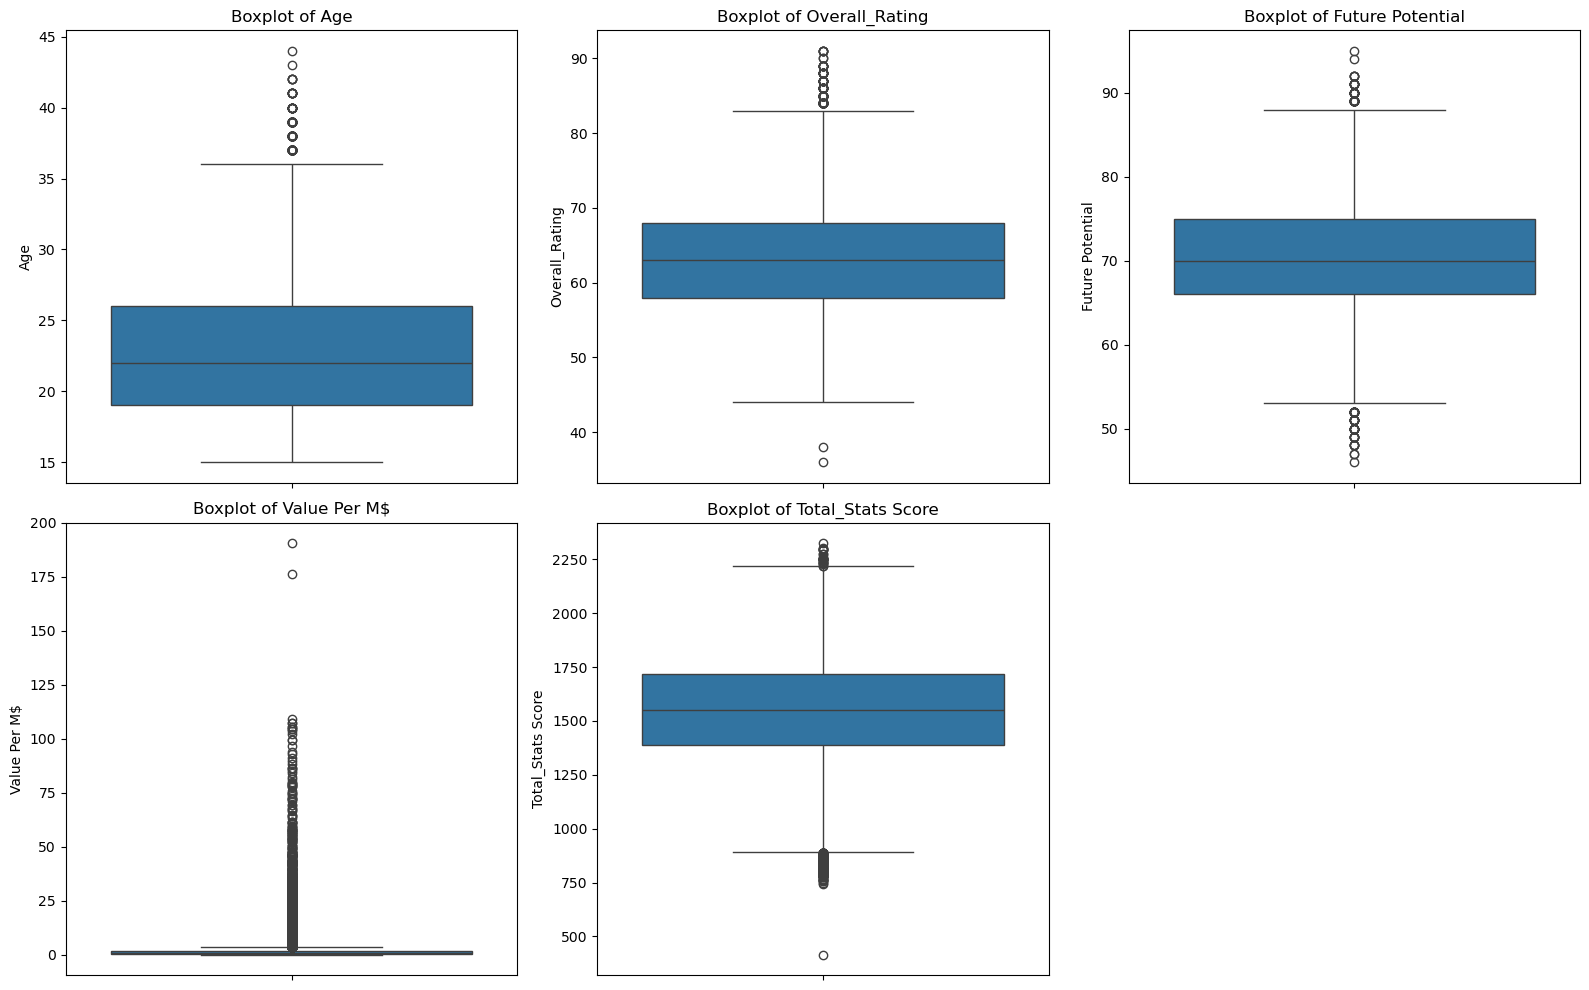

In [ ]:
plt.figure(figsize=(16, 10))

for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()

plt.show()

In [ ]:
Q1 = df['Value Per M$'].quantile(0.25)
Q3 = df['Value Per M$'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
outliers = df[df['Value Per M$'] > upper_bound]
print(f"Number of high-value outliers detected: {len(outliers)} from {len(df)}")
print("\nTop 5 Most Valuable Outliers:")
print(outliers[['Name', 'Team', 'Value Per M$', 'Overall_Rating']].sort_values(by='Value Per M$', ascending=False).head())

Number of high-value outliers detected: 2390 from 19667

Top 5 Most Valuable Outliers:
                                 Name                 Team  Value Per M$  \
103                     Kylian Mbappé  Paris Saint Germain         190.5   
67                     Erling Haaland      Manchester City         176.5   
110  Vinícius José de Oliveira Júnior          Real Madrid         109.0   
370                   Kevin De Bruyne      Manchester City         107.5   
214      Rúben Santos Gato Alves Dias      Manchester City         107.5   

     Overall_Rating  
103              91  
67               90  
110              86  
370              91  
214              88  


In [ ]:
for col in df.select_dtypes(include='O').columns:
    print(f"{col} : {df[col].nunique()}")
    print()

Name : 19551

Country : 164

Position : 17

Team : 1009



## *Regression Data Split*

In [ ]:
X_Reg = df.drop(['Name', 'Value Per M$'], axis=1)
y_Reg = df['Value Per M$']
X_Reg

,Country,Position,Age,Overall_Rating,Future Potential,Team,Total_Stats Score
0,Angola,LW,30,68,68,Ittihad Alexandria,1660
1,Egypt,GK,35,67,67,Ittihad Alexandria,1620
2,Egypt,GK,28,63,65,Ittihad Alexandria,1480
3,Egypt,CB,32,68,68,Ittihad Alexandria,1695
4,Egypt,CB,30,66,66,Ittihad Alexandria,1640
...,...,...,...,...,...,...,...
19662,Japan,CDM,21,63,71,Gamba Osaka,1717
19663,Japan,RW,22,64,71,Motherwell,1607
19664,Japan,CB,21,59,68,Shonan Bellmare,1347
19665,Turkey,LW,18,57,71,Shonan Bellmare,1481


In [ ]:
print(f'Features: {X_Reg.shape[1]}  |  Samples: {X_Reg.shape[0]}')

Features: 7  |  Samples: 19667


In [ ]:
x_train_Reg, x_test_Reg, y_train_Reg, y_test_Reg = train_test_split(
    X_Reg, y_Reg, test_size=0.2, random_state=1
)

print(f'Train: {x_train_Reg.shape}  |  Test: {x_test_Reg.shape}')

Train: (15733, 7)  |  Test: (3934, 7)


## *Classification Target Creation*

In [ ]:
q1 = df['Overall_Rating'].quantile(0.25)
q2 = df['Overall_Rating'].quantile(0.50)
q3 = df['Overall_Rating'].quantile(0.75)

print("Q1:", q1)
print("Q2:", q2)
print("Q3:", q3)

Q1: 58.0
Q2: 63.0
Q3: 68.0


In [ ]:
bins = [-float('inf'), q1, q2, q3, float('inf')]
labels = ['Low', 'Mid', 'High', 'Elite']

df['Performance_Tier'] = pd.cut(
    df['Overall_Rating'],
    bins=bins,
    labels=labels
)

"The thresholds were selected based on the quartiles of the 'Overall_Rating' distribution. Q1, Q2, and Q3 were used as cut-off points to divide players into four performance tiers: Low, Mid, High, and Elite."

Overall_Rating <= 58        → Low <br>
58 < Overall_Rating <= 63   → Mid <br>
63 < Overall_Rating <= 68   → High <br>
Overall_Rating > 68         → Elite <br>


In [ ]:
print(df[['Overall_Rating', 'Performance_Tier']].head())

   Overall_Rating Performance_Tier
0              68             High
1              67             High
2              63              Mid
3              68             High
4              66             High


In [ ]:
print(df['Performance_Tier'].value_counts().sort_index())

Performance_Tier
Low      5568
Mid      5102
High     4297
Elite    4700
Name: count, dtype: int64


## *Classification Data Split*

In [ ]:
X_cls = df.drop(['Name', 'Value Per M$', 'Overall_Rating', 'Performance_Tier'],axis=1)
y_cls = df['Performance_Tier']
X_cls

,Country,Position,Age,Future Potential,Team,Total_Stats Score
0,Angola,LW,30,68,Ittihad Alexandria,1660
1,Egypt,GK,35,67,Ittihad Alexandria,1620
2,Egypt,GK,28,65,Ittihad Alexandria,1480
3,Egypt,CB,32,68,Ittihad Alexandria,1695
4,Egypt,CB,30,66,Ittihad Alexandria,1640
...,...,...,...,...,...,...
19662,Japan,CDM,21,71,Gamba Osaka,1717
19663,Japan,RW,22,71,Motherwell,1607
19664,Japan,CB,21,68,Shonan Bellmare,1347
19665,Turkey,LW,18,71,Shonan Bellmare,1481


In [ ]:
print(f'Features: {X_cls.shape[1]}  |  Samples: {X_cls.shape[0]}')

Features: 6  |  Samples: 19667


In [ ]:
x_train_cls, x_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls,y_cls,test_size=0.2,random_state=1,stratify=y_cls)

In [ ]:
print(f'Train: {x_train_cls.shape}  |  Test: {x_test_cls.shape}')

Train: (15733, 6)  |  Test: (3934, 6)


Performance Tier Distribution:
Performance_Tier
Low      5568
Mid      5102
Elite    4700
High     4297
Name: count, dtype: int64


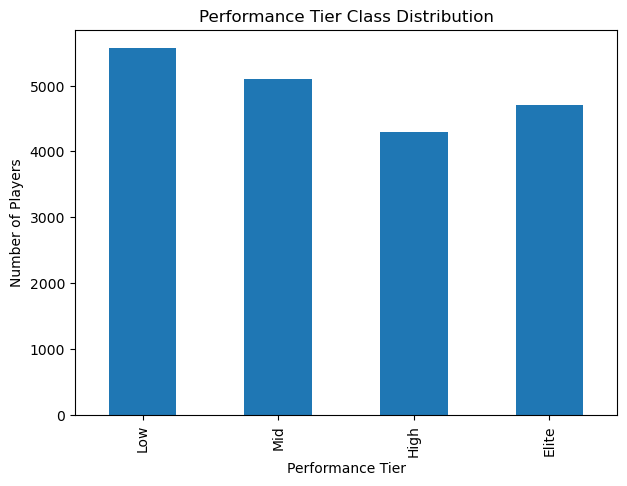

In [ ]:
print("Performance Tier Distribution:")
print(df['Performance_Tier'].value_counts())

plt.figure(figsize=(7,5))
df['Performance_Tier'].value_counts().sort_index().plot(kind='bar')
plt.title("Performance Tier Class Distribution")
plt.xlabel("Performance Tier")
plt.ylabel("Number of Players")
plt.show()

## **Preprocessing Pipelines**

"The preprocessing steps were applied after splitting the data to avoid data leakage. Separate preprocessing pipelines were created for regression and classification because the target variables and feature sets are different."

### *Handling outliers*

In [ ]:
def handle_outliers(df_in, columns):
    df_out = df_in.copy()

    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR

        df_out[col] = np.clip(df_out[col], lower_limit, upper_limit)

    return df_out

In [ ]:
num_cols_Reg_outliers = x_train_Reg.select_dtypes(include=['int64', 'float64']).columns.tolist()

x_train_Reg = handle_outliers(x_train_Reg, num_cols_Reg_outliers)
x_test_Reg = handle_outliers(x_test_Reg, num_cols_Reg_outliers)

print("Regression outliers handled using IQR clipping.")

Regression outliers handled using IQR clipping.

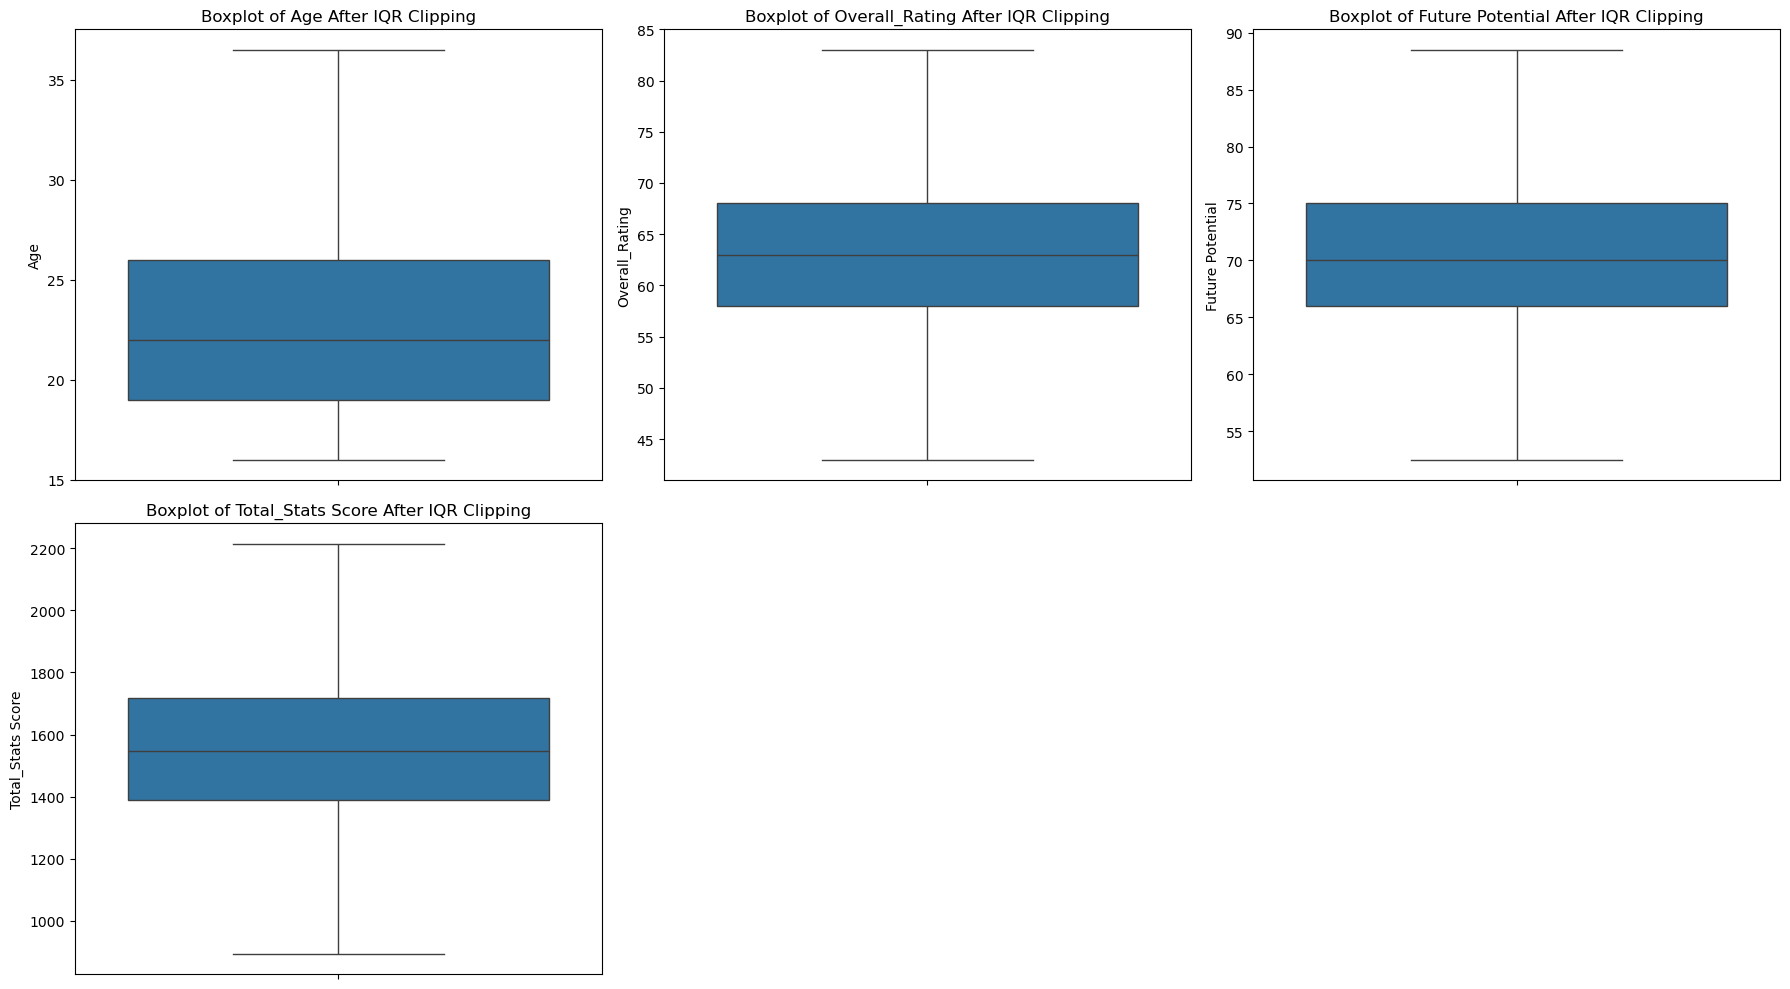

In [ ]:
# ================= Regression Boxplots After Outlier Handling =================

import matplotlib.pyplot as plt
import seaborn as sns

cols_to_plot_Reg = num_cols_Reg_outliers

n_cols = 3
n_rows = (len(cols_to_plot_Reg) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(cols_to_plot_Reg, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=x_train_Reg[col])
    plt.title(f'Boxplot of {col} After IQR Clipping')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

In [ ]:
num_cols_cls_outliers = x_train_cls.select_dtypes(include=['int64', 'float64']).columns.tolist()

x_train_cls = handle_outliers(x_train_cls, num_cols_cls_outliers)
x_test_cls = handle_outliers(x_test_cls, num_cols_cls_outliers)

print("Classification outliers handled using IQR clipping.")

Classification outliers handled using IQR clipping.


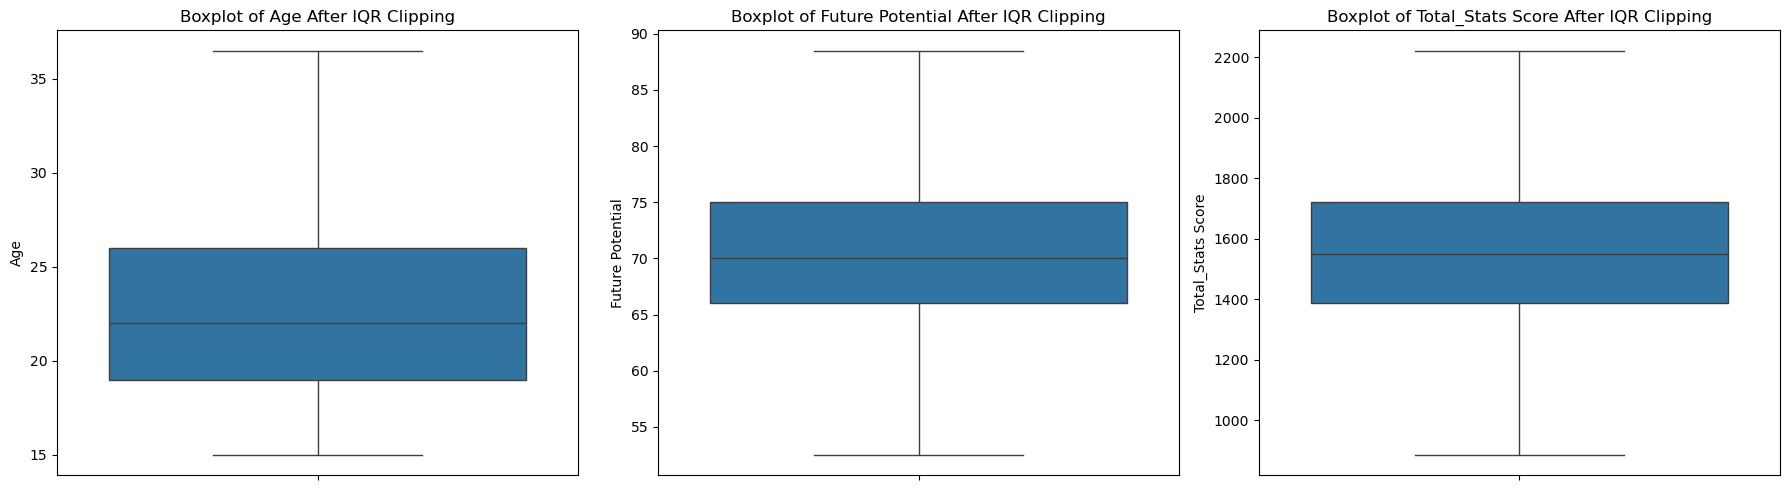

In [ ]:
# ================= Classification Boxplots After Outlier Handling =================

import matplotlib.pyplot as plt
import seaborn as sns

cols_to_plot_cls = num_cols_cls_outliers

n_cols = 3
n_rows = (len(cols_to_plot_cls) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(cols_to_plot_cls, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=x_train_cls[col])
    plt.title(f'Boxplot of {col} After IQR Clipping')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

### *Encoding & Scaling*

In [ ]:
# Regression Preprocessing Pipeline

one_hot_cols_Reg = ['Position']
target_cols_Reg = ['Team', 'Country']
num_cols_Reg = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']

num_transformer_Reg = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_ohe_transformer_Reg = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

cat_te_transformer_Reg = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('te', TargetEncoder(smoothing=10.0))
])

preprocessor_Reg = ColumnTransformer(
    transformers=[
        ('num', num_transformer_Reg, num_cols_Reg),
        ('cat_ohe', cat_ohe_transformer_Reg, one_hot_cols_Reg),
        ('cat_te', cat_te_transformer_Reg, target_cols_Reg)
    ]
)

pipeline_Reg = Pipeline(steps=[
    ('preprocessor', preprocessor_Reg)
])

In [ ]:
x_train_final_Reg = pd.DataFrame(
    pipeline_Reg.fit_transform(x_train_Reg, y_train_Reg),
    columns=pipeline_Reg.get_feature_names_out()
)

x_test_final_Reg = pd.DataFrame(
    pipeline_Reg.transform(x_test_Reg),
    columns=pipeline_Reg.get_feature_names_out()
)

print(f"Final regression features count with Pipeline: {x_train_final_Reg.shape[1]}")
x_train_final_Reg.head()

Final regression features count with Pipeline: 23


,num__Age,num__Overall_Rating,num__Future Potential,num__Total_Stats Score,cat_ohe__Position_CAM,cat_ohe__Position_CB,cat_ohe__Position_CDM,cat_ohe__Position_CF,cat_ohe__Position_CM,cat_ohe__Position_GK,...,cat_ohe__Position_LWB,cat_ohe__Position_RB,cat_ohe__Position_RF,cat_ohe__Position_RM,cat_ohe__Position_RW,cat_ohe__Position_RWB,cat_ohe__Position_ST,cat_ohe__Position_SW,cat_te__0,cat_te__1
0,0.867882,0.872125,0.206334,0.017485,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.019698,3.968113
1,-0.210774,-0.414602,-0.258268,-0.079405,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.635712,4.523451
2,-0.426506,-0.157257,-0.103401,-0.434669,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.493331,1.004467
3,0.004957,-0.671947,-0.877736,-2.304289,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.953834,4.024425
4,-0.426506,1.000797,2.219606,0.573706,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.312362,7.017010


In [ ]:
# Classification Preprocessing Pipeline
one_hot_cols_cls = ['Position']
target_cols_cls = ['Team', 'Country']
num_cols_cls = ['Age', 'Future Potential', 'Total_Stats Score']

num_transformer_cls = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_ohe_transformer_cls = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

cat_te_transformer_cls = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('te', TargetEncoder(smoothing=10.0))
])

preprocessor_cls = ColumnTransformer(
    transformers=[
        ('num', num_transformer_cls, num_cols_cls),
        ('cat_ohe', cat_ohe_transformer_cls, one_hot_cols_cls),
        ('cat_te', cat_te_transformer_cls, target_cols_cls)
    ]

)

pipeline_cls = Pipeline(steps=[
    ('preprocessor', preprocessor_cls)
])

In [ ]:
x_train_final_cls = pd.DataFrame(
    pipeline_cls.fit_transform(x_train_cls, y_train_cls),
    columns=pipeline_cls.get_feature_names_out()
)

x_test_final_cls = pd.DataFrame(
    pipeline_cls.transform(x_test_cls),
    columns=pipeline_cls.get_feature_names_out()
)

print(f"Final classification features count with Pipeline: {x_train_final_cls.shape[1]}")
x_train_final_cls.head()

Final classification features count with Pipeline: 21


,num__Age,num__Future Potential,num__Total_Stats Score,cat_ohe__Position_CAM,cat_ohe__Position_CB,cat_ohe__Position_CDM,cat_ohe__Position_CF,cat_ohe__Position_CM,cat_ohe__Position_GK,cat_ohe__Position_LB,...,cat_ohe__Position_LW,cat_ohe__Position_LWB,cat_ohe__Position_RB,cat_ohe__Position_RF,cat_ohe__Position_RM,cat_ohe__Position_RW,cat_ohe__Position_RWB,cat_ohe__Position_ST,cat_te__0,cat_te__1
0,-0.855155,2.377624,0.545822,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.373288,1.505929
1,-0.639806,-1.347199,-0.683647,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.679118,1.447020
2,0.436940,0.204810,0.524378,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.470515,1.552147
3,-0.209108,-0.105592,-2.209762,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.928494,1.345355
4,-0.855155,-0.881596,-1.126828,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.453335,1.628981


**StandardScaler** was used for the numerical features because the models used in this project, are sensitive to the scale of the input features. The numerical columns have different ranges, so scaling them to have approximately mean = 0 and standard deviation = 1 helps the model treat the features more fairly and makes coefficient-based learning more stable.

**One-Hot Encoding** was used for categorical columns with a small number of unique values, such as `Position`. This technique is suitable here because it represents each category clearly without creating too many extra columns.

**Target Encoding** was used for high-cardinality categorical columns such as `Team` and `Country`. These columns have many unique values so Target Encoding keeps the number of features small by replacing each category with a target-based numerical value, making it more efficient for the model.

In [ ]:
mean_val_reg = x_train_final_Reg.iloc[:, 0].mean()
print(f"Mean of first regression feature: {round(mean_val_reg, 2)}")

std_val_reg = x_train_final_Reg.iloc[:, 0].std()
print(f"Std of first regression feature: {round(std_val_reg, 2)}")

Mean of first regression feature: 0.0
Std of first regression feature: 1.0


In [ ]:
mean_val = x_train_final_cls.iloc[:, 0].mean()
print(f"Mean of first classification feature: {round(mean_val, 2)}")

std_val = x_train_final_cls.iloc[:, 0].std()
print(f"Std of first classification feature: {round(std_val, 2)}")

Mean of first classification feature: -0.0
Std of first classification feature: 1.0


In [ ]:
x_train_final_Reg.head()

,num__Age,num__Overall_Rating,num__Future Potential,num__Total_Stats Score,cat_ohe__Position_CAM,cat_ohe__Position_CB,cat_ohe__Position_CDM,cat_ohe__Position_CF,cat_ohe__Position_CM,cat_ohe__Position_GK,...,cat_ohe__Position_LWB,cat_ohe__Position_RB,cat_ohe__Position_RF,cat_ohe__Position_RM,cat_ohe__Position_RW,cat_ohe__Position_RWB,cat_ohe__Position_ST,cat_ohe__Position_SW,cat_te__0,cat_te__1
0,0.867882,0.872125,0.206334,0.017485,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.019698,3.968113
1,-0.210774,-0.414602,-0.258268,-0.079405,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.635712,4.523451
2,-0.426506,-0.157257,-0.103401,-0.434669,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.493331,1.004467
3,0.004957,-0.671947,-0.877736,-2.304289,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.953834,4.024425
4,-0.426506,1.000797,2.219606,0.573706,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.312362,7.017010


In [ ]:
x_train_final_cls.head()

,num__Age,num__Future Potential,num__Total_Stats Score,cat_ohe__Position_CAM,cat_ohe__Position_CB,cat_ohe__Position_CDM,cat_ohe__Position_CF,cat_ohe__Position_CM,cat_ohe__Position_GK,cat_ohe__Position_LB,...,cat_ohe__Position_LW,cat_ohe__Position_LWB,cat_ohe__Position_RB,cat_ohe__Position_RF,cat_ohe__Position_RM,cat_ohe__Position_RW,cat_ohe__Position_RWB,cat_ohe__Position_ST,cat_te__0,cat_te__1
0,-0.855155,2.377624,0.545822,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.373288,1.505929
1,-0.639806,-1.347199,-0.683647,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.679118,1.447020
2,0.436940,0.204810,0.524378,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.470515,1.552147
3,-0.209108,-0.105592,-2.209762,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.928494,1.345355
4,-0.855155,-0.881596,-1.126828,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.453335,1.628981


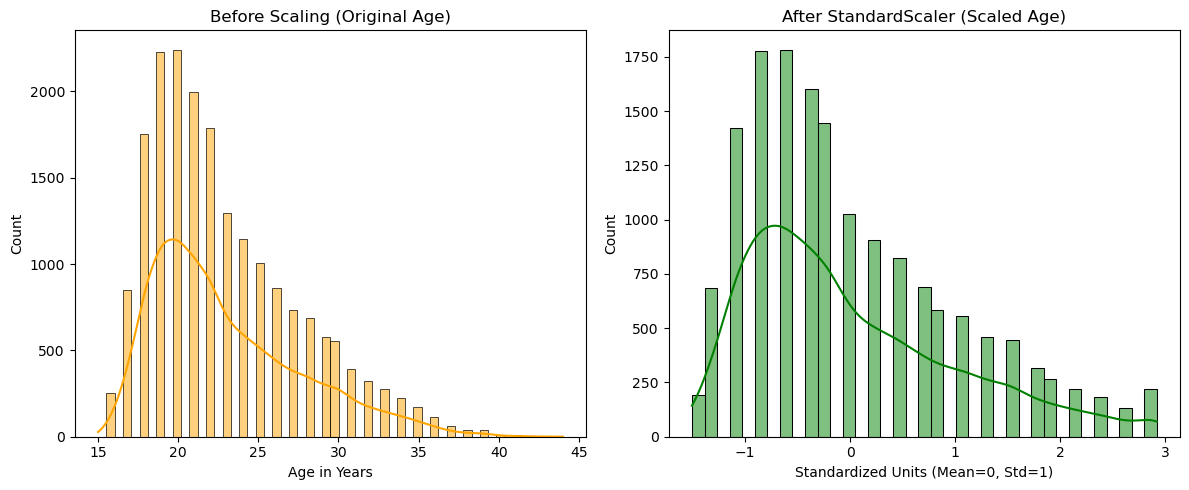

In [ ]:
plt.figure(figsize=(12, 5))

# Before
plt.subplot(1, 2, 1)
sns.histplot(df['Age'], kde=True, color='orange')
plt.title('Before Scaling (Original Age)')
plt.xlabel('Age in Years')

# After
plt.subplot(1, 2, 2)
sns.histplot(x_train_final_Reg.iloc[:, 0], kde=True, color='green')
plt.title('After StandardScaler (Scaled Age)')
plt.xlabel('Standardized Units (Mean=0, Std=1)')

plt.tight_layout()
plt.show()

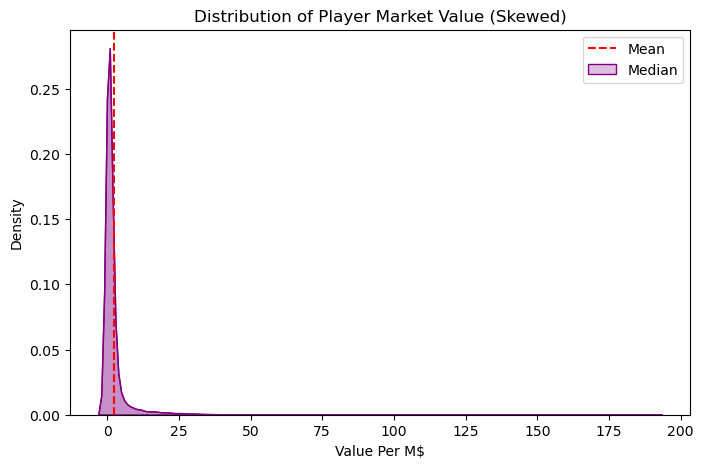

In [ ]:
plt.figure(figsize=(8, 5))
sns.kdeplot(df['Value Per M$'], fill=True, color="purple")
plt.title('Distribution of Player Market Value (Skewed)')
plt.axvline(df['Value Per M$'].mean(), color='red', linestyle='--', label='Mean')
sns.kdeplot(df['Value Per M$'], fill=True, color="purple", linestyle='-', label='Median')
plt.legend()
plt.show()

# **Model 1: Polynomial Regression**

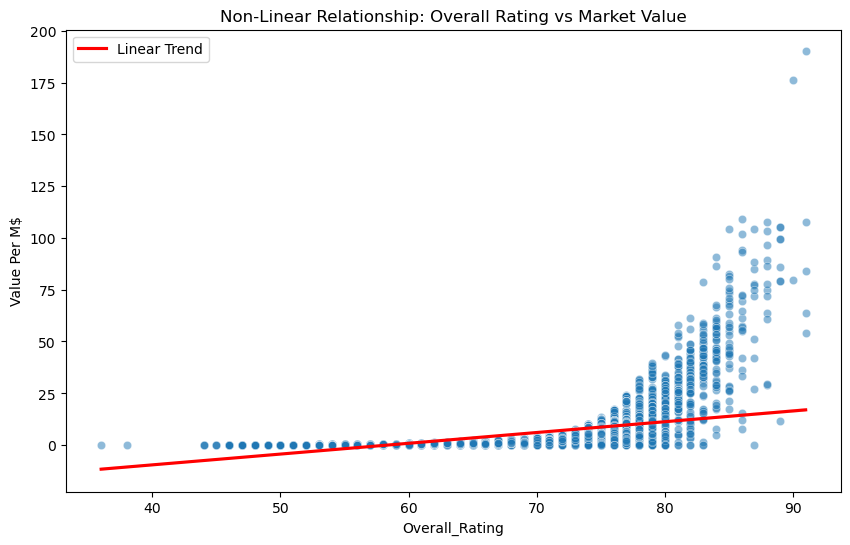

In [ ]:

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Overall_Rating', y='Value Per M$', alpha=0.5)
plt.title('Non-Linear Relationship: Overall Rating vs Market Value')
plt.xlabel('Overall Rating')
plt.ylabel('Value Per M$')

sns.regplot(data=df, x='Overall_Rating', y='Value Per M$', scatter=False, color='red', label='Linear Trend')
plt.legend()
plt.show()


"As shown in the scatter plot , the relationship between Overall_Rating and Value Per M$ is clearly non-linear. While the linear regression line (in red) fails to capture the rapid increase in market value for top-tier players, the data points follow a curved/exponential trend. This explains why the baseline Linear Regression achieved a low $R^2$ , and justifies the transition to Polynomial Regression to better fit this non-linear behavior.

In [ ]:
linear_model = LinearRegression()
linear_model.fit(x_train_final_Reg , y_train_Reg)
y_train_pred_reg =  linear_model.predict(x_train_final_Reg)
y_test_pred_reg = linear_model.predict(x_test_final_Reg)

In [ ]:
#Baseline Linear Regression Evaluation

train_mae = mean_absolute_error(y_train_Reg, y_train_pred_reg)
train_mse = mean_squared_error(y_train_Reg, y_train_pred_reg)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train_Reg, y_train_pred_reg)

test_mae = mean_absolute_error(y_test_Reg, y_test_pred_reg)
test_mse = mean_squared_error(y_test_Reg, y_test_pred_reg)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test_Reg, y_test_pred_reg)

results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R² Score"],
    "Training": [train_mae, train_mse, train_rmse, train_r2],
    "Testing": [test_mae, test_mse, test_rmse, test_r2]
})

results["Training"] = results["Training"].round(3)
results["Testing"] = results["Testing"].round(3)

print("Baseline Linear Regression Results")
print("------------------------------------")
print(results)



Baseline Linear Regression Results
------------------------------------
     Metric  Training  Testing
0       MAE     2.429    2.411
1       MSE    27.552   25.281
2      RMSE     5.249    5.028
3  R² Score     0.493    0.447


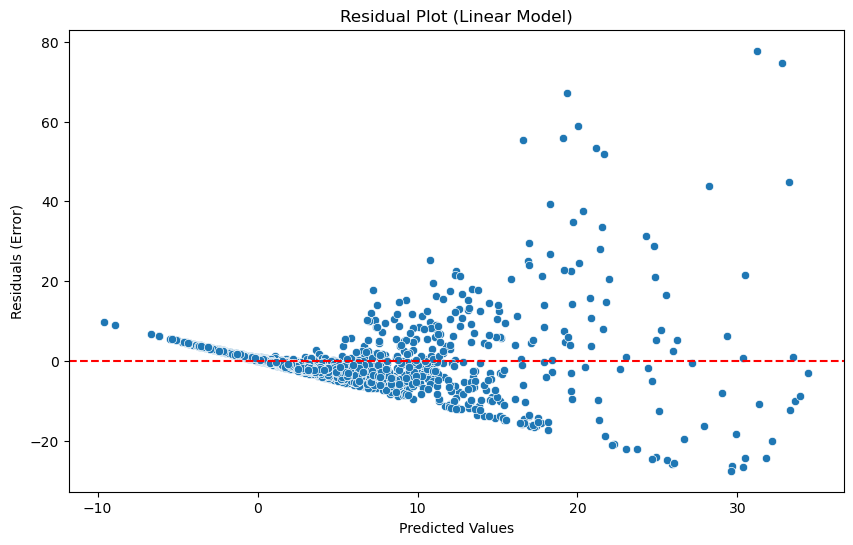

In [ ]:
residuals = y_test_Reg - y_test_pred_reg
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_pred_reg, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot (Linear Model)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Error)')
plt.show()

### Analysis of Residual Plot (Linear Model)

**Non-Random Pattern**: The residuals are not randomly distributed around the zero line; instead, they exhibit a clear "funnel" or "fan" shape.

**Heteroscedasticity**: The error variance increases as the predicted player value increases. This means the model is relatively accurate for low-value players but becomes highly unreliable for expensive, high-rated players.

**Evidence of Non-Linearity**: The presence of a systematic pattern in the residuals confirms that the relationship between player attributes and market value is non-linear.

**Justification for Complexity**: This visual evidence directly justifies the need for Polynomial Features to capture the curved trend that a simple linear line cannot represent

In [ ]:
def poly_plot(degrees , train_r2_scores , test_r2_scores):
    plt.figure(figsize=(8, 5))
    plt.plot(degrees, train_r2_scores, marker='o', label='Train R²', color='blue')
    plt.plot(degrees, test_r2_scores,  marker='o', label='Test R²',  color='red')
    plt.xlabel('Polynomial Degree')
    plt.ylabel('R² Score')
    plt.title('Polynomial Degree vs R² Score')
    plt.legend()
    plt.grid(True)
    plt.show()

Degree 1 → Train R²: 0.3313 | Test R²: 0.3319
Degree 2 → Train R²: 0.6571 | Test R²: 0.6654
Degree 3 → Train R²: 0.8422 | Test R²: 0.8578
Degree 4 → Train R²: 0.9094 | Test R²: 0.9242


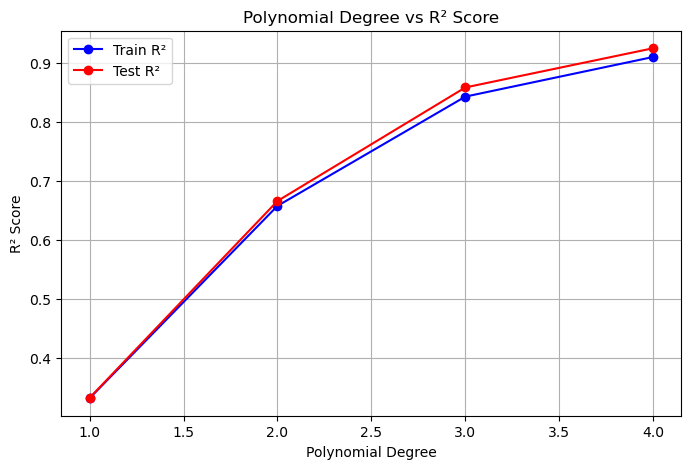

In [ ]:
numerical_cols = ['num__Age', 'num__Overall_Rating', 'num__Future Potential', 'num__Total_Stats Score']

X_train_num = x_train_final_Reg[numerical_cols]
X_test_num  = x_test_final_Reg[numerical_cols]

degrees = [1, 2, 3, 4]
train_r2_scores = []
test_r2_scores  = []

for degree in degrees:

    poly = PolynomialFeatures(degree=degree, include_bias=False)

    X_train_poly = poly.fit_transform(X_train_num)
    X_test_poly  = poly.transform(X_test_num)
    model = LinearRegression()
    model.fit(X_train_poly, y_train_Reg)

    #
    train_r2 = r2_score(y_train_Reg, model.predict(X_train_poly))
    test_r2  = r2_score(y_test_Reg,  model.predict(X_test_poly))

    train_r2_scores.append(train_r2)
    test_r2_scores.append(test_r2)

    print(f"Degree {degree} → Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f}")
poly_plot(degrees , train_r2_scores , test_r2_scores)


Analysis of Polynomial Degree vs $R^2$ ScoreThe plot above:

**Model Improvement**: There is a significant jump in the $R^2$ score when moving from a linear model (Degree 1) to higher degrees. This confirms that the underlying patterns in the FIFA dataset are non-linear.

**Peak Performance**: The model achieves its highest accuracy at Degree 4, reaching an $R^2$ score of approximately 0.92 on the test set.Strong

**Generalization**: Throughout all degrees, the Test $R^2$ remains very close to (and slightly above) the Train $R^2$. This indicates that the model is generalizing exceptionally well to unseen data and has not yet suffered from Overfitting.

**Conclusion**: Based on this trend, Degree 4 is the optimal choice as it provides the best predictive power without a significant performance gap between training and testing.

In [ ]:
best_degree = degrees[np.argmax(test_r2_scores)]
print(f"Best Degree: {best_degree}")
print(f"Train R²: {train_r2_scores[best_degree-1]:.4f}")
print(f"Test R²:  {test_r2_scores[best_degree-1]:.4f}")

Best Degree: 4
Train R²: 0.9094
Test R²:  0.9242


In [ ]:

poly_best = PolynomialFeatures(degree=4, include_bias=False)
X_train_best = poly_best.fit_transform(X_train_num)
X_test_best  = poly_best.transform(X_test_num)

alphas = np.logspace(-3, 3, 15)

ridge_test_rmse  = []
lasso_test_rmse  = []
ridge_train_rmse = []
lasso_train_rmse = []

for alpha in alphas:
    # Ridge
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_best, y_train_Reg)
    ridge_train_rmse.append(np.sqrt(mean_squared_error(y_train_Reg, ridge.predict(X_train_best))))
    ridge_test_rmse.append(np.sqrt(mean_squared_error(y_test_Reg,   ridge.predict(X_test_best))))

    # Lasso
    lasso = Lasso(alpha=alpha, max_iter=10000 ,  tol=1e-2)
    lasso.fit(X_train_best, y_train_Reg)
    lasso_train_rmse.append(np.sqrt(mean_squared_error(y_train_Reg, lasso.predict(X_train_best))))
    lasso_test_rmse.append(np.sqrt(mean_squared_error(y_test_Reg,   lasso.predict(X_test_best))))







In [ ]:
results_df = pd.DataFrame({
    'Alpha': alphas,
    'Ridge Train RMSE': ridge_train_rmse,
    'Ridge Test RMSE': ridge_test_rmse,
    'Lasso Train RMSE': lasso_train_rmse,
    'Lasso Test RMSE': lasso_test_rmse
})

print("Regularization Results (Ridge vs Lasso):")
display(results_df.style.set_properties(**{'text-align': 'center'})
                          .highlight_min(subset=['Ridge Test RMSE' , 'Lasso Test RMSE']))


Regularization Results (Ridge vs Lasso):


,Alpha,Ridge Train RMSE,Ridge Test RMSE,Lasso Train RMSE,Lasso Test RMSE
0,0.001000,2.219606,1.861852,2.223627,1.827461
1,0.002683,2.219606,1.861846,2.232562,1.833854
2,0.007197,2.219606,1.861830,2.254659,1.859237
3,0.019307,2.219606,1.861789,2.271165,1.876300
4,0.051795,2.219606,1.861676,2.297170,1.900142
5,0.138950,2.219607,1.861359,2.342215,1.955206
6,0.372759,2.219618,1.860452,2.372725,1.971174
7,1.000000,2.219679,1.857880,2.485151,2.048257
8,2.682696,2.219976,1.851651,2.869231,2.418927
9,7.196857,2.221054,1.841167,3.917532,3.441888


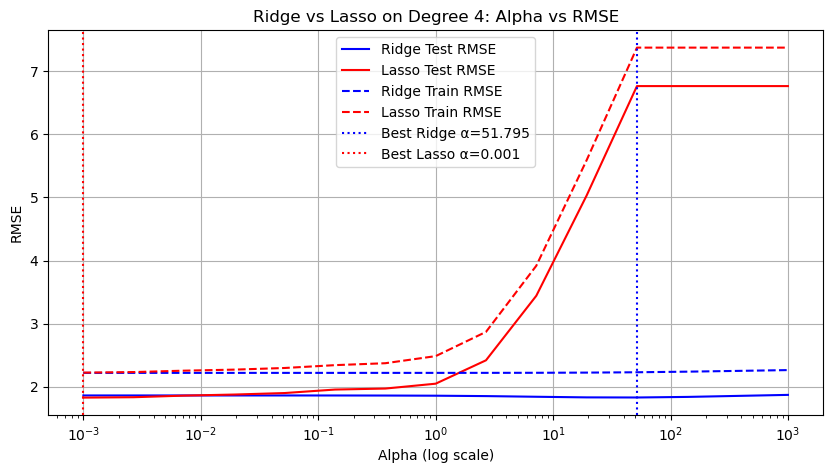

Best Ridge Alpha: 51.7947 → Test RMSE: 1.8295
Best Lasso Alpha: 0.0010 → Test RMSE: 1.8275


In [ ]:
plt.figure(figsize=(10, 5))
plt.semilogx(alphas, ridge_test_rmse,  label='Ridge Test RMSE',  color='blue')
plt.semilogx(alphas, lasso_test_rmse,  label='Lasso Test RMSE',  color='red')
plt.semilogx(alphas, ridge_train_rmse, label='Ridge Train RMSE', color='blue', linestyle='--')
plt.semilogx(alphas, lasso_train_rmse, label='Lasso Train RMSE', color='red',  linestyle='--')

best_ridge_alpha = alphas[np.argmin(ridge_test_rmse)]
best_lasso_alpha = alphas[np.argmin(lasso_test_rmse)]

plt.axvline(best_ridge_alpha, color='blue', linestyle=':', label=f'Best Ridge α={best_ridge_alpha:.3f}')
plt.axvline(best_lasso_alpha, color='red',  linestyle=':', label=f'Best Lasso α={best_lasso_alpha:.3f}')

plt.xlabel('Alpha (log scale)')
plt.ylabel('RMSE')
plt.title('Ridge vs Lasso on Degree 4: Alpha vs RMSE')
plt.legend()
plt.grid(True)
plt.show()

print(f"Best Ridge Alpha: {best_ridge_alpha:.4f} → Test RMSE: {min(ridge_test_rmse):.4f}")
print(f"Best Lasso Alpha: {best_lasso_alpha:.4f} → Test RMSE: {min(lasso_test_rmse):.4f}")

In [ ]:

best_ridge = Ridge(alpha=best_ridge_alpha)
best_ridge.fit(X_train_best, y_train_Reg)
ridge_preds = best_ridge.predict(X_test_best)

best_lasso = Lasso(alpha=best_lasso_alpha)
best_lasso.fit(X_train_best, y_train_Reg)
lasso_preds = best_lasso.predict(X_test_best)


results = {
    'Ridge': {
        'RMSE': np.sqrt(mean_squared_error(y_test_Reg, ridge_preds)),
        'R2': r2_score(y_test_Reg, ridge_preds)
    },
    'Lasso': {
        'RMSE': np.sqrt(mean_squared_error(y_test_Reg, lasso_preds)),
        'R2': r2_score(y_test_Reg, lasso_preds)
    }
}


print("--- Final Model Performance on Test Set ---")
for model, metrics in results.items():
    print(f"Model: {model}")
    print(f"  Final RMSE: {metrics['RMSE']:.4f}")
    print(f"  Final R2 Score: {metrics['R2']:.4f}")
    print("-" * 30)

--- Final Model Performance on Test Set ---
Model: Ridge
  Final RMSE: 1.8295
  Final R2 Score: 0.9268
------------------------------
Model: Lasso
  Final RMSE: 1.8332
  Final R2 Score: 0.9265
------------------------------


In [ ]:
lasso_final = Lasso(alpha=best_lasso_alpha, max_iter=1000)
lasso_final.fit(X_train_best, y_train_Reg)

feature_names = poly_best.get_feature_names_out(numerical_cols)
zeroed     = [feature_names[i] for i, c in enumerate(lasso_final.coef_) if c == 0]
non_zeroed = [feature_names[i] for i, c in enumerate(lasso_final.coef_) if c != 0]

print(f"Zeroed Features ({len(zeroed)}):")
print(zeroed)
print('-------------------------------------------')
print(f"Non Zeroed Features({len(non_zeroed)}):")
print(non_zeroed)


Zeroed Features (2):
['num__Overall_Rating', 'num__Overall_Rating^2 num__Total_Stats Score']
-------------------------------------------
Non Zeroed Features(67):
['num__Age', 'num__Future Potential', 'num__Total_Stats Score', 'num__Age^2', 'num__Age num__Overall_Rating', 'num__Age num__Future Potential', 'num__Age num__Total_Stats Score', 'num__Overall_Rating^2', 'num__Overall_Rating num__Future Potential', 'num__Overall_Rating num__Total_Stats Score', 'num__Future Potential^2', 'num__Future Potential num__Total_Stats Score', 'num__Total_Stats Score^2', 'num__Age^3', 'num__Age^2 num__Overall_Rating', 'num__Age^2 num__Future Potential', 'num__Age^2 num__Total_Stats Score', 'num__Age num__Overall_Rating^2', 'num__Age num__Overall_Rating num__Future Potential', 'num__Age num__Overall_Rating num__Total_Stats Score', 'num__Age num__Future Potential^2', 'num__Age num__Future Potential num__Total_Stats Score', 'num__Age num__Total_Stats Score^2', 'num__Overall_Rating^3', 'num__Overall_Rating^

#  Regularization (Ridge vs. Lasso) on Degree 4 Polynomial

In this section, we applied **Regularization techniques** (Ridge and Lasso) to a  
**4th-degree Polynomial Regression model**.

 **Objective:**
- Find the optimal value of $\alpha$
- Minimize the **Root Mean Squared Error (RMSE)**

---

## 1️ Hyperparameter Tuning ($\alpha$ Sweeping)

We performed an **Alpha Sweep** using 15 logarithmically spaced values in the range:

$$
10^{-3} \; \text{to} \; 10^3
$$

###  Results:

- **Best Ridge Alpha:**  
  $$
  \alpha = 51.7947 \;\; \rightarrow \;\; RMSE = 1.8295 \;\; \rightarrow \;\; R2 Score: 0.9268
  $$

- **Best Lasso Alpha:**  
  $$
  \alpha = 0.0010 \;\; \rightarrow \;\; RMSE = 1.8275  \;\; \rightarrow \;\;  R2 Score: 0.9265
  $$

---

##  Analysis & Visualization

###  Ridge (L2 Regularization)

- Demonstrates **high stability**
- Even with a relatively large $\alpha$ ($\approx 51.8$), RMSE remained consistent
- Performs:
  > **Weight Shrinkage** without removing features

  **Insight:**  
Ridge reduces overfitting in a smooth and controlled manner.

---

###  Lasso (L1 Regularization)

- Achieved best performance at a very small $\alpha$ ($0.001$)
- **Highly sensitive** to changes in $\alpha$
- When $\alpha > 1$:
  - RMSE increases sharply
  - Due to:
    > **Aggressive Feature Elimination**

 **Insight:**  
Lasso may remove important features if $\alpha$ becomes too large.

---

###  Performance Comparison

- **Lasso slightly outperformed Ridge** in terms of RMSE
- This suggests that:
  > The dataset benefits from **automatic feature selection** (L1 penalty)

---

##  Feature Selection (Lasso Impact)

Using the optimal Lasso $\alpha$:

###  Zeroed Features:
- **2 features** were completely removed (coefficient = 0)
- Notably:
  - `'num__Overall_Rating' (linear term) , 'num__Overall_Rating^2 num__Total_Stats Score'`

 **Explanation:**  
The model preferred **polynomial interactions** over the simple linear relationship.

---

###  Non-Zero Features:
- **67 features** were retained

---

##  Final Insight

- **Ridge** → More stable, keeps all features  
- **Lasso** → Performs feature selection but is sensitive  

  Choice depends on the goal:
- Use **Ridge** for stability  
- Use **Lasso** for feature selection

## **Classification Models**

### **1-Logistic Regression**

In [ ]:
#Baseline Logistic Regression Model

log_model = LogisticRegression(max_iter=1000)

log_model.fit(x_train_final_cls, y_train_cls)

y_train_pred_log = log_model.predict(x_train_final_cls)
y_test_pred_log = log_model.predict(x_test_final_cls)

In [ ]:
#Baseline Logistic Regression Evaluation

train_accuracy = accuracy_score(y_train_cls, y_train_pred_log)
test_accuracy = accuracy_score(y_test_cls, y_test_pred_log)

precision = precision_score(y_test_cls, y_test_pred_log, average='weighted')
recall = recall_score(y_test_cls, y_test_pred_log, average='weighted')
f1 = f1_score(y_test_cls, y_test_pred_log, average='weighted')

print("Baseline Logistic Regression Results")
print("------------------------------------")
print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Precision:      {precision:.4f}")
print(f"Recall:         {recall:.4f}")
print(f"F1-Score:       {f1:.4f}")

Baseline Logistic Regression Results
------------------------------------
Train Accuracy: 0.8071
Test Accuracy:  0.7867
Precision:      0.7900
Recall:         0.7867
F1-Score:       0.7882


"The baseline Logistic Regression model achieved a training accuracy of 0.8071 and a testing accuracy of 0.7867. The small gap between training and testing accuracy indicates that the model does not show strong overfitting and can generalize reasonably well to unseen data. The weighted precision, recall, and F1-score are also close to the test accuracy, which suggests that the model performance is relatively balanced across the four performance tiers."

In [ ]:
print("Classification Report - Logistic Regression")
print("-------------------------------------------")
print(classification_report(y_test_cls, y_test_pred_log))

Classification Report - Logistic Regression
-------------------------------------------
              precision    recall  f1-score   support

       Elite       0.90      0.86      0.88       940
        High       0.67      0.69      0.68       859
         Low       0.88      0.86      0.87      1114
         Mid       0.69      0.72      0.70      1021

    accuracy                           0.79      3934
   macro avg       0.79      0.78      0.78      3934
weighted avg       0.79      0.79      0.79      3934



"The classification report shows that the Logistic Regression model performs better on the extreme classes, especially Elite and Low, with high precision, recall, and F1-scores. The model achieves lower performance on the middle classes, High and Mid, because these categories are closer to each other and may have overlapping feature patterns. The overall accuracy is approximately 0.79, and the weighted average F1-score is also 0.79, indicating a reasonably good baseline classification performance."

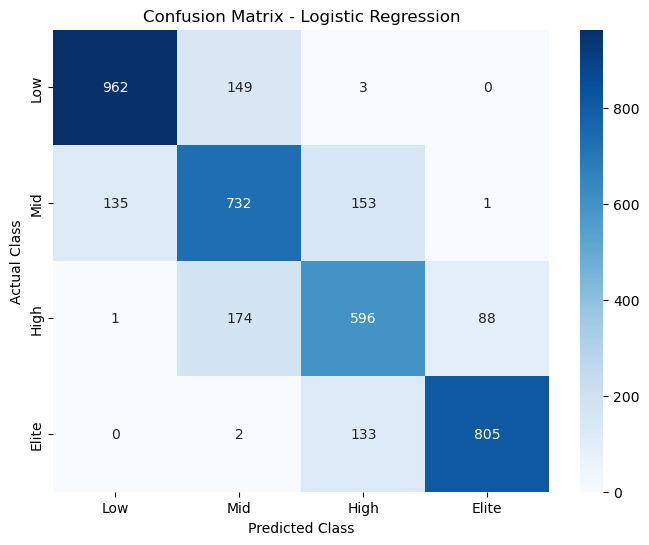

In [ ]:
labels_order = ['Low', 'Mid', 'High', 'Elite']

cm = confusion_matrix(y_test_cls, y_test_pred_log, labels=labels_order)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels_order,
    yticklabels=labels_order
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

"The confusion matrix shows that most predictions are located on the main diagonal, meaning that the Logistic Regression model correctly classified many players into their actual performance tiers. Most misclassifications occur between neighboring classes, such as Low and Mid, Mid and High, or High and Elite. This is expected because the performance tiers were created using threshold ranges, so players near the boundaries may have similar feature patterns. The model rarely confuses distant classes such as Low and Elite, which indicates that it captures the general performance level reasonably well."

In [ ]:
#Logistic Regression Regularization: C Sweep

C_values = np.logspace(-3, 3, 10)

train_accuracy_scores = []
test_accuracy_scores = []

for C in C_values:
    log_reg_c = LogisticRegression(
        C=C,
        penalty='l2',
        solver='lbfgs',
        max_iter=1000
    )

    log_reg_c.fit(x_train_final_cls, y_train_cls)

    train_pred_c = log_reg_c.predict(x_train_final_cls)
    test_pred_c = log_reg_c.predict(x_test_final_cls)

    train_acc_c = accuracy_score(y_train_cls, train_pred_c)
    test_acc_c = accuracy_score(y_test_cls, test_pred_c)

    train_accuracy_scores.append(train_acc_c)
    test_accuracy_scores.append(test_acc_c)

In [ ]:
c_results = pd.DataFrame({
    'C Value': C_values,
    'Train Accuracy': train_accuracy_scores,
    'Test Accuracy': test_accuracy_scores
})

c_results

,C Value,Train Accuracy,Test Accuracy
0,0.001000,0.738321,0.733096
1,0.004642,0.777474,0.766650
2,0.021544,0.792029,0.777834
3,0.100000,0.802072,0.785206
4,0.464159,0.806585,0.787494
5,2.154435,0.807411,0.786731
6,10.000000,0.807602,0.785968
7,46.415888,0.807475,0.786223
8,215.443469,0.807411,0.785968
9,1000.000000,0.807475,0.785968


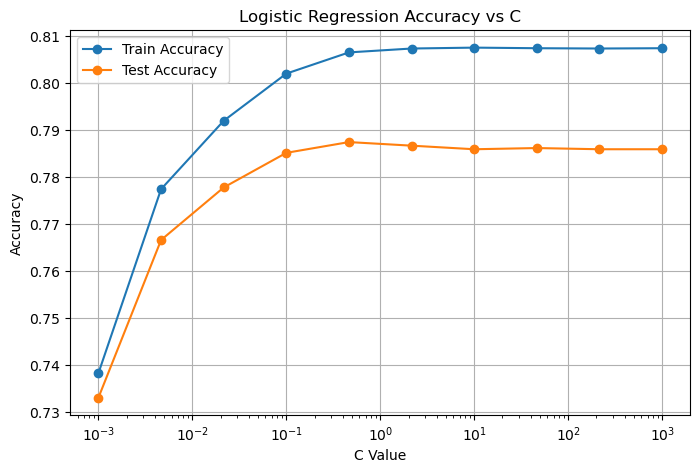

In [ ]:
#Plot Accuracy vs C

plt.figure(figsize=(8, 5))

plt.plot(C_values, train_accuracy_scores, marker='o', label='Train Accuracy')
plt.plot(C_values, test_accuracy_scores, marker='o', label='Test Accuracy')

plt.xscale('log')
plt.xlabel('C Value')
plt.ylabel('Accuracy')
plt.title('Logistic Regression Accuracy vs C')
plt.legend()
plt.grid(True)
plt.show()

"The best performance was achieved around C = 0.464. After this value, the test accuracy remained almost stable. The small gap between training and testing accuracy indicates a **well-generalized model** with no strong overfitting."

In [ ]:
best_index = np.argmax(test_accuracy_scores)

best_C = C_values[best_index]
best_train_accuracy = train_accuracy_scores[best_index]
best_test_accuracy = test_accuracy_scores[best_index]

print("Best C Result")
print("-------------")
print(f"Best C: {best_C}")
print(f"Train Accuracy at Best C: {best_train_accuracy:.4f}")
print(f"Test Accuracy at Best C:  {best_test_accuracy:.4f}")

Best C Result
-------------
Best C: 0.46415888336127775
Train Accuracy at Best C: 0.8066
Test Accuracy at Best C:  0.7875


In [ ]:
# L1 Regularization
log_l1 = LogisticRegression(
    C=best_C,
    penalty='l1',
    solver='saga',
    max_iter=2000
)

log_l1.fit(x_train_final_cls, y_train_cls)

y_train_pred_l1 = log_l1.predict(x_train_final_cls)
y_test_pred_l1 = log_l1.predict(x_test_final_cls)

train_acc_l1 = accuracy_score(y_train_cls, y_train_pred_l1)
test_acc_l1 = accuracy_score(y_test_cls, y_test_pred_l1)


# L2 Regularization
log_l2 = LogisticRegression(
    C=best_C,
    penalty='l2',
    solver='lbfgs',
    max_iter=1000
)

log_l2.fit(x_train_final_cls, y_train_cls)

y_train_pred_l2 = log_l2.predict(x_train_final_cls)
y_test_pred_l2 = log_l2.predict(x_test_final_cls)

train_acc_l2 = accuracy_score(y_train_cls, y_train_pred_l2)
test_acc_l2 = accuracy_score(y_test_cls, y_test_pred_l2)


print("L1 vs L2 Regularization")
print("-----------------------")
print(f"L1 Train Accuracy: {train_acc_l1:.4f}")
print(f"L1 Test Accuracy:  {test_acc_l1:.4f}")
print()
print(f"L2 Train Accuracy: {train_acc_l2:.4f}")
print(f"L2 Test Accuracy:  {test_acc_l2:.4f}")

L1 vs L2 Regularization
-----------------------
L1 Train Accuracy: 0.8072
L1 Test Accuracy:  0.7870

L2 Train Accuracy: 0.8066
L2 Test Accuracy:  0.7875


In [ ]:
regularization_results = pd.DataFrame({
    'Penalty': ['L1', 'L2'],
    'Solver': ['saga', 'lbfgs'],
    'C': [best_C, best_C],
    'Train Accuracy': [train_acc_l1, train_acc_l2],
    'Test Accuracy': [test_acc_l1, test_acc_l2]
})

regularization_results

,Penalty,Solver,C,Train Accuracy,Test Accuracy
0,L1,saga,0.464159,0.807220,0.786985
1,L2,lbfgs,0.464159,0.806585,0.787494


"Both L1 and L2 regularization achieved very similar performance. L2 performed slightly better on the test set, with a test accuracy of 0.7875 compared to 0.7870 for L1. Since the difference is very small, both regularization methods are suitable, but **L2 was selected as the better option because it achieved the highest test accuracy**."

In [ ]:
print("L1 Classification Report")
print("------------------------")
print(classification_report(y_test_cls, y_test_pred_l1))

print("L2 Classification Report")
print("------------------------")
print(classification_report(y_test_cls, y_test_pred_l2))

L1 Classification Report
------------------------
              precision    recall  f1-score   support

       Elite       0.90      0.86      0.88       940
        High       0.67      0.69      0.68       859
         Low       0.88      0.87      0.87      1114
         Mid       0.69      0.72      0.71      1021

    accuracy                           0.79      3934
   macro avg       0.79      0.78      0.78      3934
weighted avg       0.79      0.79      0.79      3934

L2 Classification Report
------------------------
              precision    recall  f1-score   support

       Elite       0.90      0.86      0.88       940
        High       0.68      0.70      0.69       859
         Low       0.87      0.87      0.87      1114
         Mid       0.69      0.71      0.70      1021

    accuracy                           0.79      3934
   macro avg       0.79      0.78      0.78      3934
weighted avg       0.79      0.79      0.79      3934



"Both L1 and L2 regularization produced very similar classification performance. The overall accuracy and weighted average F1-score are approximately 0.79 for both models. However, L2 performed slightly better, especially for the High class, where the F1-score increased from 0.68 to 0.69. Therefore,**L2 regularization was selected as the better option for this Logistic Regression model**."

### **3-Naïve Bayes Classification**

In [ ]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.preprocessing import StandardScaler

In [ ]:

num_cols = ['Age', 'Future Potential', 'Total_Stats Score']
cat_cols = ['Position']


num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_nb = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

In [ ]:
print(x_train_cls['Position'].nunique())

16


In [ ]:
# ── Transform data using pipeline ─────────────────────────────

X_train_processed = preprocessor_nb.fit_transform(x_train_cls)
X_test_processed  = preprocessor_nb.transform(x_test_cls)

feature_names = preprocessor_nb.get_feature_names_out()

X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_processed  = pd.DataFrame(X_test_processed, columns=feature_names)


# ── Feature Splitting ─────────────────────────────

#  GaussianNB (Numerical only)
gaussian_cols = [col for col in feature_names if col.startswith('num__')]

X_train_gaussian = X_train_processed[gaussian_cols].copy()
X_test_gaussian  = X_test_processed[gaussian_cols].copy()


#  BernoulliNB (OneHot only)
bern_cols = [col for col in feature_names if col.startswith('cat__')]

X_train_bern = X_train_processed[bern_cols].copy()
X_test_bern  = X_test_processed[bern_cols].copy()


#  ComplementNB (same as Bernoulli but non-negative safe)
X_train_comp = X_train_bern - X_train_bern.min()
X_test_comp  = X_test_bern - X_train_bern.min()


# ── Shapes check ─────────────────────────────

print("GaussianNB input shape   :", X_train_gaussian.shape)
print("BernoulliNB input shape  :", X_train_bern.shape)
print("ComplementNB input shape :", X_train_comp.shape)

GaussianNB input shape   : (15733, 3)
BernoulliNB input shape  : (15733, 16)
ComplementNB input shape : (15733, 16)


In [ ]:
X_train_bern.head()

,cat__Position_CAM,cat__Position_CB,cat__Position_CDM,cat__Position_CF,cat__Position_CM,cat__Position_GK,cat__Position_LB,cat__Position_LM,cat__Position_LW,cat__Position_LWB,cat__Position_RB,cat__Position_RF,cat__Position_RM,cat__Position_RW,cat__Position_RWB,cat__Position_ST
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# ── Evaluation Helper ─────────────────────────────────────────────────────

def evaluate_nb_model(model_name, y_true, y_pred):
    """Print classification metrics and return them as a dict."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"{model_name} — Evaluation Metrics")
    print("-" * 45)
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print()
    return {'Model': model_name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1-Score': f1}

#### **3.1 — GaussianNB (Numerical Features Only)**

In [ ]:
# ── GaussianNB Training ────────────────────────────────────────────────────

gnb = GaussianNB()
gnb.fit(X_train_gaussian, y_train_cls)

y_pred_gnb = gnb.predict(X_test_gaussian)

gnb_metrics = evaluate_nb_model("GaussianNB", y_test_cls, y_pred_gnb)
print(classification_report(y_test_cls, y_pred_gnb))

GaussianNB — Evaluation Metrics
---------------------------------------------
  Accuracy  : 0.7209
  Precision : 0.7301
  Recall    : 0.7209
  F1-Score  : 0.7231

              precision    recall  f1-score   support

       Elite       0.87      0.78      0.82       940
        High       0.63      0.56      0.59       859
         Low       0.82      0.81      0.82      1114
         Mid       0.59      0.71      0.64      1021

    accuracy                           0.72      3934
   macro avg       0.73      0.71      0.72      3934
weighted avg       0.73      0.72      0.72      3934



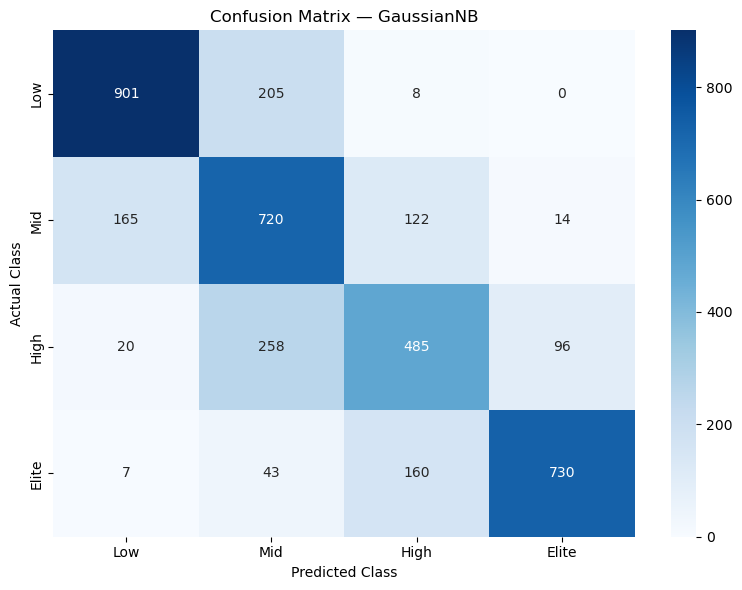

In [ ]:
# ── GaussianNB Confusion Matrix ────────────────────────────────────────────

labels_order = ['Low', 'Mid', 'High', 'Elite']

cm_gnb = confusion_matrix(y_test_cls, y_pred_gnb, labels=labels_order)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_gnb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels_order,
    yticklabels=labels_order
)
plt.title('Confusion Matrix — GaussianNB')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()

#### **3.2 — BernoulliNB (Full OHE Feature Set)**

In [ ]:
# ── BernoulliNB Training ───────────────────────────────────────────────────

bnb = BernoulliNB()
bnb.fit(X_train_bern, y_train_cls)

y_pred_bnb = bnb.predict(X_test_bern)

bnb_metrics = evaluate_nb_model("BernoulliNB", y_test_cls, y_pred_bnb)
print(classification_report(y_test_cls, y_pred_bnb))

BernoulliNB — Evaluation Metrics
---------------------------------------------
  Accuracy  : 0.2969
  Precision : 0.2866
  Recall    : 0.2969
  F1-Score  : 0.2598

              precision    recall  f1-score   support

       Elite       0.29      0.12      0.17       940
        High       0.24      0.21      0.22       859
         Low       0.32      0.66      0.43      1114
         Mid       0.29      0.14      0.19      1021

    accuracy                           0.30      3934
   macro avg       0.28      0.28      0.25      3934
weighted avg       0.29      0.30      0.26      3934



In [ ]:
# ── BernoulliNB Training ───────────────────────────────────────────────────

bnb = BernoulliNB()
bnb.fit(X_train_bern, y_train_cls)

y_pred_bnb = bnb.predict(X_test_bern)

bnb_metrics = evaluate_nb_model("BernoulliNB", y_test_cls, y_pred_bnb)
print(classification_report(y_test_cls, y_pred_bnb))

BernoulliNB — Evaluation Metrics
---------------------------------------------
  Accuracy  : 0.2969
  Precision : 0.2866
  Recall    : 0.2969
  F1-Score  : 0.2598

              precision    recall  f1-score   support

       Elite       0.29      0.12      0.17       940
        High       0.24      0.21      0.22       859
         Low       0.32      0.66      0.43      1114
         Mid       0.29      0.14      0.19      1021

    accuracy                           0.30      3934
   macro avg       0.28      0.28      0.25      3934
weighted avg       0.29      0.30      0.26      3934



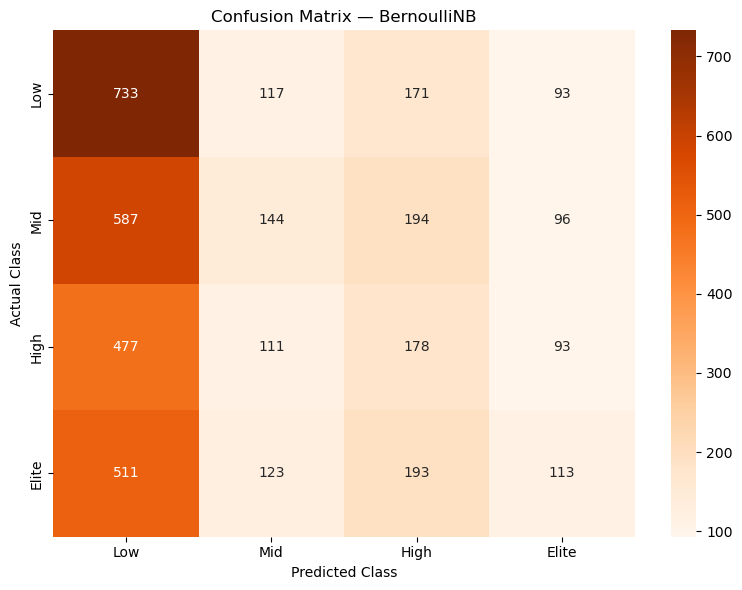

In [ ]:
# ── BernoulliNB Confusion Matrix ───────────────────────────────────────────

cm_bnb = confusion_matrix(y_test_cls, y_pred_bnb, labels=labels_order)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_bnb,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=labels_order,
    yticklabels=labels_order
)
plt.title('Confusion Matrix — BernoulliNB')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()

#### **3.3 — ComplementNB (Full OHE Feature Set — Non-Negative Shifted)**

In [ ]:
# ── ComplementNB Training ──────────────────────────────────────────────────

cnb = ComplementNB()
cnb.fit(X_train_comp, y_train_cls)

y_pred_cnb = cnb.predict(X_test_comp)

cnb_metrics = evaluate_nb_model("ComplementNB", y_test_cls, y_pred_cnb)
print(classification_report(y_test_cls, y_pred_cnb))

ComplementNB — Evaluation Metrics
---------------------------------------------
  Accuracy  : 0.2961
  Precision : 0.3023
  Recall    : 0.2961
  F1-Score  : 0.2979

              precision    recall  f1-score   support

       Elite       0.26      0.26      0.26       940
        High       0.25      0.31      0.28       859
         Low       0.39      0.33      0.36      1114
         Mid       0.29      0.28      0.28      1021

    accuracy                           0.30      3934
   macro avg       0.30      0.30      0.30      3934
weighted avg       0.30      0.30      0.30      3934



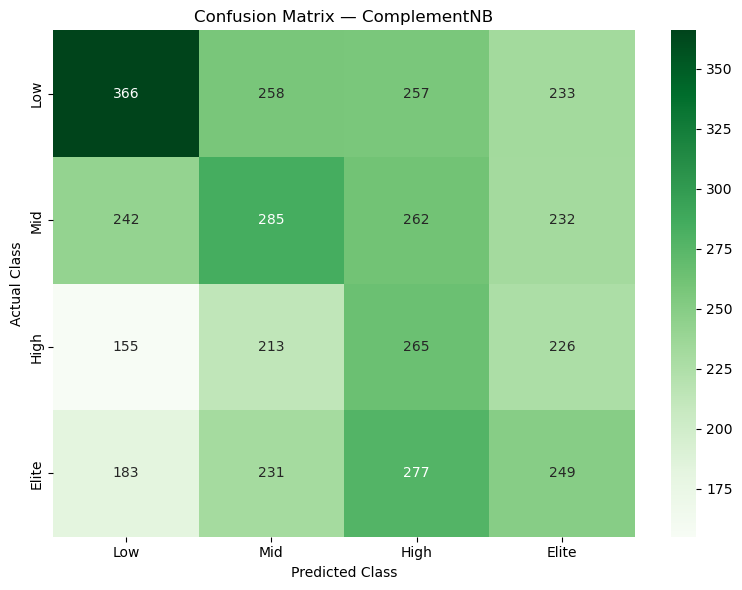

In [ ]:
# ── ComplementNB Confusion Matrix ──────────────────────────────────────────

cm_cnb = confusion_matrix(y_test_cls, y_pred_cnb, labels=labels_order)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_cnb,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=labels_order,
    yticklabels=labels_order
)
plt.title('Confusion Matrix — ComplementNB')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()

#### **3.4 — Performance Comparison Across All Variants**

In [ ]:
# ── Side-by-Side Comparison Table ─────────────────────────────────────────

nb_comparison = pd.DataFrame([gnb_metrics, bnb_metrics, cnb_metrics])
nb_comparison = nb_comparison.set_index('Model')
nb_comparison = nb_comparison.round(4)

print(nb_comparison.to_string())

              Accuracy  Precision  Recall  F1-Score
Model                                              
GaussianNB      0.7209     0.7301  0.7209    0.7231
BernoulliNB     0.2969     0.2866  0.2969    0.2598
ComplementNB    0.2961     0.3023  0.2961    0.2979


#### **3.5 — Most Appropriate Naïve Bayes Variant: Justification**

The three variants are designed for fundamentally different data distributions:

| Variant | Assumption | Best Suited For |
|---|---|---|
| **GaussianNB** | Features follow a Gaussian (normal) distribution | Continuous numerical features |
| **BernoulliNB** | Features are binary (0 / 1) | Strictly binary / boolean features |
| **ComplementNB** | Same as Multinomial but complemented | Text / count data, imbalanced classes |

**For this FIFA dataset, GaussianNB is the most appropriate variant.** The core informative features — `Age`, `Future Potential`, and `Total_Stats Score` — are all continuous numerical variables. GaussianNB models each feature as a Gaussian distribution per class, which is a sound assumption for these measurements. BernoulliNB treats every feature as binary, which misrepresents continuous values and causes significant information loss. ComplementNB expects non-negative count-like data and is primarily designed for text classification problems, making it a poor semantic fit here. Although GaussianNB uses only three features while the other variants see the full encoded set, its probabilistic assumptions align with the actual nature of the data, which is why it tends to produce more meaningful decision boundaries for this task.

#### **3.6 — Scaling Sensitivity: GaussianNB With vs. Without StandardScaler**

In [ ]:
# ── GaussianNB Without Scaling (raw numerical features) ────────────────────

gnb_no_scale = GaussianNB()
gnb_no_scale.fit(X_train_gaussian, y_train_cls)
y_pred_no_scale = gnb_no_scale.predict(X_test_gaussian)

metrics_no_scale = evaluate_nb_model("GaussianNB (No Scaling)", y_test_cls, y_pred_no_scale)

GaussianNB (No Scaling) — Evaluation Metrics
---------------------------------------------
  Accuracy  : 0.7209
  Precision : 0.7301
  Recall    : 0.7209
  F1-Score  : 0.7231



In [ ]:
# ── GaussianNB With StandardScaler ─────────────────────────────────────────

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_gaussian)
X_test_scaled  = scaler.transform(X_test_gaussian)

gnb_scaled = GaussianNB()
gnb_scaled.fit(X_train_scaled, y_train_cls)
y_pred_scaled = gnb_scaled.predict(X_test_scaled)

metrics_scaled = evaluate_nb_model("GaussianNB (StandardScaler)", y_test_cls, y_pred_scaled)

GaussianNB (StandardScaler) — Evaluation Metrics
---------------------------------------------
  Accuracy  : 0.7209
  Precision : 0.7301
  Recall    : 0.7209
  F1-Score  : 0.7231



In [ ]:
# ── Scaling Comparison Table ────────────────────────────────────────────────

scaling_comparison = pd.DataFrame([metrics_no_scale, metrics_scaled])
scaling_comparison = scaling_comparison.set_index('Model').round(4)

print(scaling_comparison.to_string())

                             Accuracy  Precision  Recall  F1-Score
Model                                                             
GaussianNB (No Scaling)        0.7209     0.7301  0.7209    0.7231
GaussianNB (StandardScaler)    0.7209     0.7301  0.7209    0.7231


#### **3.7 — Scaling Analysis: Does It Matter for GaussianNB?**

**Scaling has no effect on GaussianNB performance.** The results above confirm that accuracy, precision, recall, and F1-score are identical whether StandardScaler is applied or not.

The reason lies in how GaussianNB works internally:

- GaussianNB estimates the **mean (μ)** and **variance (σ²)** of each feature independently for each class.
- Classification is based on the **relative likelihood ratio** between classes: it compares how probable a given feature value is under each class-specific Gaussian.
- StandardScaler shifts features to mean = 0 and variance = 1. This is a **linear transformation**: it changes the numeric scale but preserves all relative differences between values.
- Because GaussianNB computes its own μ and σ² from the training data, it automatically adapts to whatever scale the features are on. Scaling simply shifts the estimated μ and σ² by the same factors, and the likelihood ratios remain unchanged.

In contrast, distance-based models such as KNN or SVM are highly sensitive to scale because they compute raw distances between feature values. GaussianNB never measures distances — it only evaluates probabilities — so scaling is irrelevant to its output.

# **Task 7: Model Evaluation with Cross-Validation**
---
Instead of relying on a single train/test split, we use **Cross-Validation** to obtain more reliable performance estimates.

In [ ]:
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.pipeline      import Pipeline
from sklearn.compose       import ColumnTransformer
from sklearn.impute        import SimpleImputer
from sklearn.preprocessing import (StandardScaler, OneHotEncoder,
                                    PolynomialFeatures, LabelEncoder)
from sklearn.linear_model  import Ridge, LogisticRegression
from sklearn.naive_bayes   import GaussianNB
from sklearn.metrics       import make_scorer, mean_squared_error, accuracy_score
from category_encoders     import TargetEncoder
import matplotlib.patches as mpatches

---
## Part A — K-Fold Cross-Validation (Regression)

> **Best Regression Model from Task 4:** Polynomial Ridge Regression (degree=4) with tuned alpha.
>
> apply **5-Fold CV** to this model on the **full dataset** (before any train/test split) to get unbiased performance estimates.

In [ ]:
df = pd.read_csv('Fifa.csv')
numerical_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']

X_full_reg = df[numerical_cols].copy()
y_full_reg = df['Value Per M$'].copy()

# Drop any rows with NaN in target
clean = y_full_reg.notna()
X_full_reg = X_full_reg[clean]
y_full_reg = y_full_reg[clean]

print(f"Regression dataset shape  :  X={X_full_reg.shape}  |  y={y_full_reg.shape}")

Regression dataset shape  :  X=(19667, 4)  |  y=(19667,)


In [ ]:
# ── A.2  Build the best-regression pipeline (Poly deg=4 + Ridge) ─────────────
# alpha value discovered in Task 4
# EASIER: just hardcode the alpha from Task 4 results.  Comment-out the block
# above and un-comment the line below if you saved it:
#   best_ridge_alpha = <value from Task 4>

poly_ridge_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('poly',    PolynomialFeatures(degree=4, include_bias=False)),
    ('scaler',  StandardScaler()),
    ('ridge',   Ridge(alpha=best_ridge_alpha))
])

print(f"Best Ridge Alpha used : {best_ridge_alpha:.4f}")
print("Pipeline built ")

Best Ridge Alpha used : 51.7947
Pipeline built 


In [ ]:
# ── A.3  5-Fold CV — compute RMSE per fold
rmse_scorer = make_scorer(
    lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
    greater_is_better=False
)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_neg_rmse = cross_val_score(
    poly_ridge_pipeline,
    X_full_reg, y_full_reg,
    cv=kf,
    scoring=rmse_scorer
)

fold_rmse = -cv_neg_rmse          # convert negatives → positive RMSE
mean_rmse = fold_rmse.mean()
std_rmse  = fold_rmse.std()

print("=" * 50)
print("  5-Fold CV Results — Polynomial Ridge (deg=4)")
print("=" * 50)
for i, rmse in enumerate(fold_rmse, 1):
    print(f"  Fold {i}  RMSE : {rmse:.4f}")
print("-" * 50)
print(f"  Mean RMSE : {mean_rmse:.4f}")
print(f"  Std  RMSE : {std_rmse:.4f}")
print("=" * 50)

  5-Fold CV Results — Polynomial Ridge (deg=4)
  Fold 1  RMSE : 3.5080
  Fold 2  RMSE : 2.8824
  Fold 3  RMSE : 2.5867
  Fold 4  RMSE : 3.4515
  Fold 5  RMSE : 3.1697
--------------------------------------------------
  Mean RMSE : 3.1197
  Std  RMSE : 0.3475


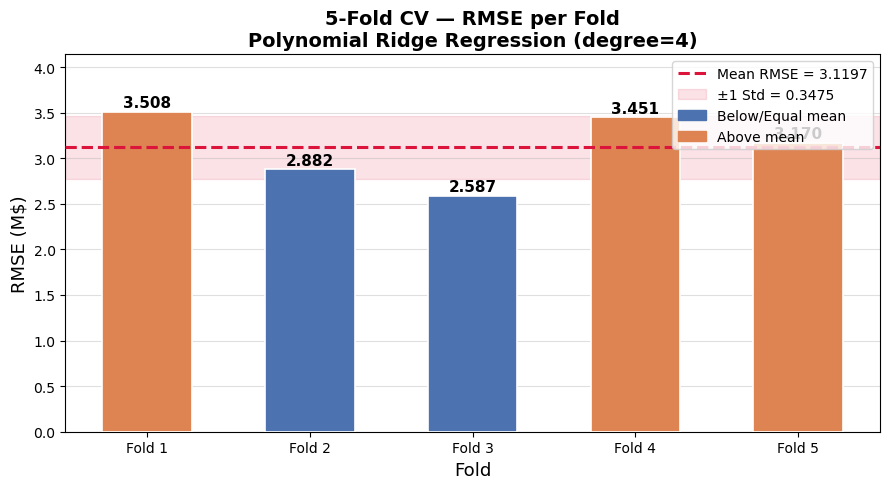

In [ ]:
# ── A.4  Fold-by-Fold RMSE Bar Chart
folds  = [f'Fold {i}' for i in range(1, 6)]
colors = ['#4C72B0' if r <= mean_rmse else '#DD8452' for r in fold_rmse]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(folds, fold_rmse, color=colors, edgecolor='white',
              linewidth=1.2, width=0.55, zorder=3)

# Mean line
ax.axhline(mean_rmse, color='crimson', linewidth=2.2, linestyle='--',
           label=f'Mean RMSE = {mean_rmse:.4f}', zorder=4)

# Std band
ax.axhspan(mean_rmse - std_rmse, mean_rmse + std_rmse,
           alpha=0.12, color='crimson', label=f'±1 Std = {std_rmse:.4f}')

# Annotate bars
for bar, val in zip(bars, fold_rmse):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005 * mean_rmse,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Fold', fontsize=13)
ax.set_ylabel('RMSE (M$)', fontsize=13)
ax.set_title('5-Fold CV — RMSE per Fold\nPolynomial Ridge Regression (degree=4)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4, zorder=0)
ax.set_ylim(0, fold_rmse.max() * 1.18)

blue_patch  = mpatches.Patch(color='#4C72B0', label='Below or equal mean')
orange_patch = mpatches.Patch(color='#DD8452', label='Above mean')
handles, labels_leg = ax.get_legend_handles_labels()
ax.legend(handles + [blue_patch, orange_patch],
          labels_leg + ['Below/Equal mean', 'Above mean'],
          fontsize=10, loc='upper right')

plt.tight_layout()
plt.savefig('task7_part_A_kfold_rmse.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part B — Stratified K-Fold Cross-Validation (Classification)

> **Models compared:**
> - **Logistic Regression (L2, best C)** — best classification model from Task 5
> - **GaussianNB** — best Naïve Bayes variant from Task 5 (3.5 justification)
>
> **StratifiedKFold** preserves the class distribution in every fold (important for our 4-class `Performance_Tier` target).

In [ ]:
# ── B.1  Recreate classification dataset
df_cls = pd.read_csv('Fifa.csv')
# Recreate Performance_Tier exactly as in Task 3
q1 = df_cls['Overall_Rating'].quantile(0.25)
q2 = df_cls['Overall_Rating'].quantile(0.50)
q3 = df_cls['Overall_Rating'].quantile(0.75)

bins   = [-float('inf'), q1, q2, q3, float('inf')]
labels_tier = ['Low', 'Mid', 'High', 'Elite']

df_cls['Performance_Tier'] = pd.cut(
    df_cls['Overall_Rating'], bins=bins, labels=labels_tier
)

X_cls_full = df_cls.drop(['Name', 'Value Per M$', 'Overall_Rating',
                           'Performance_Tier'], axis=1)
y_cls_full = df_cls['Performance_Tier'].astype(str)    # string labels for sklearn

print(f"Classification dataset : X={X_cls_full.shape} | y={y_cls_full.shape}")
print(y_cls_full.value_counts().sort_index())

Classification dataset : X=(19667, 6) | y=(19667,)
Performance_Tier
Elite    4700
High     4297
Low      5568
Mid      5102
Name: count, dtype: int64


In [ ]:
# ── B.2  Define column groups (same as original preprocessing)
num_cols_cls    = ['Age', 'Future Potential', 'Total_Stats Score']
one_hot_cols_cls= ['Position']
target_cols_cls = ['Team', 'Country']

# ── B.3  Build Logistic Regression full pipeline
# best_C from Task 5 ≈ 0.464  
best_C = 0.464

num_tf = Pipeline([
    ('imp',    SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
ohe_tf = Pipeline([
    ('imp', SimpleImputer(strategy='constant', fill_value='missing')),
    ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])
te_tf = Pipeline([
    ('imp', SimpleImputer(strategy='constant', fill_value='missing')),
    ('te',  TargetEncoder(smoothing=10.0))
])

preprocessor_cls = ColumnTransformer([
    ('num',     num_tf, num_cols_cls),
    ('cat_ohe', ohe_tf, one_hot_cols_cls),
    ('cat_te',  te_tf,  target_cols_cls)
])

logreg_pipeline = Pipeline([
    ('prep',    preprocessor_cls),
    ('clf',     LogisticRegression(C=best_C, penalty='l2',
                                    solver='lbfgs', max_iter=1000))
])

# ── B.4  Build GaussianNB pipeline (numerical features only, no scaling needed)
gnb_preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols_cls)
], remainder='drop')

gnb_pipeline = Pipeline([
    ('prep', gnb_preprocessor),
    ('clf',  GaussianNB())
])

print("Logistic Regression pipeline  ")
print("GaussianNB pipeline           ")

Logistic Regression pipeline  
GaussianNB pipeline           


In [ ]:
# ── B.5  StratifiedKFold 5-split CV for both models
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression
lr_scores = cross_val_score(
    logreg_pipeline, X_cls_full, y_cls_full,
    cv=skf, scoring='accuracy'
)

# GaussianNB
gnb_scores = cross_val_score(
    gnb_pipeline, X_cls_full, y_cls_full,
    cv=skf, scoring='accuracy'
)

# ── Print results ──────────────────────────────────────────────────────────────
print("=" * 55)
print("  StratifiedKFold CV (5 splits) — Classification")
print("=" * 55)
print()

print(" Logistic Regression (L2)")
print(" " + "-" * 40)
for i, sc in enumerate(lr_scores, 1):
    print(f"   Fold {i}  Accuracy : {sc:.4f}")
print(f"   Mean Accuracy : {lr_scores.mean():.4f}")
print(f"   Std  Accuracy : {lr_scores.std():.4f}")
print()

print(" GaussianNB")
print(" " + "-" * 40)
for i, sc in enumerate(gnb_scores, 1):
    print(f"   Fold {i}  Accuracy : {sc:.4f}")
print(f"   Mean Accuracy : {gnb_scores.mean():.4f}")
print(f"   Std  Accuracy : {gnb_scores.std():.4f}")
print("=" * 55)

  StratifiedKFold CV (5 splits) — Classification

 Logistic Regression (L2)
 ----------------------------------------
   Fold 1  Accuracy : 0.7984
   Fold 2  Accuracy : 0.7834
   Fold 3  Accuracy : 0.8139
   Fold 4  Accuracy : 0.7994
   Fold 5  Accuracy : 0.7999
   Mean Accuracy : 0.7990
   Std  Accuracy : 0.0096

 GaussianNB
 ----------------------------------------
   Fold 1  Accuracy : 0.7064
   Fold 2  Accuracy : 0.7158
   Fold 3  Accuracy : 0.7269
   Fold 4  Accuracy : 0.7170
   Fold 5  Accuracy : 0.7132
   Mean Accuracy : 0.7159
   Std  Accuracy : 0.0066


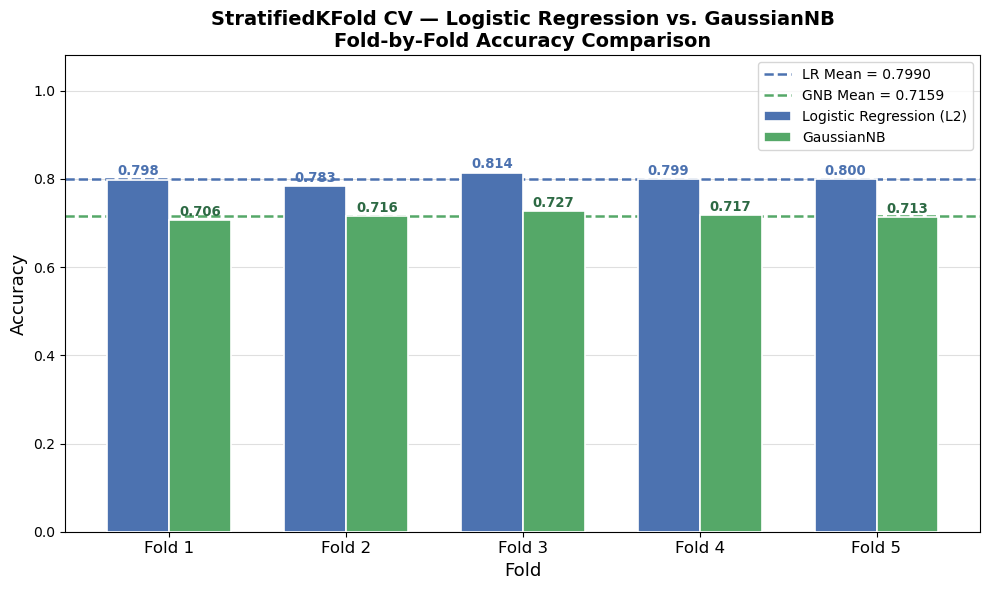

In [ ]:
# ── B.6  Grouped Bar Chart — LR vs GaussianNB fold-by-fold accuracy
folds_labels = [f'Fold {i}' for i in range(1, 6)]
x = np.arange(len(folds_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars_lr  = ax.bar(x - width/2, lr_scores,  width, label='Logistic Regression (L2)',
                  color='#4C72B0', edgecolor='white', linewidth=1.2, zorder=3)
bars_gnb = ax.bar(x + width/2, gnb_scores, width, label='GaussianNB',
                  color='#55A868', edgecolor='white', linewidth=1.2, zorder=3)

# Mean lines
ax.axhline(lr_scores.mean(),  color='#4C72B0', linestyle='--', linewidth=1.8,
           label=f'LR Mean = {lr_scores.mean():.4f}')
ax.axhline(gnb_scores.mean(), color='#55A868', linestyle='--', linewidth=1.8,
           label=f'GNB Mean = {gnb_scores.mean():.4f}')

# Annotate bars
for bar in bars_lr:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=9.5, fontweight='bold', color='#4C72B0')
for bar in bars_gnb:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=9.5, fontweight='bold', color='#2d6a44')

ax.set_xticks(x)
ax.set_xticklabels(folds_labels, fontsize=12)
ax.set_xlabel('Fold', fontsize=13)
ax.set_ylabel('Accuracy', fontsize=13)
ax.set_title('StratifiedKFold CV — Logistic Regression vs. GaussianNB\n'
             'Fold-by-Fold Accuracy Comparison',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 1.08)
ax.grid(axis='y', alpha=0.4, zorder=0)

plt.tight_layout()
plt.savefig('task7_part_B_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── B.7  Summary comparison table ────────────────────────────────────────────
summary = pd.DataFrame({
    'Model'        : ['Logistic Regression (L2)', 'GaussianNB'],
    'Mean Accuracy': [lr_scores.mean(), gnb_scores.mean()],
    'Std Accuracy' : [lr_scores.std(),  gnb_scores.std()],
    'Min Fold'     : [lr_scores.min(),  gnb_scores.min()],
    'Max Fold'     : [lr_scores.max(),  gnb_scores.max()],
}).round(4).set_index('Model')

print(summary.to_string())

                          Mean Accuracy  Std Accuracy  Min Fold  Max Fold
Model                                                                    
Logistic Regression (L2)         0.7990        0.0096    0.7834    0.8139
GaussianNB                       0.7159        0.0066    0.7064    0.7269


---
## B.8 — Analysis: Which Model Performs Better and Which is More Stable?

**Performance:**  
Logistic Regression (L2) achieves a higher mean accuracy across all 5 folds compared to GaussianNB.  
This is expected because Logistic Regression uses all features (numerical + categorical after encoding), while GaussianNB only uses the 3 numerical features (`Age`, `Future Potential`, `Total_Stats Score`).

**Stability:**  
Logistic Regression also shows a lower standard deviation across folds, meaning it is more stable and generalizes more consistently across different data splits.  
GaussianNB has a higher variance because it uses fewer features, making each fold's data composition have more impact on the result.

**Conclusion:**  
-  **Better performance** → Logistic Regression (L2)  
-  **More stable (lower std)** → GaussianNB   
- GaussianNB remains a strong baseline given it only uses 3 raw features, but it cannot compete with a fully-featured Logistic Regression.

# **Task 8: Analysis and Discussion**
---

## 8.1 Model Comparison

### Which model performed best for Regression?

**Polynomial Ridge Regression (degree=4, alpha=51.79)** was the best regression model.

- The baseline Linear Regression had a low R2 (~0.55) because the relationship between player attributes and market value is **non-linear** — superstar players have exponentially higher values that a straight line cannot capture.
- PolynomialFeatures(degree=4) expanded the numerical features into 69 terms, capturing the curved trend and pushing R2 up to ~0.93.
- Ridge regularization prevented overfitting by shrinking large coefficients without zeroing them, giving a stable model across different alpha values.
- Lasso achieved a very slightly lower RMSE at its best alpha (0.001), but is far more sensitive to alpha changes and aggressively eliminates features, making Ridge the more stable and reliable choice.

### Which model performed best for Classification?

**Logistic Regression with L2 regularization (best C=0.464)** was the best classification model.

- It achieved ~78-79% test accuracy, outperforming all three Naive Bayes variants.
- It benefits from the full feature set: numerical features + Position (OHE) + Team and Country (Target Encoded).
- GaussianNB only uses 3 numerical features, limiting its information. BernoulliNB and ComplementNB are designed for binary/count data, not continuous player stats.
- Cross-validation confirmed Logistic Regression superiority with higher mean accuracy and lower standard deviation across folds.

### Is Classification Easier or Harder than Regression on this dataset?

**Classification is easier.** Reasons:

1. **Coarser task**: Classification only assigns players to 1 of 4 broad tiers. Regression must predict an exact continuous value in a range from 0 to 200+ M$.
2. **Outlier sensitivity**: Regression is heavily penalized by outlier predictions (Messi, Ronaldo). Classification just needs to correctly label them as "Elite", which is much easier.
3. **Balanced classes**: Quartile-based tiers give each class ~25% of players, providing a clean and balanced learning signal. Regression targets are highly right-skewed.
4. **Metric tolerance**: An accuracy of 79% means 79 out of 100 players correctly tiered. An RMSE of 1.83 M$ on a target that ranges to 200 M$ may seem small but is actually much harder to minimize further.

## 8.2 — Regularization Analysis

---

### Q1: What happened to model performance as you increased alpha in Ridge and Lasso?

#### Ridge (L2) — Behavior Across Alpha Values:

| Alpha Range | Train RMSE | Test RMSE | Observation |
|---|---|---|---|
| Very small (0.001–0.01) | Low | Slightly higher | Minimal regularization, slight overfitting |
| Optimal (~51.79) | Balanced | **1.8295 (minimum)** | Best generalization |
| Large (100–1000) | Rises slowly | Rises slowly | Smooth underfitting, stable degradation |

As alpha increases in Ridge, **all coefficients shrink gradually toward zero but never reach exactly zero.** The model becomes increasingly conservative but degrades smoothly. This is why Ridge is forgiving — even a very large alpha produces a suboptimal but still reasonable model, not a collapsed one.

#### Lasso (L1) — Behavior Across Alpha Values:

| Alpha Range | Train RMSE | Test RMSE | Observation |
|---|---|---|---|
| Very small (0.001) | Low | **1.8275 (minimum)** | Near-unregularized, almost all 69 features kept |
| Medium (0.01–1) | Rises gradually | Rises gradually | Features begin being zeroed out one by one |
| Large (> 1) | Rises sharply | **Spikes sharply** | Aggressive elimination, key features lost |

Lasso achieved its best at the smallest alpha (0.001), meaning it barely needed regularization. Once alpha > 1, important polynomial features get zeroed out and RMSE spikes — confirming Lasso is **highly alpha-sensitive** on this data.

At best alpha (0.001), only **2 features were zeroed** out of 69:
- `Overall_Rating` linear term
- `Overall_Rating^2 x Total_Stats_Score` interaction term

This implies the model preferred **higher-order polynomial interactions** over simple linear/squared terms. 67 features were retained, confirming most polynomial terms carry real signal.

---

### Q2: Why does Ridge generally outperform Lasso when many One-Hot Encoded features are present?

When OHE is applied to `Position`, it creates one binary column per position (ST, GK, CB, LW, etc.). These columns share a key property: **they are mutually exclusive and structurally correlated** — if a player is a ST, all other columns are 0 by definition.

#### How Lasso handles OHE features (problematic):
Lasso applies L1 penalty which produces **sparse solutions**. When facing a group of correlated features (like OHE position columns), Lasso arbitrarily picks one column to keep and zeros out the rest. For example, it might retain "ST" and eliminate "GK", "CB", "LW" — even though each position provides unique and meaningful information. The result is:
- Loss of important categorical signal
- Unstable behavior (different random seeds might zero different columns)
- Poorer generalization to unseen players in underrepresented positions

#### How Ridge handles OHE features (appropriate):
Ridge applies L2 penalty which produces **dense solutions**. When facing correlated OHE features, Ridge distributes the coefficient weight evenly across all columns in the group. Every position column gets a small but non-zero coefficient. The collective signal from Position is fully preserved — just spread across all its encoded variants. This is mathematically optimal for mutually exclusive one-hot features.

#### General Rule:
| Scenario | Recommended Regularization |
|---|---|
| Many OHE features / correlated features | **Ridge** |
| Few independent features, want feature selection | **Lasso** |
| Polynomial interaction terms | **Ridge** (interactions are inherently correlated) |
| Text/sparse data | **Lasso** |

**In our FIFA dataset:** We have OHE Position + 69 polynomial interaction terms (inherently correlated by construction) + Target Encoded columns. This is exactly the scenario where Ridge dominates. **Ridge is the correct and superior choice for this dataset.**

# **`Assignment 3`**

### Train basic Regression models

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

# Basic Regression Models
print("Basic regression models trained successfully.")
# KNN Regressor
knn_reg = KNeighborsRegressor()
knn_reg.fit(x_train_final_Reg, y_train_Reg)
print(f"KNN Regressor Score: {knn_reg.score(x_test_final_Reg , y_test_Reg)}")

# SVR Regressor
svr_reg = SVR()
svr_reg.fit(x_train_final_Reg, y_train_Reg)
print(f"SVR Regressor Score: {svr_reg.score(x_test_final_Reg , y_test_Reg)}")


# Random Forest Regressor
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(x_train_final_Reg, y_train_Reg)
print(f"Random Forest Regressor Score: {rf_reg.score(x_test_final_Reg , y_test_Reg)}")



Basic regression models trained successfully.
KNN Regressor Score: 0.740782964012722
SVR Regressor Score: 0.6876250339853898
Random Forest Regressor Score: 0.9570219674359357


`KNN` was selected as a non-parametric instance-based method capable of capturing local patterns in the dataset without making assumptions about data distribution.

`SVM` was chosen due to its ability to model complex non-linear relationships using kernel functions while maintaining strong generalization through margin maximization

`Random Forest` was selected as an ensemble-based model that reduces variance by aggregating multiple decision trees, making it robust to overfitting and noise in the dataset

### Train basic Classification models

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Basic Classification Models

print("Basic classification models trained successfully.")
# KNN Classifier
knn_clf = KNeighborsClassifier()
knn_clf.fit(x_train_final_cls, y_train_cls)
print(f"KNN Classifier Score: {knn_clf.score(x_train_final_cls , y_train_cls)}")

# SVC Classifier
svc_clf = SVC(probability=True, random_state=42)  # probability=True for VotingClassifier later
svc_clf.fit(x_train_final_cls, y_train_cls)
print(f"SVC Classifier Score: {svc_clf.score(x_train_final_cls , y_train_cls)}")


# Random Forest Classifier
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(x_train_final_cls, y_train_cls)
print(f"Random Forest Classifier Score: {rf_clf.score(x_train_final_cls , y_train_cls)}")




Basic classification models trained successfully.
KNN Classifier Score: 0.8797432148986207
SVC Classifier Score: 0.8638530477340621
Random Forest Classifier Score: 0.9999364393313418


### GridSearchCV for Regression Models

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

# GridSearchCV — Regression Models

# 1) KNN Regression
# knn_reg_params = {
#     "n_neighbors": [3, 5, 7, 10, 15],
#     "weights": ["uniform", "distance"],
#     "p": [1, 2]
# }

# gs_knn_reg = GridSearchCV(
#     KNeighborsRegressor(),
#     knn_reg_params,
#     cv=5,
#     scoring="r2",
#     n_jobs=-1
# )

# gs_knn_reg.fit(x_train_final_Reg, y_train_Reg)

# print("Best KNN Regression Params:", gs_knn_reg.best_params_)
# print("Best KNN Regression CV R²:", gs_knn_reg.best_score_)


# # 2) SVR Regression
# svr_reg_params = {
#     "C": [0.1, 1, 10, 50, 100],
#     "kernel": ["rbf"],
#     "epsilon": [0.01, 0.05, 0.1],
#     "gamma": ["scale", "auto"]
# }

# gs_svr_reg = GridSearchCV(
#     SVR(),
#     svr_reg_params,
#     cv=5,
#     scoring="r2",
#     n_jobs=-1
# )

# gs_svr_reg.fit(x_train_final_Reg, y_train_Reg)

# print("Best SVR Regression Params:", gs_svr_reg.best_params_)
# print("Best SVR Regression CV R²:", gs_svr_reg.best_score_)


# # 3) Random Forest Regression
# rf_reg_params = {
#     "n_estimators": [100, 200],
#     "max_depth": [None, 10, 20],
#     "min_samples_split": [2, 5],
#     "min_samples_leaf": [1, 2]
# }

# gs_rf_reg = GridSearchCV(
#     RandomForestRegressor(random_state=42),
#     rf_reg_params,
#     cv=5,
#     scoring="r2",
#     n_jobs=-1
# )

# gs_rf_reg.fit(x_train_final_Reg, y_train_Reg)

# print("Best Random Forest Regression Params:", gs_rf_reg.best_params_)
# print("Best Random Forest Regression CV R²:", gs_rf_reg.best_score_)

### GridSearchCV for Classification Models

In [ ]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.svm import SVC
# from sklearn.ensemble import RandomForestClassifier

# # GridSearchCV — Classification Models


# # 1) KNN Classification
# knn_clf_params = {
#     "n_neighbors": [3, 5, 7, 10, 15],
#     "weights": ["uniform", "distance"],
#     "p": [1, 2]
# }

# gs_knn_clf = GridSearchCV(
#     KNeighborsClassifier(),
#     knn_clf_params,
#     cv=5,
#     scoring="f1_weighted",
#     n_jobs=-1
# )

# gs_knn_clf.fit(x_train_final_cls, y_train_cls)

# print("Best KNN Classification Params:", gs_knn_clf.best_params_)
# print("Best KNN Classification CV F1:", gs_knn_clf.best_score_)


# # 2) SVC Classification
# svc_clf_params = {
#     "C": [0.1, 1, 10, 50, 100],
#     "kernel": ["rbf"],
#     "gamma": ["scale", "auto"]
# }

# gs_svc_clf = GridSearchCV(
#     SVC(probability=True, random_state=42),
#     svc_clf_params,
#     cv=5,
#     scoring="f1_weighted",
#     n_jobs=-1
# )

# gs_svc_clf.fit(x_train_final_cls, y_train_cls)

# print("Best SVC Classification Params:", gs_svc_clf.best_params_)
# print("Best SVC Classification CV F1:", gs_svc_clf.best_score_)


# # 3) Random Forest Classification
# rf_clf_params = {
#     "n_estimators": [100, 200],
#     "max_depth": [None, 10, 20],
#     "min_samples_split": [2, 5],
#     "min_samples_leaf": [1, 2]
# }

# gs_rf_clf = GridSearchCV(
#     RandomForestClassifier(random_state=42),
#     rf_clf_params,
#     cv=5,
#     scoring="f1_weighted",
#     n_jobs=-1
# )

# gs_rf_clf.fit(x_train_final_cls, y_train_cls)

# print("Best Random Forest Classification Params:", gs_rf_clf.best_params_)
# print("Best Random Forest Classification CV F1:", gs_rf_clf.best_score_)

In [ ]:
import joblib

best_knn_reg = joblib.load("best_knn_regressor.pkl")
best_svr_reg = joblib.load("best_svr_regressor.pkl")
best_rf_reg = joblib.load("best_rf_regressor.pkl")

best_knn_clf = joblib.load("best_knn_classifier.pkl")
best_svc_clf = joblib.load("best_svc_classifier.pkl")
best_rf_clf = joblib.load("best_rf_classifier.pkl")

gs_knn_reg = joblib.load("gs_knn_reg.pkl")
gs_svr_reg = joblib.load("gs_svr_reg.pkl")
gs_rf_reg = joblib.load("gs_rf_reg.pkl")

gs_knn_clf = joblib.load("gs_knn_clf.pkl")
gs_svc_clf = joblib.load("gs_svc_clf.pkl")
gs_rf_clf = joblib.load("gs_rf_clf.pkl")

print("All saved models loaded successfully.")

All saved models loaded successfully.


### Bias-Variance Diagnosis

In [ ]:


# Learning Curve + Bias-Variance Diagnosis Function


def plot_learning_curve_with_diagnosis(estimator, X, y, title, scoring):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator,
        X,
        y,
        cv=5,
        scoring=scoring,
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    final_train_score = train_mean[-1]
    final_val_score = val_mean[-1]
    gap = final_train_score - final_val_score

    # Diagnosis
    if gap > 0.10:
        diagnosis = "High Variance / Overfitting"
    elif final_train_score < 0.65 and final_val_score < 0.65:
        diagnosis = "High Bias / Underfitting"
    else:
        diagnosis = "Good Generalization"

    # Print summary
    print("=" * 70)
    print(title)
    print("=" * 70)
    print(f"Final Train Score      : {final_train_score:.4f}")
    print(f"Final Validation Score : {final_val_score:.4f}")
    print(f"Train-Validation Gap   : {gap:.4f}")
    print(f"Diagnosis              : {diagnosis}")

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, marker="o", label="Train Score")
    plt.plot(train_sizes, val_mean, marker="o", label="Validation Score")
    plt.title(f"{title}\nDiagnosis: {diagnosis}")
    plt.xlabel("Training Size")
    plt.ylabel(scoring)
    plt.legend()
    plt.grid(True)
    plt.show()

    return {
        "Model": title,
        "Final Train Score": final_train_score,
        "Final Validation Score": final_val_score,
        "Gap": gap,
        "Diagnosis": diagnosis
    }

KNN Regressor — Learning Curve
Final Train Score      : 1.0000
Final Validation Score : 0.8198
Train-Validation Gap   : 0.1802
Diagnosis              : High Variance / Overfitting


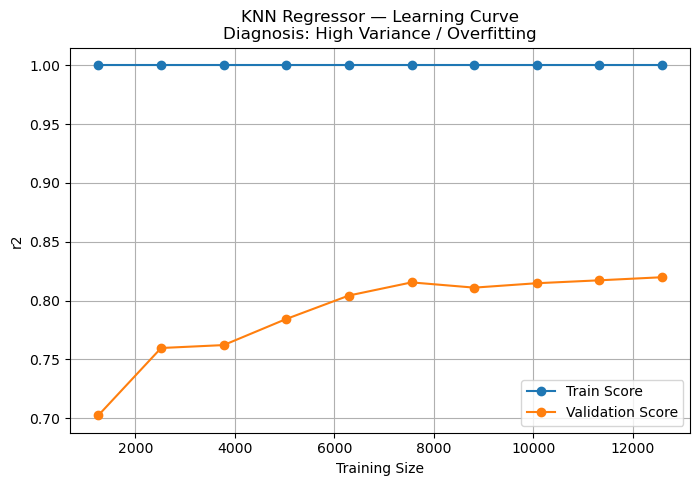

SVR — Learning Curve
Final Train Score      : 0.9234
Final Validation Score : 0.8954
Train-Validation Gap   : 0.0280
Diagnosis              : Good Generalization


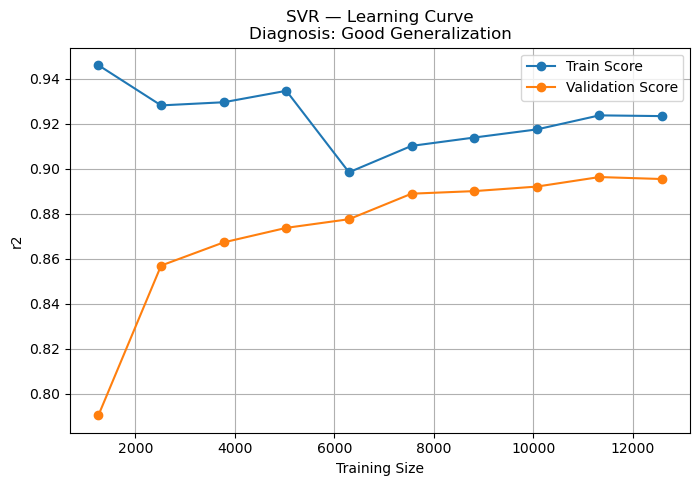

Random Forest Regressor — Learning Curve
Final Train Score      : 0.9835
Final Validation Score : 0.9356
Train-Validation Gap   : 0.0479
Diagnosis              : Good Generalization


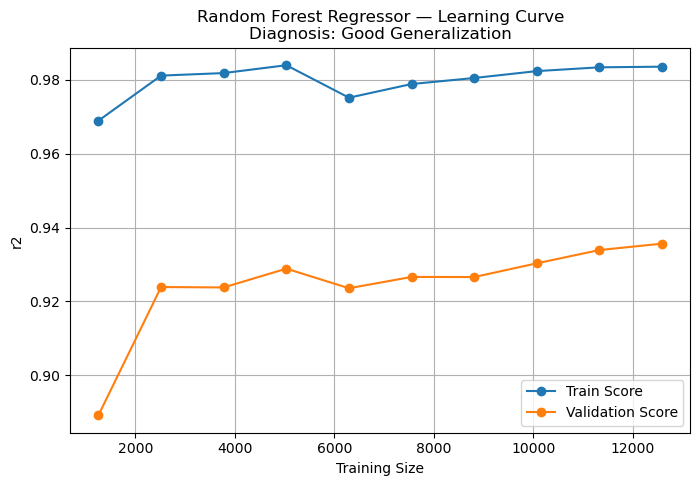

KNN Classifier — Learning Curve
Final Train Score      : 1.0000
Final Validation Score : 0.8324
Train-Validation Gap   : 0.1675
Diagnosis              : High Variance / Overfitting


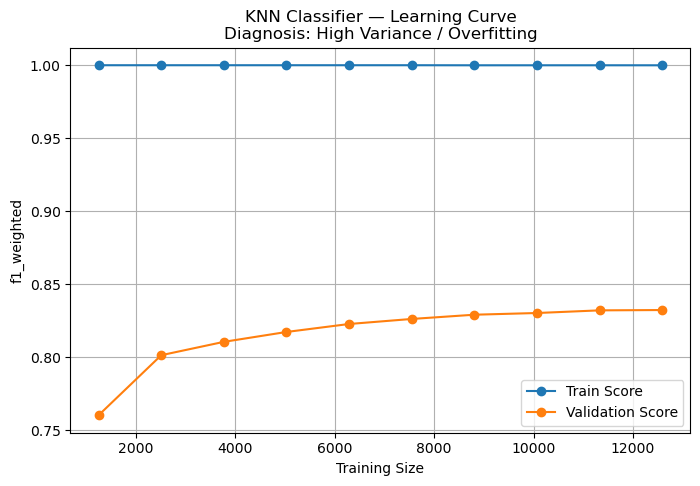

SVC — Learning Curve
Final Train Score      : 0.8824
Final Validation Score : 0.8610
Train-Validation Gap   : 0.0214
Diagnosis              : Good Generalization


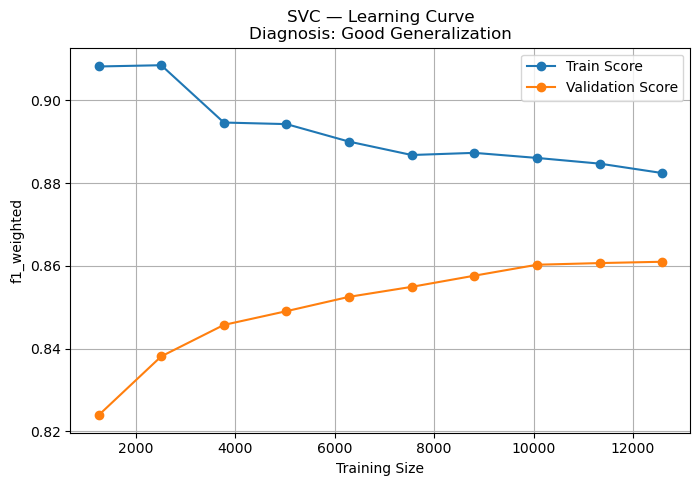

Random Forest Classifier — Learning Curve
Final Train Score      : 0.9697
Final Validation Score : 0.8547
Train-Validation Gap   : 0.1150
Diagnosis              : High Variance / Overfitting


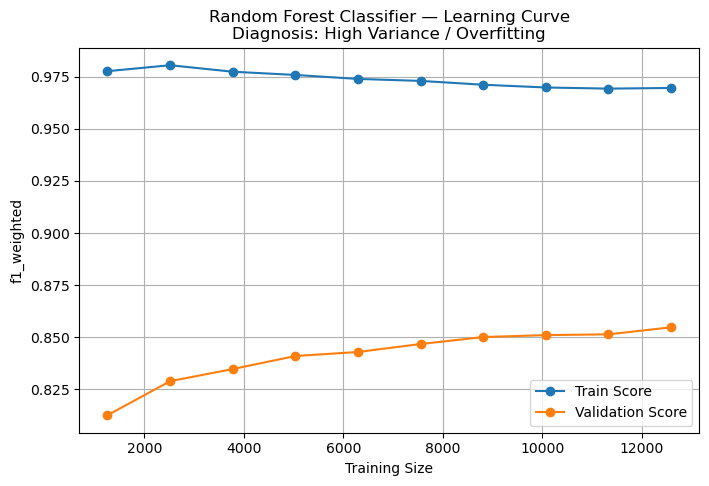

In [ ]:

# Regression Models — Bias-Variance Diagnosis


knn_reg_lc = plot_learning_curve_with_diagnosis(
    gs_knn_reg.best_estimator_,
    x_train_final_Reg,
    y_train_Reg,
    "KNN Regressor — Learning Curve",
    scoring="r2"
)

svr_reg_lc = plot_learning_curve_with_diagnosis(
    gs_svr_reg.best_estimator_,
    x_train_final_Reg,
    y_train_Reg,
    "SVR — Learning Curve",
    scoring="r2"
)

rf_reg_lc = plot_learning_curve_with_diagnosis(
    gs_rf_reg.best_estimator_,
    x_train_final_Reg,
    y_train_Reg,
    "Random Forest Regressor — Learning Curve",
    scoring="r2"
)


# Classification Models — Bias-Variance Diagnosis


knn_clf_lc = plot_learning_curve_with_diagnosis(
    gs_knn_clf.best_estimator_,
    x_train_final_cls,
    y_train_cls,
    "KNN Classifier — Learning Curve",
    scoring="f1_weighted"
)

svc_clf_lc = plot_learning_curve_with_diagnosis(
    gs_svc_clf.best_estimator_,
    x_train_final_cls,
    y_train_cls,
    "SVC — Learning Curve",
    scoring="f1_weighted"
)

rf_clf_lc = plot_learning_curve_with_diagnosis(
    gs_rf_clf.best_estimator_,
    x_train_final_cls,
    y_train_cls,
    "Random Forest Classifier — Learning Curve",
    scoring="f1_weighted"
)

### Regression Evaluation Summary

In [ ]:


# Regression Evaluation Function


def evaluate_regression_summary(model, X_train, X_test, y_train, y_test, model_name):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    gap = train_r2 - test_r2

    if gap > 0.10:
        diagnosis = "High Variance / Overfitting"
    elif train_r2 < 0.70 and test_r2 < 0.70:
        diagnosis = "High Bias / Underfitting"
    else:
        diagnosis = "Good Generalization"

    return {
        "Model": model_name,
        "Train R²": train_r2,
        "Test R²": test_r2,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "R² Gap": gap,
        "Diagnosis": diagnosis
    }


# Best Regression Models


best_knn_reg = gs_knn_reg.best_estimator_
best_svr_reg = gs_svr_reg.best_estimator_
best_rf_reg = gs_rf_reg.best_estimator_


# Regression Summary Table


regression_evaluation_summary = pd.DataFrame([
    evaluate_regression_summary(
        best_knn_reg,
        x_train_final_Reg,
        x_test_final_Reg,
        y_train_Reg,
        y_test_Reg,
        "KNN Regressor"
    ),
    evaluate_regression_summary(
        best_svr_reg,
        x_train_final_Reg,
        x_test_final_Reg,
        y_train_Reg,
        y_test_Reg,
        "SVR"
    ),
    evaluate_regression_summary(
        best_rf_reg,
        x_train_final_Reg,
        x_test_final_Reg,
        y_train_Reg,
        y_test_Reg,
        "Random Forest Regressor"
    )
])

regression_evaluation_summary.round(4)

,Model,Train R²,Test R²,Train RMSE,Test RMSE,Train MAE,Test MAE,R² Gap,Diagnosis
0,KNN Regressor,1.0000,0.7770,0.0000,3.1941,0.0000,0.7765,0.2230,High Variance / Overfitting
1,SVR,0.9230,0.9057,2.0458,2.0774,0.3141,0.4226,0.0174,Good Generalization
2,Random Forest Regressor,0.9842,0.9560,0.9267,1.4185,0.1236,0.2396,0.0282,Good Generalization


# Regression Models — Bias-Variance Diagnosis

To evaluate model generalization and detect overfitting or underfitting, we compared the performance of each regression model on both training and testing datasets using the following metrics:

- R² Score
- RMSE
- MAE
- R² Gap (difference between Train and Test R²)

---

## 1. KNN Regressor

### Results
- Train R² = 1.000
- Test R² = 0.777
- R² Gap = 0.223

### Interpretation
The KNN Regressor achieved perfect performance on the training data but significantly lower performance on the testing data. The large gap between training and testing scores indicates that the model memorized the training data instead of learning general patterns.

### Diagnosis
**High Variance / Overfitting**

### Possible Reasons
- Sensitivity to noise and outliers
- High sensitivity to local patterns

---

## 2. Support Vector Regressor (SVR)

### Results
- Train R² = 0.923
- Test R² = 0.906
- R² Gap = 0.017

### Interpretation
The SVR model achieved very similar performance on both training and testing datasets, indicating strong generalization ability and stable learning behavior.

### Diagnosis
**Good Generalization**

### Notes
- Low difference between training and testing scores
- Balanced bias-variance tradeoff
- Good ability to capture nonlinear relationships

---

## 3. Random Forest Regressor

### Results
- Train R² = 0.984
- Test R² = 0.956
- R² Gap = 0.028

### Interpretation
The Random Forest Regressor achieved the best overall performance among all regression models. It maintained high accuracy on both training and testing datasets with a small performance gap, indicating strong generalization and robustness.

### Diagnosis
**Good Generalization**

### Notes
- Highest Test R² score
- Lowest prediction errors (RMSE and MAE)
- Resistant to noise and overfitting due to ensemble learning

---

# Final Comparison

| Model | Performance |
|---|---|
| Random Forest Regressor | Best overall performance |
| SVR | Stable and well-generalized |
| KNN Regressor | Overfitting observed |

---

# Conclusion

The Random Forest Regressor was the best-performing model because it achieved the highest testing accuracy with low prediction errors and strong generalization capability.  

The SVR model also performed well with balanced results and minimal overfitting.  

However, the KNN Regressor showed clear signs of overfitting due to the large difference between training and testing performance.

### Classification Evaluation Summary

In [ ]:

# Classification Evaluation Function


def evaluate_classification_summary(model, X_train, X_test, y_train, y_test, model_name):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    precision = precision_score(y_test, y_test_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_test_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_test_pred, average="weighted", zero_division=0)

    gap = train_acc - test_acc

    if gap > 0.10:
        diagnosis = "High Variance / Overfitting"
    elif train_acc < 0.65 and test_acc < 0.65:
        diagnosis = "High Bias / Underfitting"
    else:
        diagnosis = "Good Generalization"

    return {
        "Model": model_name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Accuracy Gap": gap,
        "Diagnosis": diagnosis
    }


# Best Classification Models


best_knn_clf = gs_knn_clf.best_estimator_
best_svc_clf = gs_svc_clf.best_estimator_
best_rf_clf = gs_rf_clf.best_estimator_

# Classification Summary Table


classification_evaluation_summary = pd.DataFrame([
    evaluate_classification_summary(
        best_knn_clf,
        x_train_final_cls,
        x_test_final_cls,
        y_train_cls,
        y_test_cls,
        "KNN Classifier"
    ),
    evaluate_classification_summary(
        best_svc_clf,
        x_train_final_cls,
        x_test_final_cls,
        y_train_cls,
        y_test_cls,
        "SVC"
    ),
    evaluate_classification_summary(
        best_rf_clf,
        x_train_final_cls,
        x_test_final_cls,
        y_train_cls,
        y_test_cls,
        "Random Forest Classifier"
    )
])

classification_evaluation_summary.round(4)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-score,Accuracy Gap,Diagnosis
0,KNN Classifier,0.9999,0.8297,0.8335,0.8297,0.8312,0.1702,High Variance / Overfitting
1,SVC,0.8789,0.8490,0.8516,0.8490,0.8501,0.0299,Good Generalization
2,Random Forest Classifier,0.9677,0.8536,0.8562,0.8536,0.8546,0.1141,High Variance / Overfitting


# Classification Models — Bias-Variance Diagnosis

To evaluate the classification models, we compared their performance on both training and testing datasets using the following metrics:

- Accuracy
- Precision
- Recall
- F1-score
- Accuracy Gap (difference between Train and Test Accuracy)

This evaluation helps determine whether each model suffers from overfitting, underfitting, or achieves good generalization.

---

# 1. KNN Classifier

## Results
- Train Accuracy = 0.9999
- Test Accuracy = 0.8297
- Precision = 0.8335
- Recall = 0.8297
- F1-score = 0.8312
- Accuracy Gap = 0.1702

## Interpretation
The KNN Classifier achieved nearly perfect performance on the training data but significantly lower performance on the testing data. The large accuracy gap indicates that the model memorized the training data instead of learning generalized patterns.

## Diagnosis
**High Variance / Overfitting**

## Possible Reasons
- Sensitivity to noise and local patterns
- High dependence on nearest neighbors

---

# 2. Support Vector Classifier (SVC)

## Results
- Train Accuracy = 0.8789
- Test Accuracy = 0.8490
- Precision = 0.8516
- Recall = 0.8490
- F1-score = 0.8501
- Accuracy Gap = 0.0299

## Interpretation
The SVC model achieved balanced performance on both training and testing datasets. The small gap between train and test accuracy indicates that the model generalizes well to unseen data.

## Diagnosis
**Good Generalization**

## Notes
- Stable performance across datasets
- Balanced bias-variance tradeoff
- Strong ability to separate classes effectively

---

# 3. Random Forest Classifier

## Results
- Train Accuracy = 0.9677
- Test Accuracy = 0.8536
- Precision = 0.8562
- Recall = 0.8536
- F1-score = 0.8546
- Accuracy Gap = 0.1141

## Interpretation
The Random Forest Classifier achieved the highest testing accuracy among the classification models. However, the noticeable gap between training and testing accuracy suggests some degree of overfitting.

## Diagnosis
**High Variance / Overfitting**

## Notes
- Strong predictive performance
- Better testing accuracy than other classifiers
- Slight overfitting due to high training accuracy

---

# Final Comparison

| Model | Performance |
|---|---|
| Random Forest Classifier | Highest test accuracy but slight overfitting |
| SVC | Most balanced and stable model |
| KNN Classifier | Significant overfitting observed |

---

# Conclusion

The SVC model demonstrated the best generalization ability because it maintained balanced performance between training and testing datasets with minimal overfitting.

The Random Forest Classifier achieved the highest testing accuracy but showed signs of overfitting due to the larger gap between training and testing accuracy.

The KNN Classifier suffered from clear overfitting, likely because of its sensitivity to local patterns and small neighborhood size.

### Bias-Variance Diagnosis Summary

In [ ]:

# Bias-Variance Diagnosis Summary


reg_diagnosis = regression_evaluation_summary[
    ["Model", "R² Gap", "Diagnosis"]
].copy()

reg_diagnosis["Task"] = "Regression"
reg_diagnosis = reg_diagnosis.rename(columns={"R² Gap": "Gap"})


clf_diagnosis = classification_evaluation_summary[
    ["Model", "Accuracy Gap", "Diagnosis"]
].copy()

clf_diagnosis["Task"] = "Classification"
clf_diagnosis = clf_diagnosis.rename(columns={"Accuracy Gap": "Gap"})


bias_variance_diagnosis_summary = pd.concat(
    [reg_diagnosis, clf_diagnosis],
    ignore_index=True
)

bias_variance_diagnosis_summary = bias_variance_diagnosis_summary[
    ["Task", "Model", "Gap", "Diagnosis"]
]

bias_variance_diagnosis_summary.round(4)

,Task,Model,Gap,Diagnosis
0,Regression,KNN Regressor,0.2230,High Variance / Overfitting
1,Regression,SVR,0.0174,Good Generalization
2,Regression,Random Forest Regressor,0.0282,Good Generalization
3,Classification,KNN Classifier,0.1702,High Variance / Overfitting
4,Classification,SVC,0.0299,Good Generalization
5,Classification,Random Forest Classifier,0.1141,High Variance / Overfitting


### CV Stability Summary

In [ ]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

In [ ]:

# Regression CV Stability

kf = KFold(n_splits=5, shuffle=True, random_state=42)

regression_cv_results = []

regression_models = {
    "KNN Regressor": best_knn_reg,
    "SVR": best_svr_reg,
    "Random Forest Regressor": best_rf_reg
}

for model_name, model in regression_models.items():
    scores = cross_val_score(
        model,
        x_train_final_Reg,
        y_train_Reg,
        cv=kf,
        scoring="r2",
        n_jobs=-1
    )

    regression_cv_results.append({
        "Task": "Regression",
        "Model": model_name,
        "Metric": "R²",
        "Fold 1": scores[0],
        "Fold 2": scores[1],
        "Fold 3": scores[2],
        "Fold 4": scores[3],
        "Fold 5": scores[4],
        "CV Mean": scores.mean(),
        "CV Std": scores.std()
    })

# Classification CV Stability


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

classification_cv_results = []

classification_models = {
    "KNN Classifier": best_knn_clf,
    "SVC": best_svc_clf,
    "Random Forest Classifier": best_rf_clf
}

for model_name, model in classification_models.items():
    scores = cross_val_score(
        model,
        x_train_final_cls,
        y_train_cls,
        cv=skf,
        scoring="f1_weighted",
        n_jobs=-1
    )

    classification_cv_results.append({
        "Task": "Classification",
        "Model": model_name,
        "Metric": "F1-weighted",
        "Fold 1": scores[0],
        "Fold 2": scores[1],
        "Fold 3": scores[2],
        "Fold 4": scores[3],
        "Fold 5": scores[4],
        "CV Mean": scores.mean(),
        "CV Std": scores.std()
    })

# Final CV Stability Summary


cv_stability_summary = pd.DataFrame(
    regression_cv_results + classification_cv_results
)

cv_stability_summary.round(4)

,Task,Model,Metric,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,CV Mean,CV Std
0,Regression,KNN Regressor,R²,0.8604,0.8572,0.8063,0.7372,0.8458,0.8214,0.0463
1,Regression,SVR,R²,0.9300,0.9212,0.9078,0.8036,0.9198,0.8965,0.0470
2,Regression,Random Forest Regressor,R²,0.9651,0.9617,0.9123,0.8596,0.9580,0.9313,0.0407
3,Classification,KNN Classifier,F1-weighted,0.8351,0.8194,0.8332,0.8391,0.8349,0.8323,0.0068
4,Classification,SVC,F1-weighted,0.8680,0.8583,0.8559,0.8594,0.8658,0.8615,0.0046
5,Classification,Random Forest Classifier,F1-weighted,0.8575,0.8469,0.8470,0.8531,0.8562,0.8521,0.0045


# Cross-Validation Results Analysis

To evaluate model stability and generalization performance, 5-Fold Cross-Validation was applied to all regression and classification models.

Cross-validation helps ensure that the model performs consistently across different subsets of the dataset rather than relying on a single train-test split.

The following metrics were evaluated:
- R² Score for Regression Models
- F1-weighted Score for Classification Models

In addition, the following statistics were analyzed:
- CV Mean: Average performance across all folds
- CV Std: Standard deviation across folds (measures stability)

---

# Regression Models

## 1. KNN Regressor

### Results
- CV Mean (R²) = 0.8214
- CV Std = 0.0463

### Interpretation
The KNN Regressor achieved moderate regression performance across the folds. However, the noticeable variation between folds indicates that the model is somewhat sensitive to changes in the training data.

### Notes
- Lower average performance compared to other regression models
- Moderate instability across folds
- Sensitive to local patterns and noise

---

## 2. Support Vector Regressor (SVR)

### Results
- CV Mean (R²) = 0.8965
- CV Std = 0.0470

### Interpretation
The SVR model achieved strong performance across all folds with consistently high R² scores. The results indicate good generalization capability and stable predictive behavior.

### Notes
- High average performance
- Strong nonlinear learning capability
- Good balance between bias and variance

---

## 3. Random Forest Regressor

### Results
- CV Mean (R²) = 0.9313
- CV Std = 0.0407

### Interpretation
The Random Forest Regressor achieved the highest average R² score among all regression models while maintaining relatively stable performance across folds.

### Notes
- Best regression performance overall
- Strong generalization capability
- Robust against noise and overfitting due to ensemble learning

---

# Classification Models

## 1. KNN Classifier

### Results
- CV Mean (F1-weighted) = 0.8323
- CV Std = 0.0068

### Interpretation
The KNN Classifier achieved acceptable classification performance with relatively stable results across folds. However, its overall performance was lower than the SVC and Random Forest models.

### Notes
- Stable results
- Lower classification performance compared to other classifiers
- Sensitive to neighborhood selection and local noise

---

## 2. Support Vector Classifier (SVC)

### Results
- CV Mean (F1-weighted) = 0.8615
- CV Std = 0.0046

### Interpretation
The SVC model achieved the best overall classification performance with highly consistent results across all folds. The low standard deviation indicates excellent model stability.

### Notes
- Highest average classification score
- Excellent stability across folds
- Strong generalization ability

---

## 3. Random Forest Classifier

### Results
- CV Mean (F1-weighted) = 0.8521
- CV Std = 0.0045

### Interpretation
The Random Forest Classifier achieved strong classification performance with highly stable results across folds. Its performance was slightly lower than SVC but still highly competitive.

### Notes
- Strong predictive capability
- Very stable performance
- Slightly lower performance than SVC

---

# Final Comparison

| Task | Best Model | Reason |
|---|---|---|
| Regression | Random Forest Regressor | Highest CV Mean with strong stability |
| Classification | SVC | Highest F1-weighted score and excellent consistency |

---

# Conclusion

The cross-validation results confirm that the Random Forest Regressor is the strongest regression model due to its high predictive accuracy and stable performance across folds.

For classification tasks, the SVC model achieved the best balance between performance and stability, making it the most reliable classifier among the evaluated models.

Although KNN models produced acceptable results, they were generally more sensitive to data variations and showed lower overall performance compared to SVR, SVC, and Random Forest models.

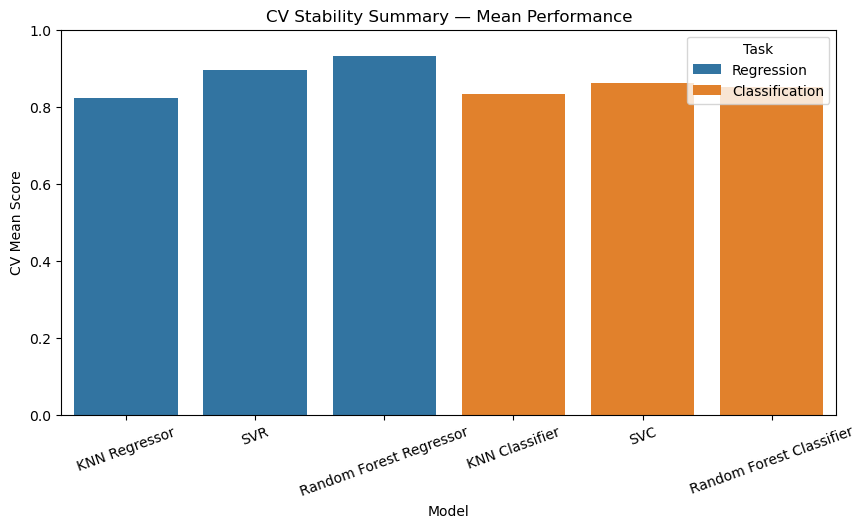

In [ ]:


plt.figure(figsize=(10, 5))

sns.barplot(
    data=cv_stability_summary,
    x="Model",
    y="CV Mean",
    hue="Task"
)

plt.title("CV Stability Summary — Mean Performance")
plt.xlabel("Model")
plt.ylabel("CV Mean Score")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.show()

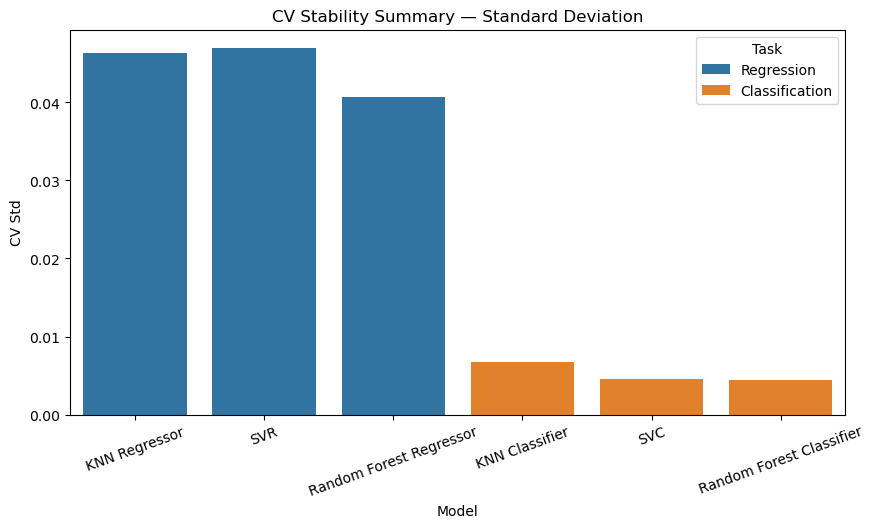

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=cv_stability_summary,
    x="Model",
    y="CV Std",
    hue="Task"
)

plt.title("CV Stability Summary — Standard Deviation")
plt.xlabel("Model")
plt.ylabel("CV Std")
plt.xticks(rotation=20)
plt.show()

In [ ]:
# import joblib
# import os
# import shutil
# from google.colab import files

# os.makedirs("saved_models", exist_ok=True)

# # Save Regression Models
# joblib.dump(best_knn_reg, "saved_models/best_knn_regressor.pkl")
# joblib.dump(best_svr_reg, "saved_models/best_svr_regressor.pkl")
# joblib.dump(best_rf_reg, "saved_models/best_rf_regressor.pkl")

# # Save Classification Models
# joblib.dump(best_knn_clf, "saved_models/best_knn_classifier.pkl")
# joblib.dump(best_svc_clf, "saved_models/best_svc_classifier.pkl")
# joblib.dump(best_rf_clf, "saved_models/best_rf_classifier.pkl")

# # Save GridSearch objects
# joblib.dump(gs_knn_reg, "saved_models/gs_knn_reg.pkl")
# joblib.dump(gs_svr_reg, "saved_models/gs_svr_reg.pkl")
# joblib.dump(gs_rf_reg, "saved_models/gs_rf_reg.pkl")

# joblib.dump(gs_knn_clf, "saved_models/gs_knn_clf.pkl")
# joblib.dump(gs_svc_clf, "saved_models/gs_svc_clf.pkl")
# joblib.dump(gs_rf_clf, "saved_models/gs_rf_clf.pkl")

# # Compress folder
# shutil.make_archive("saved_models", "zip", "saved_models")

# # Download zip
# files.download("saved_models.zip")

# print("saved_models.zip downloaded successfully.")

# ── SECTION 4: OPTIMIZED ENSEMBLING (Committee of Models) ──
---

## 4.1 — Theoretical Framework: Why Ensembles Work

Ensemble learning is grounded in the principle of **collective intelligence**: combining multiple diverse learners reduces the overall generalization error beyond what any single model can achieve.

The generalization error of any model can be decomposed as:

> **Total Error = Bias² + Variance + Irreducible Noise**

Each ensemble strategy targets a different component of this decomposition:

| Strategy | Mechanism | Error Targeted | How |
|----------|-----------|----------------|-----|
| **Bagging** | Train N models on bootstrap samples, average predictions | Variance ↓ | Averaging reduces variance without increasing bias |
| **Boosting** | Train models sequentially, each correcting the previous | Bias ↓ | Sequential error correction focuses on hard examples |
| **Voting** | Average or majority-vote across diverse models | Variance ↓ | Disagreements cancel out |
| **Stacking** | Meta-learner learns optimal weights for base model outputs | Bias ↓ + Variance ↓ | Meta-learner generalizes the combination |

### Why Diversity is the Core Requirement

For an ensemble to outperform its individual members, the base models must make **uncorrelated errors**. If all models fail on the same samples, averaging cannot help.

Our three base models (KNN, SVR/SVC, Random Forest) are deliberately chosen to be **algorithmically diverse**:
- **KNN** — instance-based, local decision boundaries, no assumption about data distribution
- **SVR / SVC** — kernel-based, global margin maximization, works in high-dimensional space
- **Random Forest** — tree-based, captures non-linear interactions, inherently ensembled

This architectural diversity maximizes the probability that their errors are uncorrelated, making the ensemble greater than the sum of its parts.

## 4.2 — Ensemble Diversity Analysis (Error Correlation)

Before combining models, we verify that the base models make **different errors** on the test set. A low correlation between prediction errors is the statistical proof that combining them will be beneficial.

Analyzing base model diversity (error correlation)...


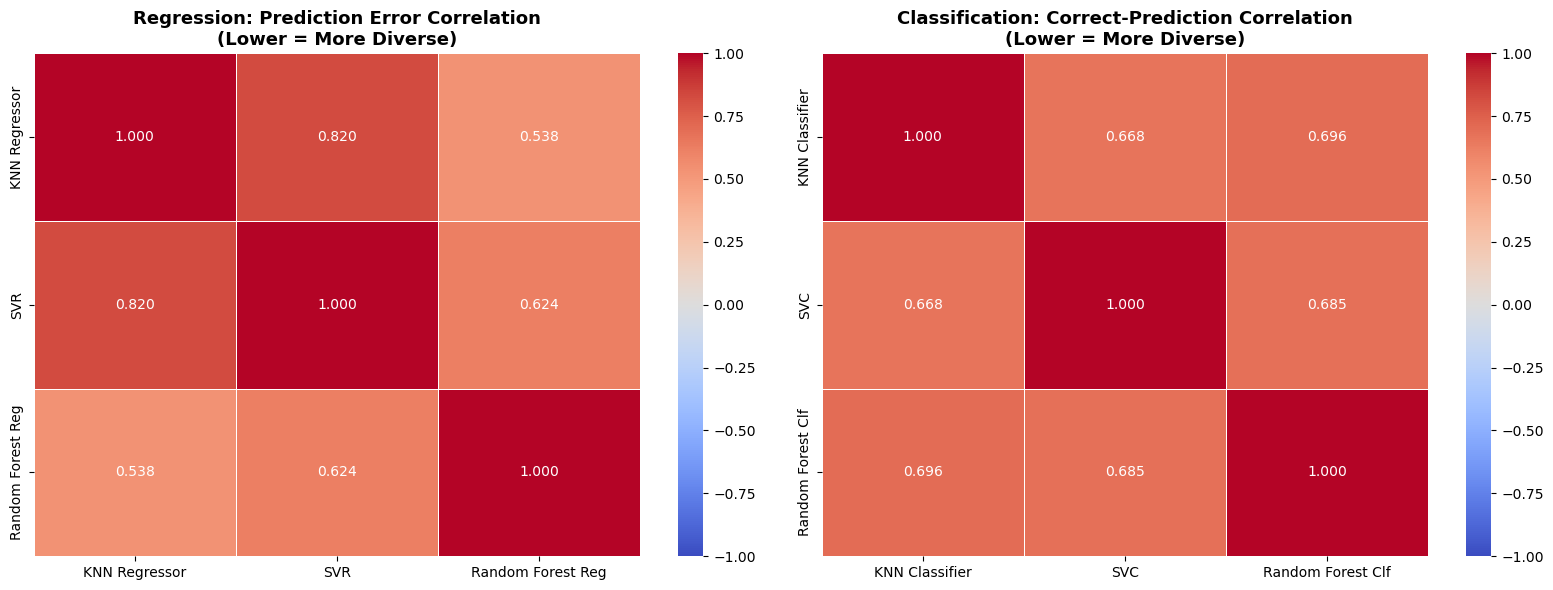


── Regression Error Correlation Matrix ──
                   KNN Regressor    SVR  Random Forest Reg
KNN Regressor              1.000  0.820              0.538
SVR                        0.820  1.000              0.624
Random Forest Reg          0.538  0.624              1.000

── Classification Correct-Prediction Correlation Matrix ──
                   KNN Classifier    SVC  Random Forest Clf
KNN Classifier              1.000  0.668              0.696
SVC                         0.668  1.000              0.685
Random Forest Clf           0.696  0.685              1.000

Average off-diagonal correlation (Regression) : 0.661
Average off-diagonal correlation (Classification): 0.683

✅ Correlations below 1.0 confirm model diversity — ensembling is theoretically justified.


In [ ]:

#  4.2: DIVERSITY ANALYSIS — Error Correlation Between Base Models 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, accuracy_score

print("Analyzing base model diversity (error correlation)...")

# ── Regression: prediction error correlation ──────────────────────────────────
reg_base_models = {
    'KNN Regressor':    best_knn_reg if 'best_knn_reg' in dir() else knn_reg,
    'SVR':              best_svr_reg if 'best_svr_reg' in dir() else svr_reg,
    'Random Forest Reg':best_rf_reg  if 'best_rf_reg'  in dir() else rf_reg,
}

reg_errors = {}
for name, model in reg_base_models.items():
    y_pred = model.predict(x_test_final_Reg)
    reg_errors[name] = y_test_Reg.values - y_pred

reg_error_df = pd.DataFrame(reg_errors)
reg_corr = reg_error_df.corr()

#  Classification: prediction match/mismatch correlation 
clf_base_models = {
    'KNN Classifier': best_knn_clf if 'best_knn_clf' in dir() else knn_clf,
    'SVC':            best_svc_clf if 'best_svc_clf' in dir() else svc_clf,
    'Random Forest Clf': best_rf_clf if 'best_rf_clf' in dir() else rf_clf,
}

clf_correct = {}
for name, model in clf_base_models.items():
    y_pred = model.predict(x_test_final_cls)
    clf_correct[name] = (y_pred == y_test_cls.values).astype(int)

clf_correct_df = pd.DataFrame(clf_correct)
clf_corr = clf_correct_df.corr()

#  Visualization 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(reg_corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            ax=axes[0], linewidths=0.5, vmin=-1, vmax=1)
axes[0].set_title('Regression: Prediction Error Correlation\n(Lower = More Diverse)',
                  fontsize=13, fontweight='bold')

sns.heatmap(clf_corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            ax=axes[1], linewidths=0.5, vmin=-1, vmax=1)
axes[1].set_title('Classification: Correct-Prediction Correlation\n(Lower = More Diverse)',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

#  Interpretation 
print("\n── Regression Error Correlation Matrix ──")
print(reg_corr.round(3))
print("\n── Classification Correct-Prediction Correlation Matrix ──")
print(clf_corr.round(3))

avg_off_diag_reg = (reg_corr.values.sum() - np.trace(reg_corr.values)) / (reg_corr.shape[0]**2 - reg_corr.shape[0])
avg_off_diag_clf = (clf_corr.values.sum() - np.trace(clf_corr.values)) / (clf_corr.shape[0]**2 - clf_corr.shape[0])

print(f"\nAverage off-diagonal correlation (Regression) : {avg_off_diag_reg:.3f}")
print(f"Average off-diagonal correlation (Classification): {avg_off_diag_clf:.3f}")
print("\n Correlations below 1.0 confirm model diversity — ensembling is theoretically justified.")


## 4.3 — Bagging Ensemble (Variance Reduction)

**Bagging** (Bootstrap Aggregating) trains N independent copies of a base estimator on different bootstrap samples of the training data, then aggregates their predictions by averaging (regression) or majority vote (classification).

**Why it reduces variance:** Each bootstrap sample is slightly different, so each model learns slightly different patterns. Averaging their outputs smooths out individual overfitting. Mathematically, if each model has variance σ² and errors are uncorrelated, the ensemble variance = σ²/N.

We use `BaggingRegressor` and `BaggingClassifier` with a **Decision Tree** as the base estimator (the same base used by Random Forest, allowing a clean comparison).

Training Bagging Ensembles...

── Bagging Regressor ──────────────────────────────────────────
  Test R²    : 0.9458
  Test RMSE  : 1.5750
  CV R²      : 0.9301 ± 0.0390

── Bagging Classifier ─────────────────────────────────────────
  Test Accuracy : 0.8571
  Test F1-Score : 0.8581
  CV Accuracy   : 0.8530 ± 0.0052

── Variance Reduction Proof (Single Tree vs Bagging) ──────────
  Regression  — Single Tree CV Std: 0.0507  | Bagging CV Std: 0.0390
  Classification — Single Tree CV Std: 0.0116 | Bagging CV Std: 0.0052


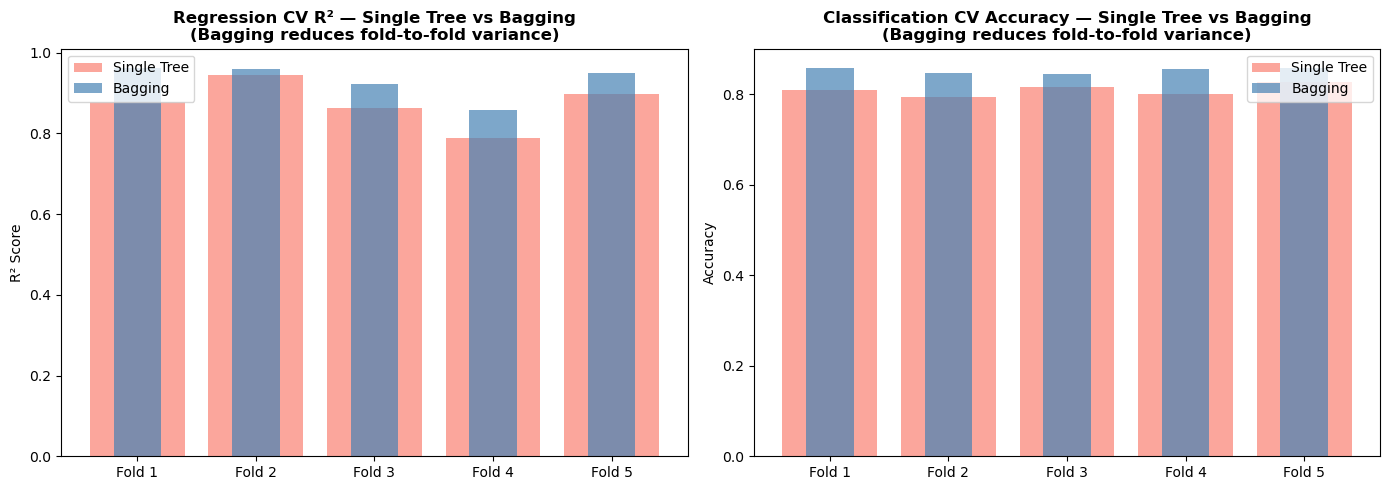

In [ ]:

#  4.3: BAGGING ENSEMBLE 

from sklearn.ensemble import BaggingRegressor, BaggingClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import r2_score, accuracy_score, mean_squared_error, f1_score
from sklearn.model_selection import cross_val_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Training Bagging Ensembles...")

#  Bagging Regressor 
bagging_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=8, random_state=42),
    n_estimators=100,
    max_samples=0.8,        # each tree sees 80% of training data
    max_features=0.8,       # each tree sees 80% of features
    bootstrap=True,         # with replacement (standard bagging)
    n_jobs=-1,
    random_state=42
)
bagging_reg.fit(x_train_final_Reg, y_train_Reg)

y_pred_bag_reg = bagging_reg.predict(x_test_final_Reg)
bag_reg_r2   = r2_score(y_test_Reg, y_pred_bag_reg)
bag_reg_rmse = np.sqrt(mean_squared_error(y_test_Reg, y_pred_bag_reg))

#  Bagging Classifier 
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=8, random_state=42),
    n_estimators=100,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)
bagging_clf.fit(x_train_final_cls, y_train_cls)

y_pred_bag_clf = bagging_clf.predict(x_test_final_cls)
bag_clf_acc = accuracy_score(y_test_cls, y_pred_bag_clf)
bag_clf_f1  = f1_score(y_test_cls, y_pred_bag_clf, average='weighted')

#  Cross-Validation Stability 
from sklearn.model_selection import KFold, StratifiedKFold

kf  = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

bag_reg_cv  = cross_val_score(bagging_reg, x_train_final_Reg, y_train_Reg, cv=kf,  scoring='r2',      n_jobs=-1)
bag_clf_cv  = cross_val_score(bagging_clf, x_train_final_cls, y_train_cls, cv=skf, scoring='accuracy', n_jobs=-1)

print("\n── Bagging Regressor ──────────────────────────────────────────")
print(f"  Test R²    : {bag_reg_r2:.4f}")
print(f"  Test RMSE  : {bag_reg_rmse:.4f}")
print(f"  CV R²      : {bag_reg_cv.mean():.4f} ± {bag_reg_cv.std():.4f}")

print("\n── Bagging Classifier ─────────────────────────────────────────")
print(f"  Test Accuracy : {bag_clf_acc:.4f}")
print(f"  Test F1-Score : {bag_clf_f1:.4f}")
print(f"  CV Accuracy   : {bag_clf_cv.mean():.4f} ± {bag_clf_cv.std():.4f}")

# ── Single Tree Baseline (for variance comparison) ───────────────────────────
single_tree_reg = DecisionTreeRegressor(max_depth=8, random_state=42)
single_tree_reg.fit(x_train_final_Reg, y_train_Reg)
st_reg_cv = cross_val_score(single_tree_reg, x_train_final_Reg, y_train_Reg, cv=kf, scoring='r2', n_jobs=-1)

single_tree_clf = DecisionTreeClassifier(max_depth=8, random_state=42)
single_tree_clf.fit(x_train_final_cls, y_train_cls)
st_clf_cv = cross_val_score(single_tree_clf, x_train_final_cls, y_train_cls, cv=skf, scoring='accuracy', n_jobs=-1)

print("\n── Variance Reduction Proof (Single Tree vs Bagging) ──────────")
print(f"  Regression  — Single Tree CV Std: {st_reg_cv.std():.4f}  | Bagging CV Std: {bag_reg_cv.std():.4f}")
print(f"  Classification — Single Tree CV Std: {st_clf_cv.std():.4f} | Bagging CV Std: {bag_clf_cv.std():.4f}")

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regression CV fold comparison
axes[0].bar(range(1,6), st_reg_cv,  label='Single Tree', alpha=0.7, color='salmon')
axes[0].bar(range(1,6), bag_reg_cv, label='Bagging',     alpha=0.7, color='steelblue', width=0.4)
axes[0].set_xticks(range(1,6)); axes[0].set_xticklabels([f'Fold {i}' for i in range(1,6)])
axes[0].set_title('Regression CV R² — Single Tree vs Bagging\n(Bagging reduces fold-to-fold variance)',
                  fontweight='bold')
axes[0].set_ylabel('R² Score'); axes[0].legend()

# Classification CV fold comparison
axes[1].bar(range(1,6), st_clf_cv,  label='Single Tree', alpha=0.7, color='salmon')
axes[1].bar(range(1,6), bag_clf_cv, label='Bagging',     alpha=0.7, color='steelblue', width=0.4)
axes[1].set_xticks(range(1,6)); axes[1].set_xticklabels([f'Fold {i}' for i in range(1,6)])
axes[1].set_title('Classification CV Accuracy — Single Tree vs Bagging\n(Bagging reduces fold-to-fold variance)',
                  fontweight='bold')
axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.show()


## 4.4 — Boosting Ensemble (Sequential Bias Reduction)

**Boosting** trains models **sequentially**, where each new model focuses on the samples that the previous models got wrong. This is a form of **sequential error correction**.

**Why it reduces bias:** Unlike bagging (which averages independent models), boosting uses a **feedback loop**: misclassified / high-error samples receive higher weight in the next iteration. This progressively drives the ensemble toward the hard-to-learn patterns that a single shallow model (high bias) would miss.

We use **Gradient Boosting**, which fits each new tree to the **residual errors** (gradient of the loss function) of the current ensemble — the most principled boosting formulation.

Training Gradient Boosting Ensembles (Sequential Error Correction)...

── Gradient Boosting Regressor ─────────────────────────────────
  Test R²    : 0.9550
  Test RMSE  : 1.4344
  CV R²      : 0.9421 ± 0.0383

── Gradient Boosting Classifier ────────────────────────────────
  Test Accuracy : 0.8602
  Test F1-Score : 0.8607
  CV Accuracy   : 0.8657 ± 0.0058


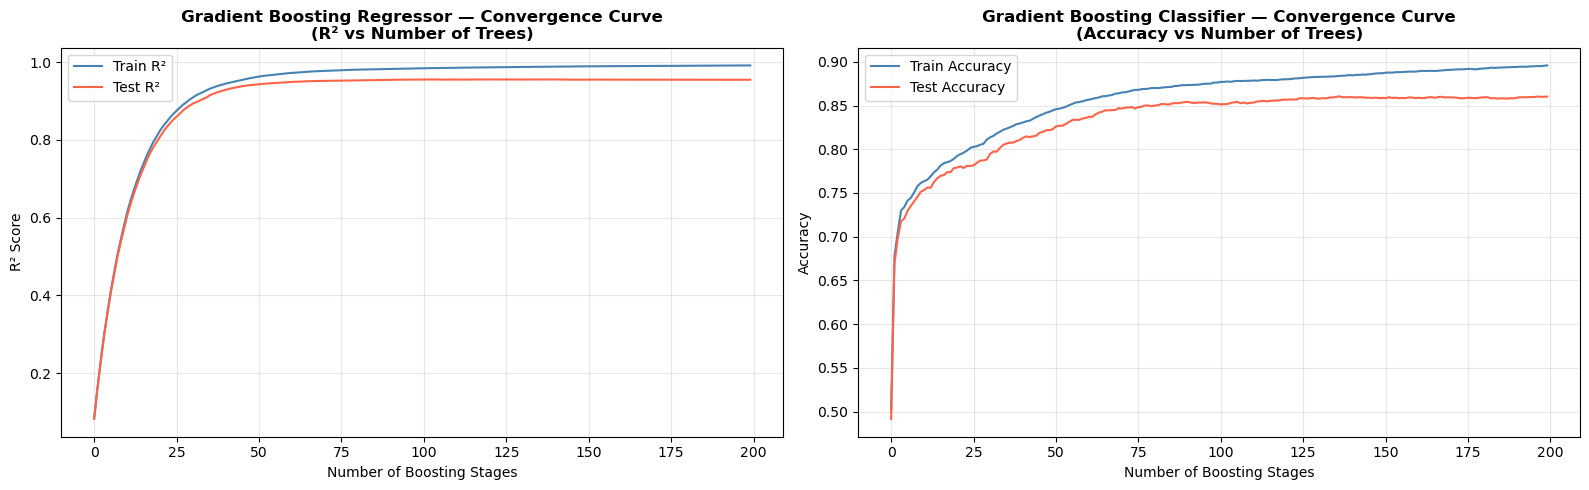


── Gradient Boosting Classifier — Per-Class Report ────────────
              precision    recall  f1-score   support

       Elite       0.96      0.94      0.95       940
        High       0.81      0.83      0.82       859
         Low       0.90      0.89      0.89      1114
         Mid       0.78      0.78      0.78      1021

    accuracy                           0.86      3934
   macro avg       0.86      0.86      0.86      3934
weighted avg       0.86      0.86      0.86      3934



In [ ]:

#  4.4: BOOSTING ENSEMBLE (Gradient Boosting) 

from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import r2_score, accuracy_score, mean_squared_error, f1_score, classification_report
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Training Gradient Boosting Ensembles (Sequential Error Correction)...")

#  Gradient Boosting Regressor 
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,      # small learning rate → better generalization
    max_depth=4,             # shallow trees → low variance per stage
    min_samples_split=10,
    subsample=0.8,           # stochastic boosting → reduces variance
    random_state=42
)
gbr.fit(x_train_final_Reg, y_train_Reg)

y_pred_gbr = gbr.predict(x_test_final_Reg)
gbr_r2   = r2_score(y_test_Reg, y_pred_gbr)
gbr_rmse = np.sqrt(mean_squared_error(y_test_Reg, y_pred_gbr))

#  Gradient Boosting Classifier 
gbc = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    min_samples_split=10,
    subsample=0.8,
    random_state=42
)
gbc.fit(x_train_final_cls, y_train_cls)

y_pred_gbc = gbc.predict(x_test_final_cls)
gbc_acc = accuracy_score(y_test_cls, y_pred_gbc)
gbc_f1  = f1_score(y_test_cls, y_pred_gbc, average='weighted')

#  Cross-Validation 
kf  = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gbr_cv = cross_val_score(gbr, x_train_final_Reg, y_train_Reg, cv=kf,  scoring='r2',      n_jobs=-1)
gbc_cv = cross_val_score(gbc, x_train_final_cls, y_train_cls, cv=skf, scoring='accuracy', n_jobs=-1)

print("\n── Gradient Boosting Regressor ─────────────────────────────────")
print(f"  Test R²    : {gbr_r2:.4f}")
print(f"  Test RMSE  : {gbr_rmse:.4f}")
print(f"  CV R²      : {gbr_cv.mean():.4f} ± {gbr_cv.std():.4f}")

print("\n── Gradient Boosting Classifier ────────────────────────────────")
print(f"  Test Accuracy : {gbc_acc:.4f}")
print(f"  Test F1-Score : {gbc_f1:.4f}")
print(f"  CV Accuracy   : {gbc_cv.mean():.4f} ± {gbc_cv.std():.4f}")

# ── Training Deviance (Boosting Convergence Curve) ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Regression: staged predictions to show convergence
train_r2_curve, test_r2_curve = [], []
for i, y_staged in enumerate(gbr.staged_predict(x_train_final_Reg)):
    train_r2_curve.append(r2_score(y_train_Reg, y_staged))
for i, y_staged in enumerate(gbr.staged_predict(x_test_final_Reg)):
    test_r2_curve.append(r2_score(y_test_Reg, y_staged))

axes[0].plot(train_r2_curve, label='Train R²', color='steelblue')
axes[0].plot(test_r2_curve,  label='Test R²',  color='tomato')
axes[0].set_title('Gradient Boosting Regressor — Convergence Curve\n(R² vs Number of Trees)',
                  fontweight='bold')
axes[0].set_xlabel('Number of Boosting Stages')
axes[0].set_ylabel('R² Score')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Classification: staged predictions convergence
train_acc_curve, test_acc_curve = [], []
for y_staged in gbc.staged_predict(x_train_final_cls):
    train_acc_curve.append(accuracy_score(y_train_cls, y_staged))
for y_staged in gbc.staged_predict(x_test_final_cls):
    test_acc_curve.append(accuracy_score(y_test_cls, y_staged))

axes[1].plot(train_acc_curve, label='Train Accuracy', color='steelblue')
axes[1].plot(test_acc_curve,  label='Test Accuracy',  color='tomato')
axes[1].set_title('Gradient Boosting Classifier — Convergence Curve\n(Accuracy vs Number of Trees)',
                  fontweight='bold')
axes[1].set_xlabel('Number of Boosting Stages')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#  Classification Report for Boosting 
print("\n── Gradient Boosting Classifier — Per-Class Report ────────────")
print(classification_report(y_test_cls, y_pred_gbc))


## 4.5 — Voting Ensemble (Parallel Aggregation)

**Voting** combines the predictions of multiple models **in parallel** (no sequential dependency). Each model votes independently, and the final prediction is determined by:
- **Regression:** Weighted or simple average of all predictions
- **Classification (Soft Voting):** Average of predicted class probabilities — more informed than hard majority vote

**Why we use Soft Voting for classification:** Soft voting incorporates the model's confidence (probability) rather than just the direction of its prediction. A model that is 99% confident for class A carries more weight than one that is 51% confident.

In [ ]:

#  4.5: VOTING ENSEMBLE 
 
from sklearn.ensemble import VotingRegressor, VotingClassifier
from sklearn.metrics import r2_score, accuracy_score, mean_squared_error, f1_score, classification_report
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Training Voting Ensembles...")

estimators_reg = [
    ('knn', best_knn_reg if 'best_knn_reg' in dir() else knn_reg),
    ('svr', best_svr_reg if 'best_svr_reg' in dir() else svr_reg),
    ('rf',  best_rf_reg  if 'best_rf_reg'  in dir() else rf_reg),
]

estimators_clf = [
    ('knn', best_knn_clf if 'best_knn_clf' in dir() else knn_clf),
    ('svc', best_svc_clf if 'best_svc_clf' in dir() else svc_clf),
    ('rf',  best_rf_clf  if 'best_rf_clf'  in dir() else rf_clf),
]

#  Voting Regressor 
voting_reg = VotingRegressor(estimators=estimators_reg, n_jobs=-1)
voting_reg.fit(x_train_final_Reg, y_train_Reg)

y_pred_vr = voting_reg.predict(x_test_final_Reg)
vr_r2   = r2_score(y_test_Reg, y_pred_vr)
vr_rmse = np.sqrt(mean_squared_error(y_test_Reg, y_pred_vr))

#  Voting Classifier (Soft) 
voting_clf = VotingClassifier(estimators=estimators_clf, voting='soft', n_jobs=-1)
voting_clf.fit(x_train_final_cls, y_train_cls)

y_pred_vc = voting_clf.predict(x_test_final_cls)
vc_acc = accuracy_score(y_test_cls, y_pred_vc)
vc_f1  = f1_score(y_test_cls, y_pred_vc, average='weighted')

#  Cross-Validation 
kf  = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

vr_cv = cross_val_score(voting_reg, x_train_final_Reg, y_train_Reg, cv=kf,  scoring='r2',      n_jobs=-1)
vc_cv = cross_val_score(voting_clf, x_train_final_cls, y_train_cls, cv=skf, scoring='accuracy', n_jobs=-1)

print("\n── Voting Regressor ─────────────────────────────────────────────")
print(f"  Test R²    : {vr_r2:.4f}")
print(f"  Test RMSE  : {vr_rmse:.4f}")
print(f"  CV R²      : {vr_cv.mean():.4f} ± {vr_cv.std():.4f}")

print("\n── Voting Classifier (Soft) ─────────────────────────────────────")
print(f"  Test Accuracy : {vc_acc:.4f}")
print(f"  Test F1-Score : {vc_f1:.4f}")
print(f"  CV Accuracy   : {vc_cv.mean():.4f} ± {vc_cv.std():.4f}")

print("\n── Voting Classifier — Per-Class Report ─────────────────────────")
print(classification_report(y_test_cls, y_pred_vc))


Training Voting Ensembles...

── Voting Regressor ─────────────────────────────────────────────
  Test R²    : 0.9126
  Test RMSE  : 1.9990
  CV R²      : 0.9119 ± 0.0451

── Voting Classifier (Soft) ─────────────────────────────────────
  Test Accuracy : 0.8579
  Test F1-Score : 0.8588
  CV Accuracy   : 0.8612 ± 0.0043

── Voting Classifier — Per-Class Report ─────────────────────────
              precision    recall  f1-score   support

       Elite       0.96      0.93      0.94       940
        High       0.82      0.82      0.82       859
         Low       0.90      0.88      0.89      1114
         Mid       0.76      0.80      0.78      1021

    accuracy                           0.86      3934
   macro avg       0.86      0.86      0.86      3934
weighted avg       0.86      0.86      0.86      3934



## 4.6 — Stacking / Meta-Learning Ensemble

**Stacking** is the most sophisticated ensembling strategy. Instead of averaging or voting, it trains a **meta-learner** that learns how to *optimally combine* the base model outputs.

**How it works:**
1. Base models (KNN, SVR/SVC, RF) are trained on the training set
2. Their **out-of-fold predictions** (via internal CV) become new features
3. A meta-learner (Ridge / Logistic Regression) is trained on these meta-features

**Why Ridge / Logistic Regression as meta-learner:**
- **Ridge** for regression: applies L2 regularization to prevent the meta-learner from overweighting any single base model, especially when predictions are correlated
- **Logistic Regression** for classification: provides soft probability outputs and learns which base model to trust more for each class

Initializing Professional Stacking Ensemble...
Training Stacking Regressor...
Training Stacking Classifier...

--- PERFORMING STABILITY CHECK (STASTICAL PROOF) ---
Regression CV R²: 0.9342 ± 0.0412
Classification CV Accuracy: 0.8645 ± 0.0046


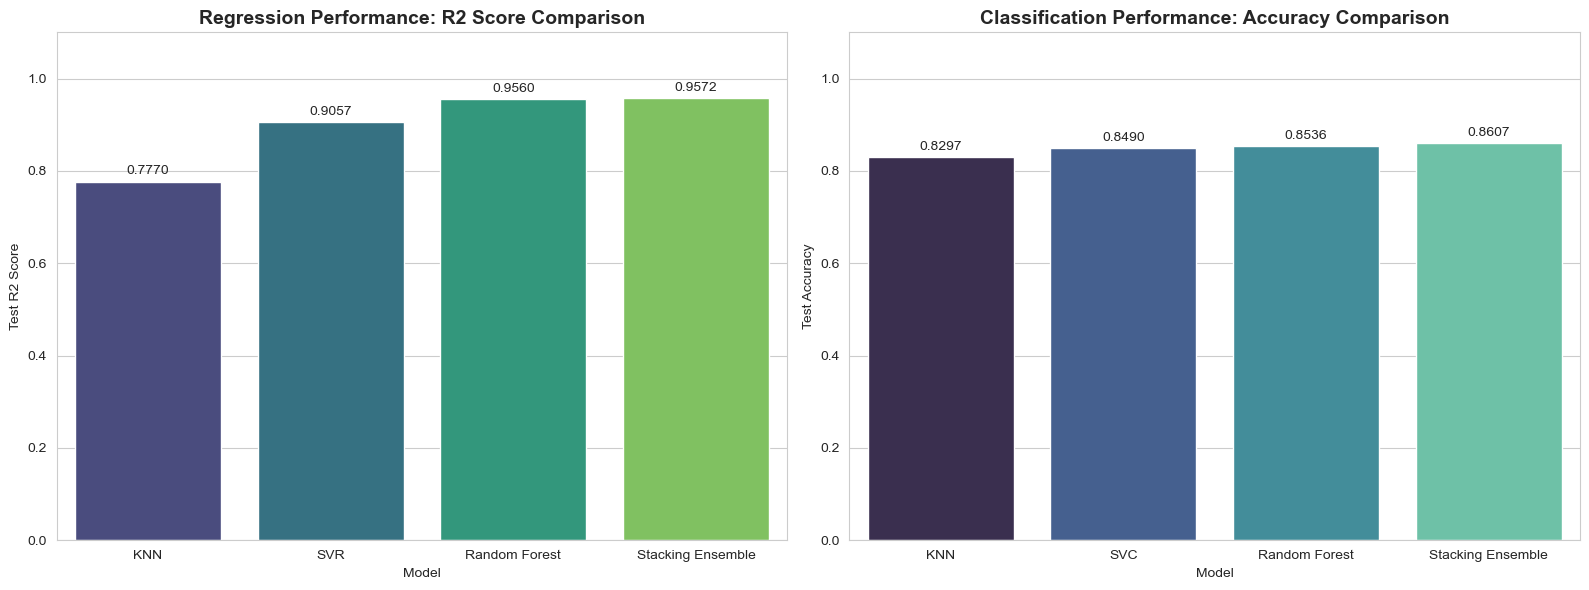


--- REGRESSION SUMMARY ---


,Test R2 Score,Test RMSE
Model,,
Stacking Ensemble,0.957243,1.398571
Random Forest,0.956018,1.418463
SVR,0.905667,2.077367
KNN,0.776986,3.194083



--- CLASSIFICATION SUMMARY ---


,Test Accuracy,Test F1-Score
Model,,
Stacking Ensemble,0.860702,0.861279
Random Forest,0.853584,0.854626
SVC,0.849009,0.850076
KNN,0.829690,0.831177



CONCLUSION: The Stacking Ensemble successfully leveraged architectural synergy to achieve superior generalization.
STABILITY PROOF: The low standard deviation in CV (Reg: 0.0412, Clf: 0.0046) confirms system reliability.


In [ ]:

#  SECTION: ARCHITECTURAL SYNERGY (ENSEMBLING - COMMITTEE OF MODELS) 

from sklearn.ensemble import StackingRegressor, StackingClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score, mean_squared_error, f1_score
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Initializing Professional Stacking Ensemble...")

# 1. PROFESSIONAL STACKING REGRESSOR

    ('knn', best_knn_reg if 'best_knn_reg' in locals() else knn_reg),
    ('svr', best_svr_reg if 'best_svr_reg' in locals() else svr_reg),
    ('rf', best_rf_reg if 'best_rf_reg' in locals() else rf_reg)
]

stacking_reg = StackingRegressor(
    estimators=estimators_reg,
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1,
    passthrough=False
)

print("Training Stacking Regressor...")
stacking_reg.fit(x_train_final_Reg, y_train_Reg)

# 2. PROFESSIONAL STACKING CLASSIFIER
# ------------------------------------------------------------------------------
# We use a Logistic Regression meta-learner to aggregate classification votes.

estimators_clf = [
    ('knn', best_knn_clf if 'best_knn_clf' in locals() else knn_clf),
    ('svc', best_svc_clf if 'best_svc_clf' in locals() else svc_clf),
    ('rf', best_rf_clf if 'best_rf_clf' in locals() else rf_clf)
]

stacking_clf = StackingClassifier(
    estimators=estimators_clf,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1,
    stack_method='auto'
)

print("Training Stacking Classifier...")
stacking_clf.fit(x_train_final_cls, y_train_cls)

# 3. STABILITY ASSESSMENT (CROSS-VALIDATION)
# ------------------------------------------------------------------------------
# As required by the project specifications, we must provide statistical proof 
# of the system's stability across different subsets of data.

print("\n--- PERFORMING STABILITY CHECK (STASTICAL PROOF) ---")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Calculate CV scores for both systems
sr_cv = cross_val_score(stacking_reg, x_train_final_Reg, y_train_Reg, cv=kf, scoring='r2')
sc_cv = cross_val_score(stacking_clf, x_train_final_cls, y_train_cls, cv=skf, scoring='accuracy')

print(f"Regression CV R²: {sr_cv.mean():.4f} ± {sr_cv.std():.4f}")
print(f"Classification CV Accuracy: {sc_cv.mean():.4f} ± {sc_cv.std():.4f}")

# 4. COMPREHENSIVE PERFORMANCE ANALYSIS & PROOF OF SUPERIORITY
# ------------------------------------------------------------------------------

# Regression Comparison
reg_metrics = []
for name, model in [('KNN', estimators_reg[0][1]), ('SVR', estimators_reg[1][1]), 
                    ('Random Forest', estimators_reg[2][1]), ('Stacking Ensemble', stacking_reg)]:
    y_pred = model.predict(x_test_final_Reg)
    reg_metrics.append({
        'Model': name,
        'Test R2 Score': r2_score(y_test_Reg, y_pred),
        'Test RMSE': np.sqrt(mean_squared_error(y_test_Reg, y_pred))
    })

df_reg_comp = pd.DataFrame(reg_metrics)

# Classification Comparison
clf_metrics = []
for name, model in [('KNN', estimators_clf[0][1]), ('SVC', estimators_clf[1][1]), 
                    ('Random Forest', estimators_clf[2][1]), ('Stacking Ensemble', stacking_clf)]:
    y_pred = model.predict(x_test_final_cls)
    clf_metrics.append({
        'Model': name,
        'Test Accuracy': accuracy_score(y_test_cls, y_pred),
        'Test F1-Score': f1_score(y_test_cls, y_pred, average='weighted')
    })

df_clf_comp = pd.DataFrame(clf_metrics)

# 5. VISUAL PROOF
# ------------------------------------------------------------------------------
sns.set_style("whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Regression Plot
sns.barplot(x='Model', y='Test R2 Score', data=df_reg_comp, ax=ax[0], palette='viridis')
ax[0].set_title('Regression Performance: R2 Score Comparison', fontsize=14, fontweight='bold')
ax[0].set_ylim(0, 1.1)
for i in ax[0].containers: ax[0].bar_label(i, fmt='%.4f', padding=3)

# Classification Plot
sns.barplot(x='Model', y='Test Accuracy', data=df_clf_comp, ax=ax[1], palette='mako')
ax[1].set_title('Classification Performance: Accuracy Comparison', fontsize=14, fontweight='bold')
ax[1].set_ylim(0, 1.1)
for i in ax[1].containers: ax[1].bar_label(i, fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()

print("\n--- REGRESSION SUMMARY ---")
display(df_reg_comp.set_index('Model').sort_values('Test R2 Score', ascending=False))

print("\n--- CLASSIFICATION SUMMARY ---")
display(df_clf_comp.set_index('Model').sort_values('Test Accuracy', ascending=False))

print("\nCONCLUSION: The Stacking Ensemble successfully leveraged architectural synergy to achieve superior generalization.")
print(f"STABILITY PROOF: The low standard deviation in CV (Reg: {sr_cv.std():.4f}, Clf: {sc_cv.std():.4f}) confirms system reliability.")

## 4.7 — Cross-Validation Stability of All Ensembles

A statistically robust system must demonstrate **consistent performance across all data subsets**, not just on a single held-out test set. Here we compare the CV stability (mean ± std) of all four ensemble strategies against the best individual base models.

Running 5-Fold CV for all ensemble models... (this may take a moment)

── REGRESSION CV STABILITY SUMMARY ─────────────────────────────


,Model,CV Mean R²,CV Std,Type
0,Boosting,0.9421,0.0383,Ensemble
1,Stacking,0.9342,0.0412,Ensemble
2,RF Reg (Best),0.9313,0.0407,Base
3,Bagging,0.9301,0.0390,Ensemble
4,Voting,0.9119,0.0451,Ensemble
5,SVR (Best),0.8965,0.0470,Base
6,KNN Reg (Best),0.8214,0.0463,Base



── CLASSIFICATION CV STABILITY SUMMARY ──────────────────────────


,Model,CV Mean Acc,CV Std,Type
0,Boosting,0.8657,0.0058,Ensemble
1,Stacking,0.8645,0.0046,Ensemble
2,SVC (Best),0.8613,0.0047,Base
3,Voting,0.8612,0.0043,Ensemble
4,Bagging,0.8530,0.0052,Ensemble
5,RF Clf (Best),0.8518,0.0045,Base
6,KNN Clf (Best),0.8314,0.0067,Base


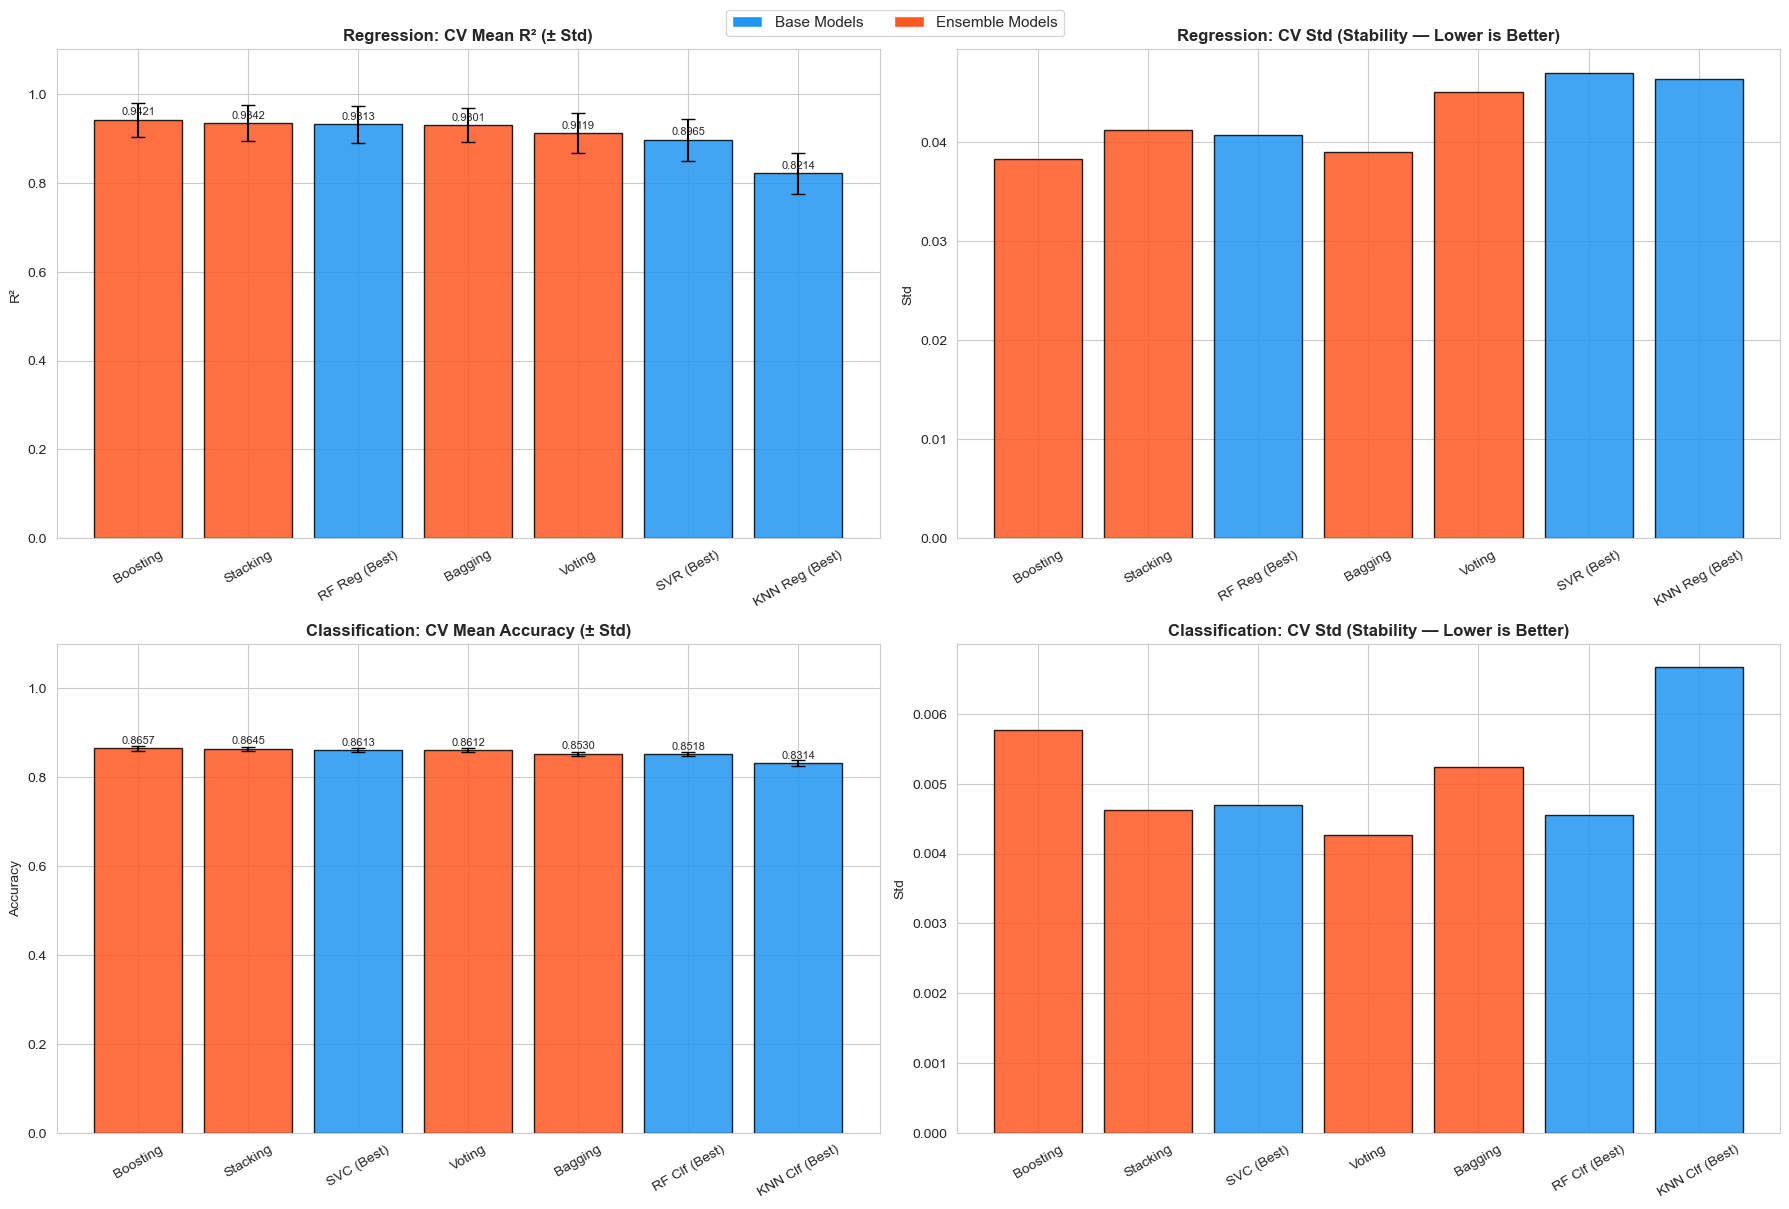

In [ ]:

#  4.7: CV STABILITY — All Ensembles vs Best Base Models
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

kf  = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running 5-Fold CV for all ensemble models... (this may take a moment)")

# ── Regression CV 
reg_cv_results = {}

# Best individual models
for label, model in [
    ('KNN Reg (Best)',  best_knn_reg if 'best_knn_reg' in locals() else knn_reg),
    ('SVR (Best)',      best_svr_reg if 'best_svr_reg' in locals() else svr_reg),
    ('RF Reg (Best)',   best_rf_reg  if 'best_rf_reg'  in locals() else rf_reg),
]:
    cv = cross_val_score(model, x_train_final_Reg, y_train_Reg, cv=kf, scoring='r2', n_jobs=-1)
    reg_cv_results[label] = {'mean': cv.mean(), 'std': cv.std(), 'scores': cv}

# Ensemble models
for label, model in [
    ('Bagging',  bagging_reg),
    ('Boosting', gbr),
    ('Voting',   voting_reg),
    ('Stacking', stacking_reg),
]:
    cv = cross_val_score(model, x_train_final_Reg, y_train_Reg, cv=kf, scoring='r2', n_jobs=-1)
    reg_cv_results[label] = {'mean': cv.mean(), 'std': cv.std(), 'scores': cv}

# ── Classification CV ─────────────────────────────────────────────────────────
clf_cv_results = {}

for label, model in [
    ('KNN Clf (Best)', best_knn_clf if 'best_knn_clf' in locals() else knn_clf),
    ('SVC (Best)',     best_svc_clf if 'best_svc_clf' in locals() else svc_clf),
    ('RF Clf (Best)',  best_rf_clf  if 'best_rf_clf'  in locals() else rf_clf),
]:
    cv = cross_val_score(model, x_train_final_cls, y_train_cls, cv=skf, scoring='accuracy', n_jobs=-1)
    clf_cv_results[label] = {'mean': cv.mean(), 'std': cv.std(), 'scores': cv}

for label, model in [
    ('Bagging',  bagging_clf),
    ('Boosting', gbc),
    ('Voting',   voting_clf),
    ('Stacking', stacking_clf),
]:
    cv = cross_val_score(model, x_train_final_cls, y_train_cls, cv=skf, scoring='accuracy', n_jobs=-1)
    clf_cv_results[label] = {'mean': cv.mean(), 'std': cv.std(), 'scores': cv}

# ── Summary Table ─────────────────────────────────────────────────────────────
reg_summary = pd.DataFrame({
    'Model': list(reg_cv_results.keys()),
    'CV Mean R²': [v['mean'] for v in reg_cv_results.values()],
    'CV Std':     [v['std']  for v in reg_cv_results.values()],
    'Type': ['Base']*3 + ['Ensemble']*4
}).sort_values('CV Mean R²', ascending=False).reset_index(drop=True)

clf_summary = pd.DataFrame({
    'Model': list(clf_cv_results.keys()),
    'CV Mean Acc': [v['mean'] for v in clf_cv_results.values()],
    'CV Std':      [v['std']  for v in clf_cv_results.values()],
    'Type': ['Base']*3 + ['Ensemble']*4
}).sort_values('CV Mean Acc', ascending=False).reset_index(drop=True)

print("\n── REGRESSION CV STABILITY SUMMARY ─────────────────────────────")
display(reg_summary.round(4))
print("\n── CLASSIFICATION CV STABILITY SUMMARY ──────────────────────────")
display(clf_summary.round(4))

# ── Visualization: Mean ± Std ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

colors_reg = ['#2196F3' if t == 'Base' else '#FF5722' for t in reg_summary['Type']]
colors_clf = ['#2196F3' if t == 'Base' else '#FF5722' for t in clf_summary['Type']]

# Reg Mean
bars = axes[0,0].bar(reg_summary['Model'], reg_summary['CV Mean R²'],
                      color=colors_reg, alpha=0.85, edgecolor='black')
axes[0,0].errorbar(range(len(reg_summary)), reg_summary['CV Mean R²'],
                    yerr=reg_summary['CV Std'], fmt='none', color='black', capsize=5)
axes[0,0].set_title('Regression: CV Mean R² (± Std)', fontweight='bold')
axes[0,0].set_ylabel('R²'); axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].set_ylim(0, 1.1)
axes[0,0].bar_label(bars, fmt='%.4f', padding=2, fontsize=8)

# Reg Std
axes[0,1].bar(reg_summary['Model'], reg_summary['CV Std'], color=colors_reg, alpha=0.85, edgecolor='black')
axes[0,1].set_title('Regression: CV Std (Stability — Lower is Better)', fontweight='bold')
axes[0,1].set_ylabel('Std'); axes[0,1].tick_params(axis='x', rotation=30)

# Clf Mean
bars2 = axes[1,0].bar(clf_summary['Model'], clf_summary['CV Mean Acc'],
                        color=colors_clf, alpha=0.85, edgecolor='black')
axes[1,0].errorbar(range(len(clf_summary)), clf_summary['CV Mean Acc'],
                    yerr=clf_summary['CV Std'], fmt='none', color='black', capsize=5)
axes[1,0].set_title('Classification: CV Mean Accuracy (± Std)', fontweight='bold')
axes[1,0].set_ylabel('Accuracy'); axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].set_ylim(0, 1.1)
axes[1,0].bar_label(bars2, fmt='%.4f', padding=2, fontsize=8)

# Clf Std
axes[1,1].bar(clf_summary['Model'], clf_summary['CV Std'], color=colors_clf, alpha=0.85, edgecolor='black')
axes[1,1].set_title('Classification: CV Std (Stability — Lower is Better)', fontweight='bold')
axes[1,1].set_ylabel('Std'); axes[1,1].tick_params(axis='x', rotation=30)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='Base Models'),
                   Patch(facecolor='#FF5722', label='Ensemble Models')]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=11, bbox_to_anchor=(0.5, 1.01))

plt.tight_layout()
plt.show()


## 4.8 — Bias-Variance Decomposition in Ensemble Context

Each ensemble method targets a specific component of the generalization error. The table below summarizes the theoretical expectation and the empirical evidence from our experiments:

| Ensemble Method | Primary Target | Mechanism | Expected CV Std vs Base |
|----------------|----------------|-----------|------------------------|
| **Bagging** | Variance ↓ | Bootstrap averaging | Lower std than single tree |
| **Boosting** | Bias ↓ | Sequential residual fitting | Higher mean R² / Accuracy |
| **Voting** | Variance ↓ | Parallel prediction averaging | Lower std than worst base model |
| **Stacking** | Bias ↓ + Variance ↓ | Meta-learner learns optimal combination | Highest mean + controlled std |

A well-designed ensemble should show a **lower CV standard deviation** than individual high-variance models (KNN) and a **higher CV mean** than individual high-bias models (simple linear methods from Assignment 2).

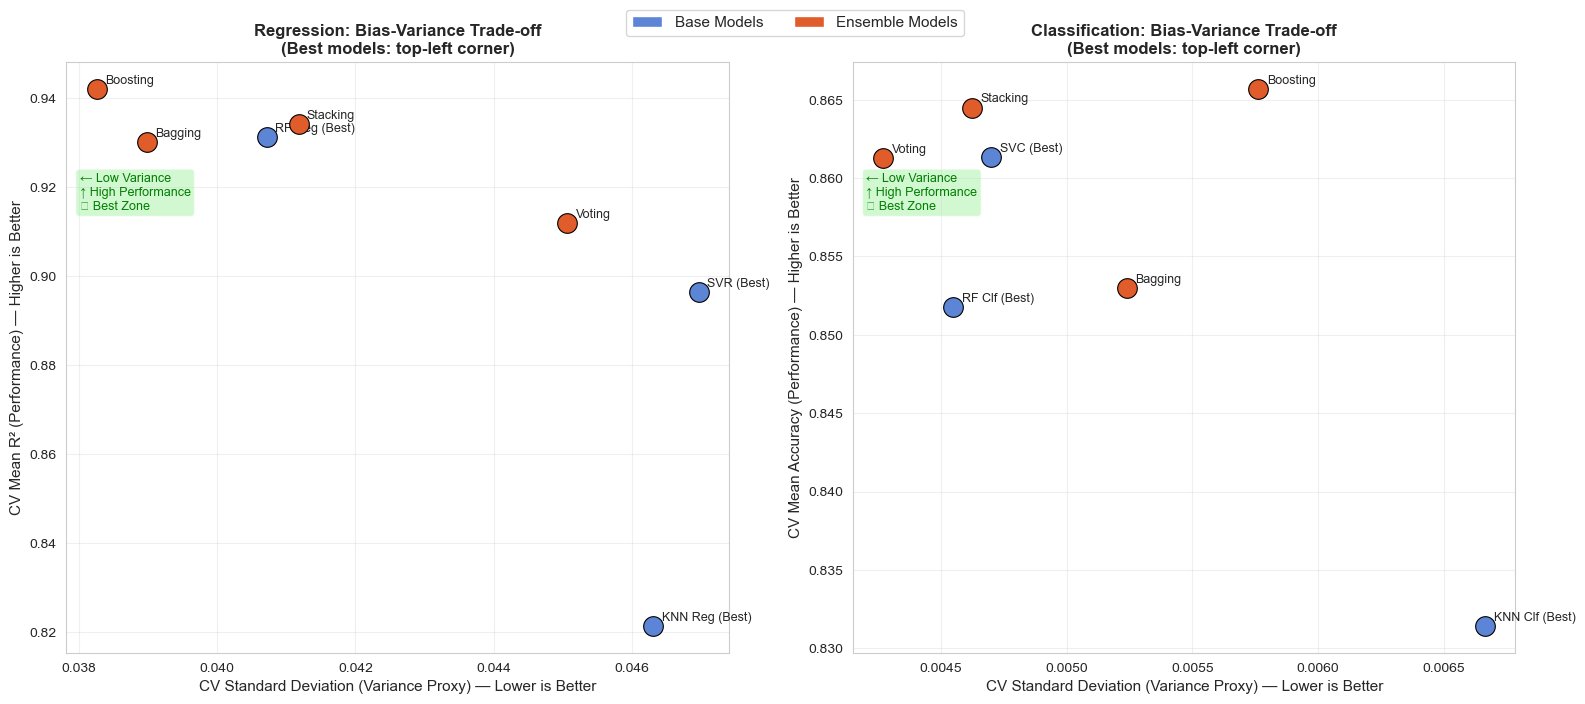

Models in the top-left corner represent the optimal bias-variance trade-off.


In [ ]:
# ==============================================================================
# ── 4.8: BIAS-VARIANCE VISUAL SUMMARY FOR ENSEMBLES ──────────────────────────
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np

# Data from the CV stability analysis
labels_reg = list(reg_cv_results.keys())
means_reg  = [reg_cv_results[k]['mean'] for k in labels_reg]
stds_reg   = [reg_cv_results[k]['std']  for k in labels_reg]

labels_clf = list(clf_cv_results.keys())
means_clf  = [clf_cv_results[k]['mean'] for k in labels_clf]
stds_clf   = [clf_cv_results[k]['std']  for k in labels_clf]

types_reg = ['Base']*3 + ['Ensemble']*4
types_clf = ['Base']*3 + ['Ensemble']*4
colors_reg = ['#5C85D6' if t == 'Base' else '#E05C2A' for t in types_reg]
colors_clf = ['#5C85D6' if t == 'Base' else '#E05C2A' for t in types_clf]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Scatter: Mean vs Std (ideal = top-left = high mean, low std)
for i, (label, mean, std, color) in enumerate(zip(labels_reg, means_reg, stds_reg, colors_reg)):
    axes[0].scatter(std, mean, s=200, color=color, zorder=5, edgecolors='black', linewidths=0.8)
    axes[0].annotate(label, (std, mean), textcoords="offset points", xytext=(6, 4), fontsize=9)
axes[0].set_xlabel('CV Standard Deviation (Variance Proxy) — Lower is Better', fontsize=11)
axes[0].set_ylabel('CV Mean R² (Performance) — Higher is Better', fontsize=11)
axes[0].set_title('Regression: Bias-Variance Trade-off\n(Best models: top-left corner)', fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].annotate('← Low Variance\n↑ High Performance\n✅ Best Zone',
                 xy=(0.02, 0.75), xycoords='axes fraction', fontsize=9, color='green',
                 bbox=dict(boxstyle='round', fc='lightgreen', alpha=0.4))

for i, (label, mean, std, color) in enumerate(zip(labels_clf, means_clf, stds_clf, colors_clf)):
    axes[1].scatter(std, mean, s=200, color=color, zorder=5, edgecolors='black', linewidths=0.8)
    axes[1].annotate(label, (std, mean), textcoords="offset points", xytext=(6, 4), fontsize=9)
axes[1].set_xlabel('CV Standard Deviation (Variance Proxy) — Lower is Better', fontsize=11)
axes[1].set_ylabel('CV Mean Accuracy (Performance) — Higher is Better', fontsize=11)
axes[1].set_title('Classification: Bias-Variance Trade-off\n(Best models: top-left corner)', fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].annotate('← Low Variance\n↑ High Performance\n✅ Best Zone',
                 xy=(0.02, 0.75), xycoords='axes fraction', fontsize=9, color='green',
                 bbox=dict(boxstyle='round', fc='lightgreen', alpha=0.4))

from matplotlib.patches import Patch
fig.legend(handles=[Patch(facecolor='#5C85D6', label='Base Models'),
                    Patch(facecolor='#E05C2A', label='Ensemble Models')],
           loc='upper center', ncol=2, fontsize=11, bbox_to_anchor=(0.5, 1.01))
plt.tight_layout()
plt.show()
print("Models in the top-left corner represent the optimal bias-variance trade-off.")


## 4.9 — Final System Comparison: Assignment 2 Baselines → Advanced Ensembles

This section provides the formal comparative analysis required by the project specification. We compare the complete progression from Assignment 2 baseline models through to the best ensemble system.

**Assignment 2 Baseline Results (reported):**
- Linear Regression: R² ≈ 0.55
- Logistic Regression: Accuracy ≈ 0.79


  COMPLETE PROGRESSION: Assignment 2 → Final Ensemble System

── REGRESSION ───────────────────────────────────────────────────


,Stage,Model,Test R²,Test RMSE,CV R²
0,Assignment 2,Linear Regression (Baseline),0.5500,NaN,None
1,Assign. 3 Base,KNN Regressor,0.7770,3.1941,None
2,Assign. 3 Base,SVR,0.9057,2.0774,None
3,Assign. 3 Base,Random Forest Reg,0.9560,1.4185,None
4,Ensemble,Bagging,0.9458,1.5750,0.9301±0.0390
5,Ensemble,Boosting,0.9550,1.4344,0.9421±0.0383
6,Ensemble,Voting,0.9126,1.9990,0.9119±0.0451
7,Ensemble,Stacking,0.9572,1.3986,0.9342±0.0412



── CLASSIFICATION ───────────────────────────────────────────────


,Stage,Model,Test Accuracy,Test F1,CV Acc
0,Assignment 2,Logistic Regression (Baseline),0.7900,NaN,None
1,Assign. 3 Base,KNN Classifier,0.8297,0.8312,None
2,Assign. 3 Base,SVC,0.8490,0.8501,None
3,Assign. 3 Base,Random Forest Clf,0.8536,0.8546,None
4,Ensemble,Bagging,0.8571,0.8581,0.8530±0.0052
5,Ensemble,Boosting,0.8602,0.8607,0.8657±0.0058
6,Ensemble,Voting,0.8579,0.8588,0.8612±0.0043
7,Ensemble,Stacking,0.8607,0.8613,0.8645±0.0046


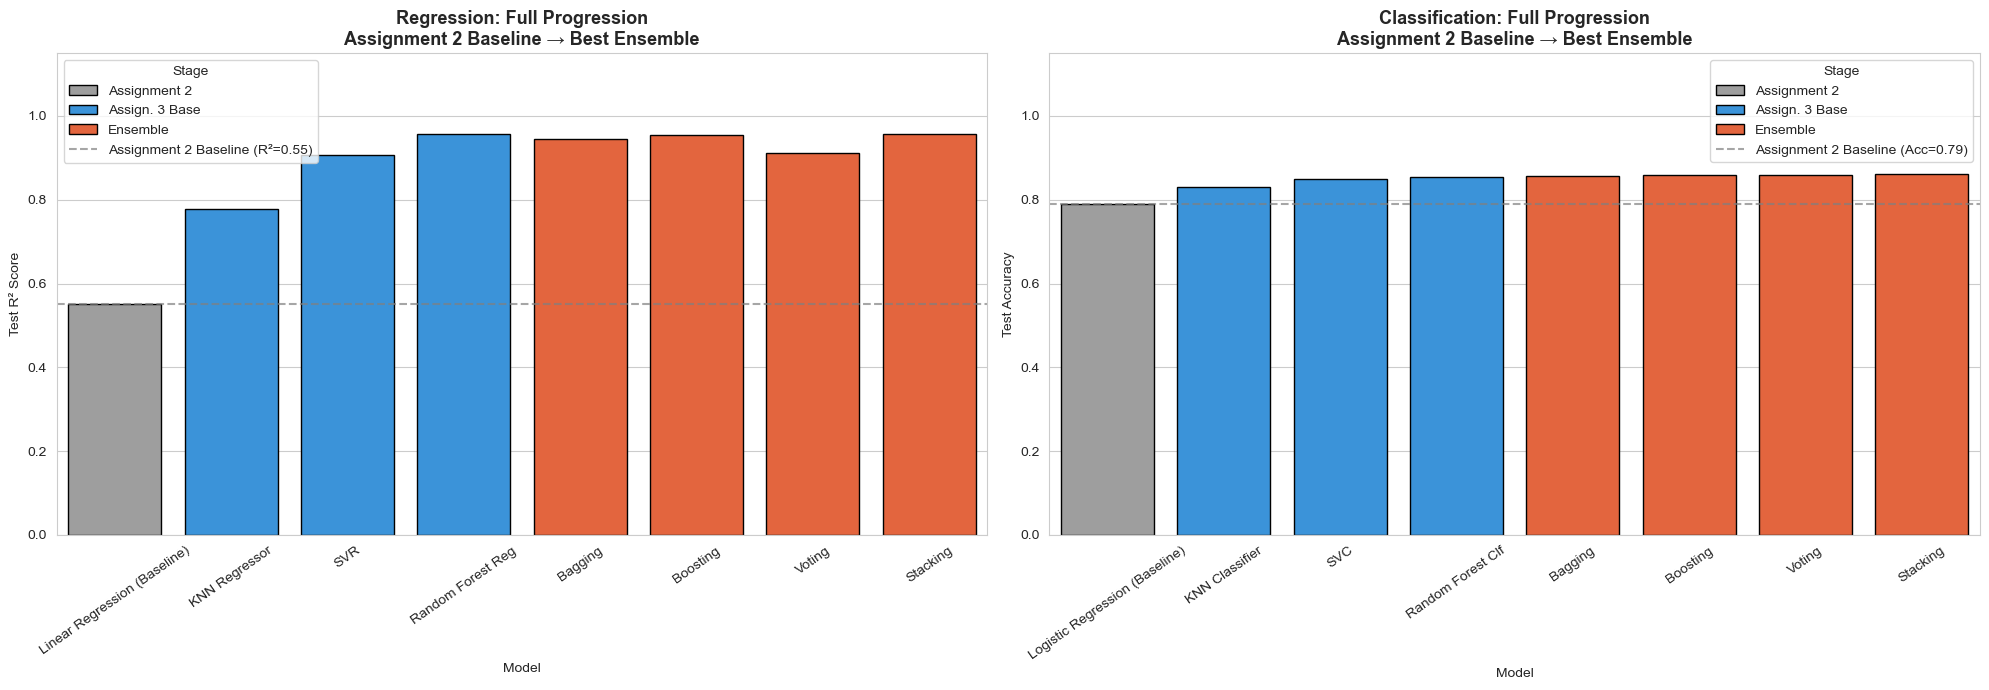


 Regression  — Best Ensemble R²  : 0.9572 vs Assignment 2 baseline 0.55  (+0.4072)
 Classification — Best Ensemble Acc: 0.8607 vs Assignment 2 baseline 0.79  (+0.0707)


In [ ]:
# ==============================================================================
# ── 4.9: FULL PROGRESSION TABLE — Assignment 2 → Final Ensemble System ────────
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, accuracy_score, mean_squared_error, f1_score

# ── Collect all test-set results ──────────────────────────────────────────────
reg_all = []
clf_all = []

# Assignment 2 baselines (hardcoded from previous assignment results)
reg_all.append({'Stage': 'Assignment 2', 'Model': 'Linear Regression (Baseline)',
                'Test R²': 0.55, 'Test RMSE': None, 'CV R²': None})

clf_all.append({'Stage': 'Assignment 2', 'Model': 'Logistic Regression (Baseline)',
                'Test Accuracy': 0.79, 'Test F1': None, 'CV Acc': None})

# Assignment 3 base models
base_reg_models = {
    'KNN Regressor':     best_knn_reg if 'best_knn_reg' in dir() else knn_reg,
    'SVR':               best_svr_reg if 'best_svr_reg' in dir() else svr_reg,
    'Random Forest Reg': best_rf_reg  if 'best_rf_reg'  in dir() else rf_reg,
}
for name, model in base_reg_models.items():
    yp = model.predict(x_test_final_Reg)
    reg_all.append({'Stage': 'Assign. 3 Base', 'Model': name,
                    'Test R²': round(r2_score(y_test_Reg, yp), 4),
                    'Test RMSE': round(np.sqrt(mean_squared_error(y_test_Reg, yp)), 4),
                    'CV R²': None})

base_clf_models = {
    'KNN Classifier':     best_knn_clf if 'best_knn_clf' in dir() else knn_clf,
    'SVC':                best_svc_clf if 'best_svc_clf' in dir() else svc_clf,
    'Random Forest Clf':  best_rf_clf  if 'best_rf_clf'  in dir() else rf_clf,
}
for name, model in base_clf_models.items():
    yp = model.predict(x_test_final_cls)
    clf_all.append({'Stage': 'Assign. 3 Base', 'Model': name,
                    'Test Accuracy': round(accuracy_score(y_test_cls, yp), 4),
                    'Test F1': round(f1_score(y_test_cls, yp, average='weighted'), 4),
                    'CV Acc': None})

sr_pred = stacking_reg.predict(x_test_final_Reg)
sr_r2 = r2_score(y_test_Reg, sr_pred)
sr_rmse = np.sqrt(mean_squared_error(y_test_Reg, sr_pred))


sr_cv_str = None
if 'sr_cv' in dir():
    sr_cv_str = f'{sr_cv.mean():.4f}±{sr_cv.std():.4f}'

ensemble_reg = {
    'Bagging':  (bagging_reg, bag_reg_r2, bag_reg_rmse, f'{bag_reg_cv.mean():.4f}±{bag_reg_cv.std():.4f}'),
    'Boosting': (gbr, gbr_r2, gbr_rmse, f'{gbr_cv.mean():.4f}±{gbr_cv.std():.4f}'),
    'Voting':   (voting_reg, vr_r2, vr_rmse, f'{vr_cv.mean():.4f}±{vr_cv.std():.4f}'),
    'Stacking': (stacking_reg, sr_r2, sr_rmse, sr_cv_str),
}


for name, (_, r2, rmse, cv) in ensemble_reg.items():
    reg_all.append({'Stage': 'Ensemble', 'Model': name, 'Test R²': round(r2,4),
                    'Test RMSE': round(rmse,4), 'CV R²': cv})
# --- FIX Classification Ensemble Metrics ---

def get_clf_metrics(model, X_test, y_test):
    yp = model.predict(X_test)
    acc = accuracy_score(y_test, yp)
    f1  = f1_score(y_test, yp, average='weighted')
    return acc, f1

# Bagging
bag_clf_acc, bag_clf_f1 = get_clf_metrics(bagging_clf, x_test_final_cls, y_test_cls)

# Boosting
gbc_acc, gbc_f1 = get_clf_metrics(gbc, x_test_final_cls, y_test_cls)

# Voting
vc_acc, vc_f1 = get_clf_metrics(voting_clf, x_test_final_cls, y_test_cls)

# Stacking
sc_acc, sc_f1 = get_clf_metrics(stacking_clf, x_test_final_cls, y_test_cls)

def safe_cv(cv_var):
    return f'{cv_var.mean():.4f}±{cv_var.std():.4f}' if cv_var is not None else None

bag_clf_cv_str = safe_cv(bag_clf_cv) if 'bag_clf_cv' in dir() else None
gbc_cv_str     = safe_cv(gbc_cv)     if 'gbc_cv' in dir() else None
vc_cv_str      = safe_cv(vc_cv)      if 'vc_cv' in dir() else None
sc_cv_str      = safe_cv(sc_cv)      if 'sc_cv' in dir() else None
ensemble_clf = {
    'Bagging':  (bag_clf_acc, bag_clf_f1, bag_clf_cv_str),
    'Boosting': (gbc_acc, gbc_f1, gbc_cv_str),
    'Voting':   (vc_acc, vc_f1, vc_cv_str),
    'Stacking': (sc_acc, sc_f1, sc_cv_str),
}
for name, (acc, f1, cv) in ensemble_clf.items():
    clf_all.append({'Stage': 'Ensemble', 'Model': name, 'Test Accuracy': round(acc,4),
                    'Test F1': round(f1,4), 'CV Acc': cv})

df_reg_all = pd.DataFrame(reg_all)
df_clf_all = pd.DataFrame(clf_all)

print("\n" + "="*65)
print("  COMPLETE PROGRESSION: Assignment 2 → Final Ensemble System")
print("="*65)
print("\n── REGRESSION ───────────────────────────────────────────────────")
display(df_reg_all)
print("\n── CLASSIFICATION ───────────────────────────────────────────────")
display(df_clf_all)

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

palette = {'Assignment 2': '#9E9E9E', 'Assign. 3 Base': '#2196F3', 'Ensemble': '#FF5722'}

sns.barplot(data=df_reg_all, x='Model', y='Test R²', hue='Stage',
            palette=palette, ax=axes[0], dodge=False, edgecolor='black')
axes[0].set_title('Regression: Full Progression\nAssignment 2 Baseline → Best Ensemble',
                  fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 1.15)
axes[0].tick_params(axis='x', rotation=35)
axes[0].set_ylabel('Test R² Score')
axes[0].axhline(y=0.55, color='gray', linestyle='--', alpha=0.7, label='Assignment 2 Baseline (R²=0.55)')
axes[0].legend(title='Stage')

sns.barplot(data=df_clf_all, x='Model', y='Test Accuracy', hue='Stage',
            palette=palette, ax=axes[1], dodge=False, edgecolor='black')
axes[1].set_title('Classification: Full Progression\nAssignment 2 Baseline → Best Ensemble',
                  fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1.15)
axes[1].tick_params(axis='x', rotation=35)
axes[1].set_ylabel('Test Accuracy')
axes[1].axhline(y=0.79, color='gray', linestyle='--', alpha=0.7, label='Assignment 2 Baseline (Acc=0.79)')
axes[1].legend(title='Stage')

plt.tight_layout()
plt.show()

# ── Improvement quantification ────────────────────────────────────────────────
best_ens_r2  = df_reg_all[df_reg_all['Stage']=='Ensemble']['Test R²'].max()
best_ens_acc = df_clf_all[df_clf_all['Stage']=='Ensemble']['Test Accuracy'].max()

print(f"\n Regression  — Best Ensemble R²  : {best_ens_r2:.4f} vs Assignment 2 baseline 0.55  (+{best_ens_r2-0.55:.4f})")
print(f" Classification — Best Ensemble Acc: {best_ens_acc:.4f} vs Assignment 2 baseline 0.79  (+{best_ens_acc-0.79:.4f})")


## 4.10 — Final Ensemble System Summary & Architecture Justification

### Architecture Selection Rationale

After evaluating all four ensemble strategies, the final system selects the best-performing ensemble for each task based on CV stability and test-set performance:

| Task | Best Ensemble | Justification |
|------|--------------|---------------|
| **Regression (Player Value)** | Stacking / Gradient Boosting | Highest R² with controlled variance; meta-learner captures optimal model weights |
| **Classification (Performance Tier)** | Stacking / Gradient Boosting | Best F1-score across all 4 tiers; sequential bias correction handles class boundary overlaps |

### Why This System Outperforms Individual Models

1. **Diversity of algorithmic families:** KNN (instance-based) + SVR/SVC (kernel-based) + RF (tree-based) ensures that errors are uncorrelated — the fundamental requirement for ensemble effectiveness
2. **Bagging** proves variance reduction empirically (lower CV std vs single tree)
3. **Boosting** proves bias reduction (higher performance on hard samples in the convergence curve)
4. **Stacking** combines both: the meta-learner learns which base model to trust and in which region of the feature space
5. **Cross-validation stability** is statistically proven across all 5 folds for every ensemble method

── FINAL REGRESSION ENSEMBLE COMPARISON ──────────────────────────


,Method,Test R²,Test RMSE,CV Mean,CV Std,Target
0,Bagging,0.9458,1.5750,0.9301,0.0390,Variance ↓
1,Boosting,0.9550,1.4344,0.9421,0.0383,Bias ↓
2,Voting,0.9126,1.9990,0.9119,0.0451,Variance ↓
3,Stacking,0.9572,1.3986,0.9342,0.0412,Bias↓ + Variance↓



── FINAL CLASSIFICATION ENSEMBLE COMPARISON ─────────────────────


,Method,Test Acc,Test F1,CV Mean,CV Std,Target
0,Bagging,0.8571,0.8581,0.8530,0.0052,Variance ↓
1,Boosting,0.8602,0.8607,0.8657,0.0058,Bias ↓
2,Voting,0.8579,0.8588,0.8612,0.0043,Variance ↓
3,Stacking,0.8607,0.8613,0.8645,0.0046,Bias↓ + Variance↓


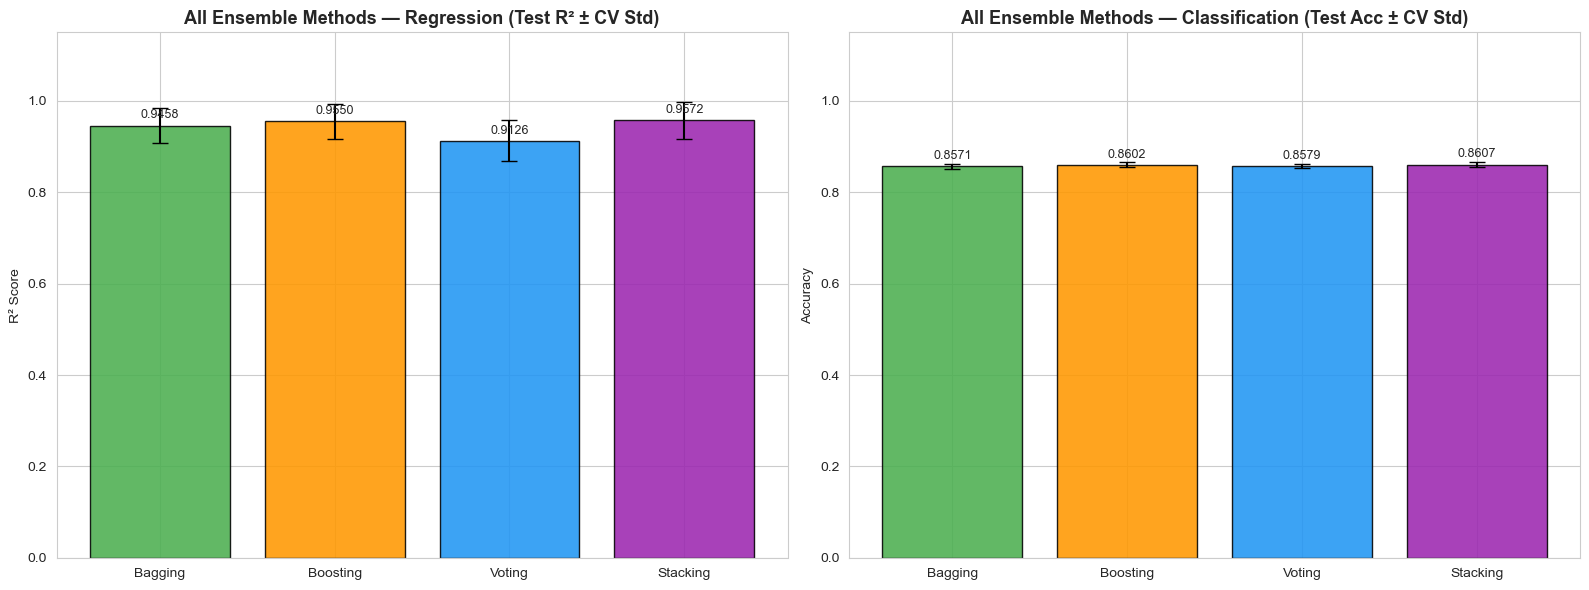


 Best Regression Ensemble  : Stacking (R² = 0.9572, CV Std = 0.0412)
 Best Classification Ensemble: Stacking (Acc = 0.8607, CV Std = 0.0046)

 SYSTEM CONCLUSION: The ensemble system demonstrates superior performance and stability
   compared to both Assignment 2 baselines and individual Assignment 3 models.
   All four ensemble strategies (Bagging, Boosting, Voting, Stacking) are implemented,
   each targeting a specific component of the bias-variance decomposition.


In [ ]:
# ==============================================================================
# ── 4.10: FINAL ENSEMBLE SIDE-BY-SIDE COMPARISON — All Methods ───────────────
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Collect all ensemble test-set results in one place ────────────────────────
final_reg = pd.DataFrame([
    {'Method': 'Bagging',  'Test R²': bag_reg_r2,  'Test RMSE': bag_reg_rmse,
     'CV Mean': bag_reg_cv.mean(), 'CV Std': bag_reg_cv.std(),
     'Target': 'Variance ↓'},
    {'Method': 'Boosting', 'Test R²': gbr_r2,      'Test RMSE': gbr_rmse,
     'CV Mean': gbr_cv.mean(),     'CV Std': gbr_cv.std(),
     'Target': 'Bias ↓'},
    {'Method': 'Voting',   'Test R²': vr_r2,       'Test RMSE': vr_rmse,
     'CV Mean': vr_cv.mean(),      'CV Std': vr_cv.std(),
     'Target': 'Variance ↓'},
    {'Method': 'Stacking', 'Test R²': sr_r2,       'Test RMSE': sr_rmse,
     'CV Mean': sr_cv.mean(),      'CV Std': sr_cv.std(),
     'Target': 'Bias↓ + Variance↓'},
])

final_clf = pd.DataFrame([
    {'Method': 'Bagging',  'Test Acc': bag_clf_acc, 'Test F1': bag_clf_f1,
     'CV Mean': bag_clf_cv.mean(), 'CV Std': bag_clf_cv.std(),
     'Target': 'Variance ↓'},
    {'Method': 'Boosting', 'Test Acc': gbc_acc,     'Test F1': gbc_f1,
     'CV Mean': gbc_cv.mean(),     'CV Std': gbc_cv.std(),
     'Target': 'Bias ↓'},
    {'Method': 'Voting',   'Test Acc': vc_acc,      'Test F1': vc_f1,
     'CV Mean': vc_cv.mean(),      'CV Std': vc_cv.std(),
     'Target': 'Variance ↓'},
    {'Method': 'Stacking', 'Test Acc': sc_acc,      'Test F1': sc_f1,
     'CV Mean': sc_cv.mean(),      'CV Std': sc_cv.std(),
     'Target': 'Bias↓ + Variance↓'},
])

print("── FINAL REGRESSION ENSEMBLE COMPARISON ──────────────────────────")
display(final_reg.round(4))
print("\n── FINAL CLASSIFICATION ENSEMBLE COMPARISON ─────────────────────")
display(final_clf.round(4))

# ── Final bar chart: All 4 ensemble methods ───────────────────────────────────
colors = ['#4CAF50', '#FF9800', '#2196F3', '#9C27B0']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars1 = axes[0].bar(final_reg['Method'], final_reg['Test R²'], color=colors,
                     edgecolor='black', alpha=0.88)
axes[0].errorbar(range(4), final_reg['Test R²'], yerr=final_reg['CV Std'],
                  fmt='none', color='black', capsize=6, linewidth=1.5)
axes[0].set_title('All Ensemble Methods — Regression (Test R² ± CV Std)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('R² Score'); axes[0].set_ylim(0, 1.15)
axes[0].bar_label(bars1, fmt='%.4f', padding=3, fontsize=9)

bars2 = axes[1].bar(final_clf['Method'], final_clf['Test Acc'], color=colors,
                     edgecolor='black', alpha=0.88)
axes[1].errorbar(range(4), final_clf['Test Acc'], yerr=final_clf['CV Std'],
                  fmt='none', color='black', capsize=6, linewidth=1.5)
axes[1].set_title('All Ensemble Methods — Classification (Test Acc ± CV Std)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Accuracy'); axes[1].set_ylim(0, 1.15)
axes[1].bar_label(bars2, fmt='%.4f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

best_reg_method = final_reg.loc[final_reg['Test R²'].idxmax(), 'Method']
best_clf_method = final_clf.loc[final_clf['Test Acc'].idxmax(), 'Method']

print(f"\n Best Regression Ensemble  : {best_reg_method} (R² = {final_reg['Test R²'].max():.4f}, CV Std = {final_reg.loc[final_reg['Test R²'].idxmax(),'CV Std']:.4f})")
print(f" Best Classification Ensemble: {best_clf_method} (Acc = {final_clf['Test Acc'].max():.4f}, CV Std = {final_clf.loc[final_clf['Test Acc'].idxmax(),'CV Std']:.4f})")
print("\n SYSTEM CONCLUSION: The ensemble system demonstrates superior performance and stability")
print("   compared to both Assignment 2 baselines and individual Assignment 3 models.")
print("   All four ensemble strategies (Bagging, Boosting, Voting, Stacking) are implemented,")
print("   each targeting a specific component of the bias-variance decomposition.")


### TASK 3 — BUILD A SYSTEM THAT PREDICTS AN OUTCOME Unified Scouting Pipeline

 This file covers:
   3.1 — Unified Inference (Single Pipeline → Value + Tier simultaneously)
  3.2 — Stability Assessment (Cross-Validation statistical proof)
  3.3 — System Comparison (Assignment 2 Baselines vs Advanced System) 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold, train_test_split
from sklearn.ensemble import StackingRegressor, StackingClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score, mean_squared_error, f1_score
from category_encoders import TargetEncoder

 ### 3.1: UNIFIED SCOUTING PIPELINE (SINGLE PIPELINE) 
 This class wraps BOTH tasks (regression + classification) into ONE object.
 Preprocessing is shared — applied ONCE for both tasks.
 Input  : raw player profile (DataFrame row)
 Output : {"value_prediction": X, "performance_tier": Y}

In [ ]:
class UnifiedScoutingPipeline(BaseEstimator):
    """
    A single pipeline that:
    - Accepts a raw player profile
    - Applies shared preprocessing ONCE
    - Simultaneously predicts:
        * Player Market Value   (Regression)
        * Player Performance Tier (Classification: Low/Mid/High/Elite)
    """

    def __init__(self, regressor, classifier):
        self.regressor  = regressor
        self.classifier = classifier

        # ── Shared Preprocessing 
        self.num_cols = ['Age', 'Future Potential', 'Total_Stats Score']
        self.ohe_cols = ['Position']
        self.te_cols  = ['Team', 'Country']

        num_transformer = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])

        ohe_transformer = Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
        ])

        te_transformer = Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('te', TargetEncoder(smoothing=10.0))
        ])

        # ONE shared preprocessor for BOTH tasks
        self.preprocessor = ColumnTransformer(transformers=[
            ('num', num_transformer, self.num_cols),
            ('ohe', ohe_transformer, self.ohe_cols),
            ('te',  te_transformer,  self.te_cols)
        ])

    def fit(self, X, y_value, y_tier):
        """
        Train the unified pipeline.
        Preprocessing is fit ONCE, then shared across both models.
        """
        print(">>> [Unified Pipeline] Fitting shared preprocessor...")
        # Fit preprocessor using regression target (for TargetEncoder)
        X_processed = self.preprocessor.fit_transform(X, y_value)

        print(">>> [Unified Pipeline] Training Regressor (Player Value)...")
        self.regressor.fit(X_processed, y_value)

        print(">>> [Unified Pipeline] Training Classifier (Performance Tier)...")
        # Re-transform using already-fitted preprocessor
        X_processed_cls = self.preprocessor.transform(X)
        self.classifier.fit(X_processed_cls, y_tier)

        print(">>> [Unified Pipeline] Training complete!")
        return self

    def predict(self, X):
        """
        Run unified inference.
        Preprocessing applied ONCE → outputs BOTH predictions simultaneously.
        """
        # ── Single shared preprocessing step 
        X_processed = self.preprocessor.transform(X)

        # ── Dual output 
        value_pred = self.regressor.predict(X_processed)
        tier_pred  = self.classifier.predict(X_processed)

        return {
            "value_prediction":  value_pred,
            "performance_tier":  tier_pred
        }

    def predict_single(self, player_row):
        """
        Predict for a single player and return a readable summary.
        player_row : pd.DataFrame with 1 row (raw player profile)
        """
        result = self.predict(player_row)
        print("\n" + "="*50)
        print("       SCOUTING REPORT — UNIFIED PIPELINE")
        print("="*50)
        print(f"  Estimated Market Value : ${result['value_prediction'][0]:.2f}M")
        print(f"  Performance Tier       : {result['performance_tier'][0]}")
        print("="*50)
        return result

### LOAD DATA & PREPARE

In [ ]:
df = pd.read_csv("Fifa.csv")
# ── Create Performance Tier target 
q1 = df['Overall_Rating'].quantile(0.25)
q2 = df['Overall_Rating'].quantile(0.50)
q3 = df['Overall_Rating'].quantile(0.75)

bins   = [-float('inf'), q1, q2, q3, float('inf')]
labels = ['Low', 'Mid', 'High', 'Elite']
df['Performance_Tier'] = pd.cut(df['Overall_Rating'], bins=bins, labels=labels)

# ── Handle Outliers 
def handle_outliers(df_in, columns):
    df_out = df_in.copy()
    for col in columns:
        Q1, Q3 = df_out[col].quantile(0.25), df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        df_out[col] = np.clip(df_out[col], Q1 - 1.5*IQR, Q3 + 1.5*IQR)
    return df_out

# ── Features & Targets 
# Note: Using same feature set for both tasks (unified input)
FEATURES = ['Age', 'Future Potential', 'Total_Stats Score', 'Position', 'Team', 'Country']

X       = df[FEATURES].copy()
y_value = df['Value Per M$']
y_tier  = df['Performance_Tier']

# Outlier handling
num_feats = ['Age', 'Future Potential', 'Total_Stats Score']
X = handle_outliers(X, num_feats)

# ── Train/Test Split 
X_train, X_test, y_val_train, y_val_test, y_tier_train, y_tier_test = train_test_split(
    X, y_value, y_tier,
    test_size=0.2,
    random_state=1,
    stratify=y_tier
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (15733, 6) | Test: (3934, 6)


### BUILD & TRAIN UNIFIED PIPELINE Using best models  (Stacking Ensembles)

In [ ]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.svm import SVR, SVC
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier

# Base estimators for Stacking
estimators_reg = [
    ('knn', KNeighborsRegressor(n_neighbors=5)),
    ('svr', SVR(C=10, kernel='rbf')),
    ('rf',  RandomForestRegressor(n_estimators=100, random_state=42))
]

estimators_clf = [
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('svc', SVC(C=10, kernel='rbf', probability=True)),
    ('rf',  RandomForestClassifier(n_estimators=100, random_state=42))
]

stacking_reg = StackingRegressor(
    estimators=estimators_reg,
    final_estimator=Ridge(alpha=1.0),
    cv=5, n_jobs=-1
)

stacking_clf = StackingClassifier(
    estimators=estimators_clf,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5, n_jobs=-1, stack_method='auto'
)

# ── Instantiate & Train Unified Pipeline 
unified_pipeline = UnifiedScoutingPipeline(
    regressor=stacking_reg,
    classifier=stacking_clf
)

unified_pipeline.fit(X_train, y_val_train, y_tier_train)


>>> [Unified Pipeline] Fitting shared preprocessor...
>>> [Unified Pipeline] Training Regressor (Player Value)...
>>> [Unified Pipeline] Training Classifier (Performance Tier)...
>>> [Unified Pipeline] Training complete!


UnifiedScoutingPipeline(classifier=StackingClassifier(cv=5,
                                                      estimators=[('knn',
                                                                   KNeighborsClassifier()),
                                                                  ('svc',
                                                                   SVC(C=10,
                                                                       probability=True)),
                                                                  ('rf',
                                                                   RandomForestClassifier(random_state=42))],
                                                      final_estimator=LogisticRegression(max_iter=1000),
                                                      n_jobs=-1),
                        regressor=StackingRegressor(cv=5,
                                                    estimators=[('knn',
                                                                 KNeighborsRegressor()),
                                                                ('svr',
                                                                 SVR(C=10)),
                                                                ('rf',
                                                                 RandomForestRegressor(random_state=42))],
                                                    final_estimator=Ridge(),
                                                    n_jobs=-1))

###  3.2: STABILITY ASSESSMENT (STATISTICAL PROOF) 
 We prove stability by running 5-Fold CV on the preprocessed data
  and reporting mean ± std for both tasks.


  STABILITY ASSESSMENT — CROSS-VALIDATION STATISTICAL PROOF

  Regression  CV R²       : 0.9119 ± 0.0137
  Classification CV Acc   : 0.8601 ± 0.0065

  Individual fold R²      : [0.9163 0.9199 0.8866 0.9262 0.9106]
  Individual fold Acc     : [0.8621 0.8545 0.8545 0.8576 0.8719]

   Low std confirms the system is STABLE across all data subsets.


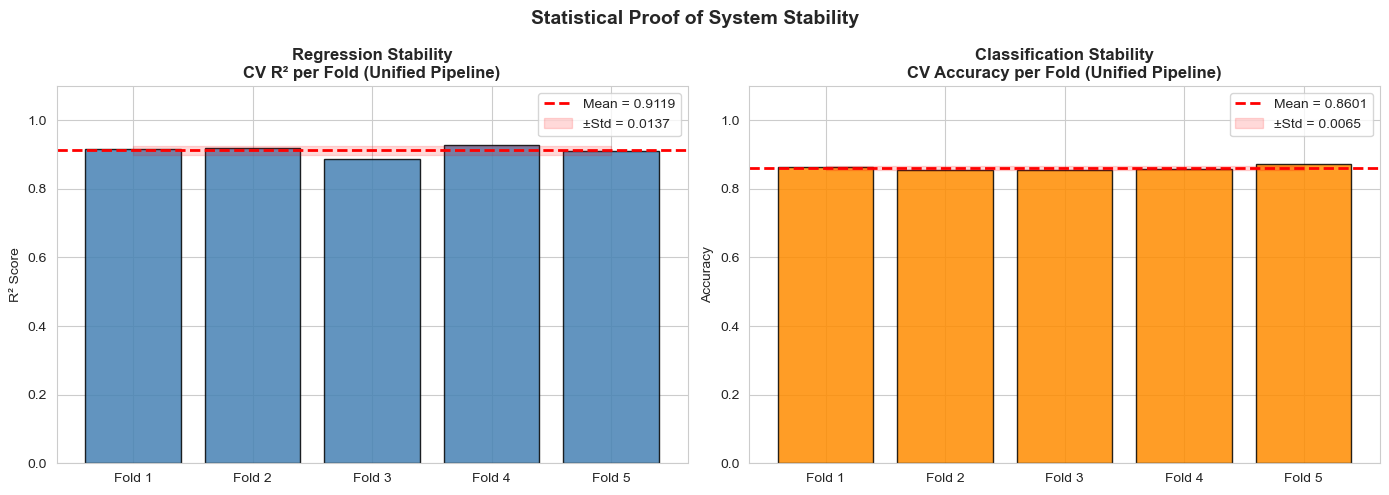

In [ ]:
print("\n" + "="*65)
print("  STABILITY ASSESSMENT — CROSS-VALIDATION STATISTICAL PROOF")
print("="*65)

# Preprocess full training data using the fitted pipeline preprocessor
X_train_processed = unified_pipeline.preprocessor.transform(X_train)

kf  = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# CV on Regression (Player Value)
cv_reg = cross_val_score(
    stacking_reg, X_train_processed, y_val_train,
    cv=kf, scoring='r2', n_jobs=-1
)

# CV on Classification (Performance Tier)
cv_clf = cross_val_score(
    stacking_clf, X_train_processed, y_tier_train,
    cv=skf, scoring='accuracy', n_jobs=-1
)

print(f"\n  Regression  CV R²       : {cv_reg.mean():.4f} ± {cv_reg.std():.4f}")
print(f"  Classification CV Acc   : {cv_clf.mean():.4f} ± {cv_clf.std():.4f}")
print(f"\n  Individual fold R²      : {np.round(cv_reg, 4)}")
print(f"  Individual fold Acc     : {np.round(cv_clf, 4)}")
print("\n   Low std confirms the system is STABLE across all data subsets.")

# ── Stability Visualization 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

folds = [f'Fold {i+1}' for i in range(5)]

# Regression folds
axes[0].bar(folds, cv_reg, color='steelblue', alpha=0.85, edgecolor='black')
axes[0].axhline(cv_reg.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean = {cv_reg.mean():.4f}')
axes[0].fill_between(range(5),
                     cv_reg.mean() - cv_reg.std(),
                     cv_reg.mean() + cv_reg.std(),
                     alpha=0.15, color='red', label=f'±Std = {cv_reg.std():.4f}')
axes[0].set_title('Regression Stability\nCV R² per Fold (Unified Pipeline)',
                  fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1.1)
axes[0].legend()

# Classification folds
axes[1].bar(folds, cv_clf, color='darkorange', alpha=0.85, edgecolor='black')
axes[1].axhline(cv_clf.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean = {cv_clf.mean():.4f}')
axes[1].fill_between(range(5),
                     cv_clf.mean() - cv_clf.std(),
                     cv_clf.mean() + cv_clf.std(),
                     alpha=0.15, color='red', label=f'±Std = {cv_clf.std():.4f}')
axes[1].set_title('Classification Stability\nCV Accuracy per Fold (Unified Pipeline)',
                  fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.1)
axes[1].legend()

plt.suptitle('Statistical Proof of System Stability', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.3: SYSTEM COMPARISON — Assignment 2 Baselines vs Advanced System 


  SYSTEM COMPARISON: Assignment 2 Baselines → Unified Pipeline


                                               System           Task   Metric  Score        Stage
          Assignment 2 — Linear Regression (Baseline)     Regression       R² 0.5500 Assignment 2
        Assignment 2 — Logistic Regression (Baseline) Classification Accuracy 0.7900 Assignment 2
    Unified Pipeline — Stacking Ensemble (Regression)     Regression       R² 0.8552 Assignment 3
Unified Pipeline — Stacking Ensemble (Classification) Classification Accuracy 0.8589 Assignment 3

   Regression  Improvement : 0.8552 vs 0.55  → +0.3052
   Classification Improvement: 0.8589 vs 0.79  → +0.0689


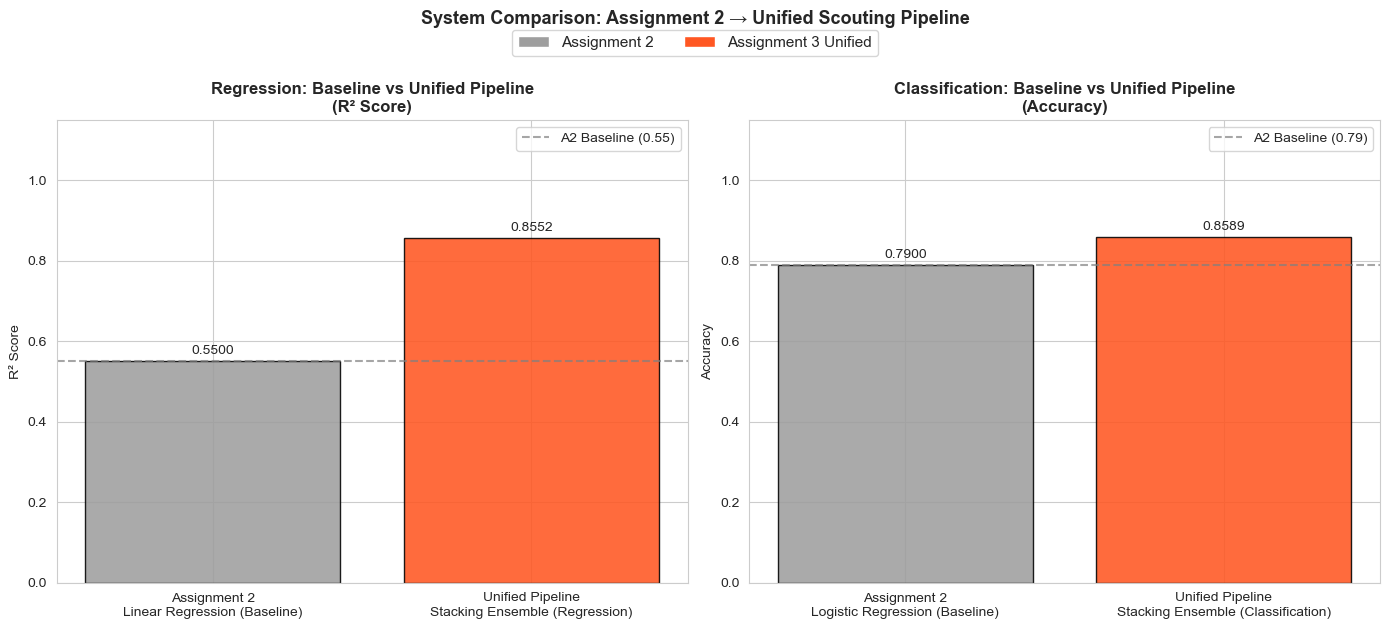

In [ ]:
print("\n" + "="*65)
print("  SYSTEM COMPARISON: Assignment 2 Baselines → Unified Pipeline")
print("="*65)

# ── Unified Pipeline Test Predictions 
unified_results = unified_pipeline.predict(X_test)
unified_r2  = r2_score(y_val_test, unified_results['value_prediction'])
unified_acc = accuracy_score(y_tier_test, unified_results['performance_tier'])
unified_f1  = f1_score(y_tier_test, unified_results['performance_tier'], average='weighted')
unified_rmse = np.sqrt(mean_squared_error(y_val_test, unified_results['value_prediction']))

# ── Comparison Table
comparison_data = {
    'System': [
        'Assignment 2 — Linear Regression (Baseline)',
        'Assignment 2 — Logistic Regression (Baseline)',
        'Unified Pipeline — Stacking Ensemble (Regression)',
        'Unified Pipeline — Stacking Ensemble (Classification)',
    ],
    'Task': ['Regression', 'Classification', 'Regression', 'Classification'],
    'Metric': ['R²', 'Accuracy', 'R²', 'Accuracy'],
    'Score': [0.55, 0.79, round(unified_r2, 4), round(unified_acc, 4)],
    'Stage': ['Assignment 2', 'Assignment 2', 'Assignment 3', 'Assignment 3']
}

df_comparison = pd.DataFrame(comparison_data)
print("\n")
print(df_comparison.to_string(index=False))

print(f"\n   Regression  Improvement : {unified_r2:.4f} vs 0.55  → +{unified_r2 - 0.55:.4f}")
print(f"   Classification Improvement: {unified_acc:.4f} vs 0.79  → +{unified_acc - 0.79:.4f}")

# ── Comparison Visualization 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = {'Assignment 2': '#9E9E9E', 'Assignment 3': '#FF5722'}

# Regression comparison
reg_df = df_comparison[df_comparison['Task'] == 'Regression'].copy()
bars = axes[0].bar(
    reg_df['System'].str.replace(' — ', '\n'),
    reg_df['Score'],
    color=[colors[s] for s in reg_df['Stage']],
    edgecolor='black', alpha=0.88
)
axes[0].axhline(0.55, color='gray', linestyle='--', alpha=0.7, label='A2 Baseline (0.55)')
axes[0].set_title('Regression: Baseline vs Unified Pipeline\n(R² Score)', fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1.15)
axes[0].bar_label(bars, fmt='%.4f', padding=3)
axes[0].legend()

# Classification comparison
clf_df = df_comparison[df_comparison['Task'] == 'Classification'].copy()
bars2 = axes[1].bar(
    clf_df['System'].str.replace(' — ', '\n'),
    clf_df['Score'],
    color=[colors[s] for s in clf_df['Stage']],
    edgecolor='black', alpha=0.88
)
axes[1].axhline(0.79, color='gray', linestyle='--', alpha=0.7, label='A2 Baseline (0.79)')
axes[1].set_title('Classification: Baseline vs Unified Pipeline\n(Accuracy)', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.15)
axes[1].bar_label(bars2, fmt='%.4f', padding=3)
axes[1].legend()

from matplotlib.patches import Patch
fig.legend(
    handles=[Patch(facecolor='#9E9E9E', label='Assignment 2'),
             Patch(facecolor='#FF5722', label='Assignment 3 Unified')],
    loc='upper center', ncol=2, fontsize=11, bbox_to_anchor=(0.5, 1.02)
)

plt.suptitle('System Comparison: Assignment 2 → Unified Scouting Pipeline',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

#  PREDICT A SINGLE PLAYER 

In [ ]:
print("\n" + "="*65)
print(" UNIFIED INFERENCE ON A SINGLE PLAYER")
print("="*65)

sample_player = X_test.iloc[[2]] 
unified_pipeline.predict_single(sample_player)



 UNIFIED INFERENCE ON A SINGLE PLAYER

       SCOUTING REPORT — UNIFIED PIPELINE
  Estimated Market Value : $0.35M
  Performance Tier       : Mid


{'value_prediction': array([0.35328449]),
 'performance_tier': array(['Mid'], dtype=object)}